In [1]:
## In this example, we will study output data frame from pandora.py configuration
#### 1. Opening each data frame and check structure
#### 2. Collect POT and scale factor to the target POT
#### 3. Merge evtdf and mcnudf for further study
#### 4. Draw some plots for each slice and for each pfp

import os
import sys
import lmfit
import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec


# Absolute path to cafpyana directory
print('Importing cafpyana utils...')
cafpyana_root = "/home/lpelegri/cafpyana"
# Add CAFpyana to the Python search path -- this will allow you to import cafpyana modules
sys.path.insert(0, cafpyana_root)

from analysis_village.unfolding.wienersvd import *
from analysis_village.unfolding.unfolding_inputs import *

from analysis_village.cc1pi.HelperFunctions import HelperFunctions
from analysis_village.cc1pi.Constants import CTE as CTE
from analysis_village.cc1pi.CutMasks.MaskUtils import *
from analysis_village.cc1pi.CutMasks.CutMasks import *
from analysis_village.cc1pi.DataFrameUtils import DFCleaning
from analysis_village.cc1pi.GraphUtils.GraphsUtils import *
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *
from analysis_village.cc1pi.Optimize import OptimizationUtils
from analysis_village.cc1pi.Optimize import ConfusionMatricesUtils
from analysis_village.cc1pi.BDTs import BDTTrainingUtils

# import this repo's classes
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

np.seterr(divide='ignore', invalid='ignore', over='ignore')

Importing cafpyana utils...
Importing cafpyana utils...


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Load DataFrames

keys in /exp/sbnd/data/users/lpelegri/cafpyana_data/wrong_energy_cut/mc_ar23p_pruned_min_reco_no_syst.df
Keys: ['/cc1pi_0', '/cc1pi_1', '/cc1pi_10', '/cc1pi_11', '/cc1pi_12', '/cc1pi_2', '/cc1pi_3', '/cc1pi_4', '/cc1pi_5', '/cc1pi_6', '/cc1pi_7', '/cc1pi_8', '/cc1pi_9', '/hdr_0', '/hdr_1', '/hdr_10', '/hdr_11', '/hdr_12', '/hdr_2', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_10', '/histpotdf_11', '/histpotdf_12', '/histpotdf_2', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/histpotdf_7', '/histpotdf_8', '/histpotdf_9', '/nudf_0', '/nudf_1', '/nudf_10', '/nudf_11', '/nudf_12', '/nudf_2', '/nudf_3', '/nudf_4', '/nudf_5', '/nudf_6', '/nudf_7', '/nudf_8', '/nudf_9', '/split']
n_split: 13
dataframes
loaded!
5.0507054e+20
duplication for /exp/sbnd/data/users/lpelegri/cafpyana_data/wrong_energy_cut/mc_ar23p_pruned_min_reco_no_syst.df


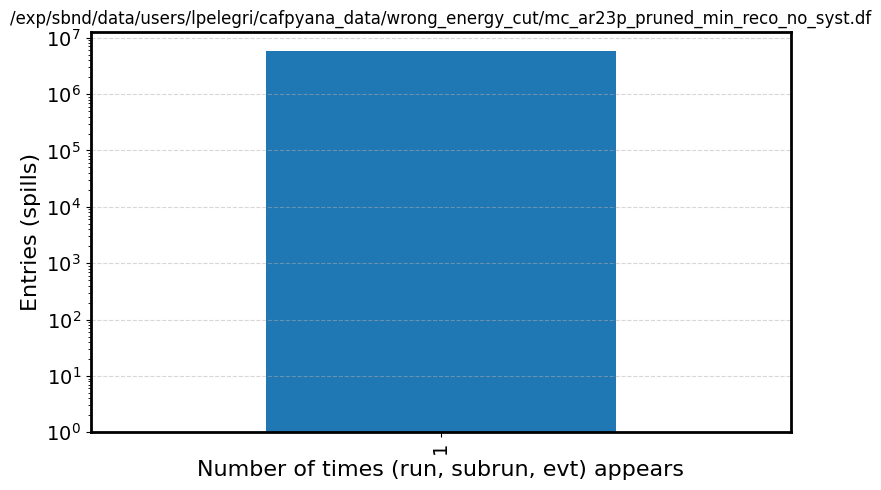

MultiIndex([(     'obvious_cosmic', '', '', ''),
            (                 't0', '', '', ''),
            (          'inside_FV', '', '', ''),
            (           'nu_score', '', '', ''),
            (              'track', '', '', ''),
            (             'shower', '', '', ''),
            (     'MIP_candidates', '', '', ''),
            (              'angle', '', '', ''),
            (         'proton_BDT', '', '', ''),
            ('proton_BDT_sideband', '', '', ''),
            (        'containment', '', '', ''),
            (     'proton_BDT_2pi', '', '', ''),
            (    'TPC_containment', '', '', ''),
            (             'michel', '', '', ''),
            (         'extra_pion', '', '', ''),
            (             'energy', '', '', ''),
            (         'no_high_yz', '', '', ''),
            (   'is_perfect_cc1pi', '', '', '')],
           )


In [2]:
#Only use CV as the other samples do not contrinute at the end
keys2load = ["cc1pi", "hdr", "histpotdf", "nudf"] ## keys from the configuration file
bnb_path = "/exp/sbnd/data/users/lpelegri/cafpyana_data/wrong_energy_cut/mc_ar23p_pruned_min_reco_no_syst.df"
mc_bnb_df = load_df(bnb_path, keys2load, 100, reprocess_df = False, reprocess_truth = False)
mc_bnb_evt_df = mc_bnb_df['cc1pi']
print(mc_bnb_evt_df.slc.cut.columns)

mc_bnb_nu_df = mc_bnb_df['nudf']
mc_bnb_hdr_df = mc_bnb_df['hdr']
cols_to_keep = [
    ('nu_categ', '', '', ''),
    ('genie_categ', '', '', ''),
    ('genie_mode', '', '', ''),
    ('nu_categ_proton_reduced', '', '', ''),
    ('true_var','true_cos_theta_mu', '',''),
    ('true_var','true_cos_theta_pi', '',''),
    ('true_var','true_mu_pi_angle', '',''),
    ('true_var','true_p_mu', '',''),
    ('true_var','true_p_pi', '',''),
    ('true_var','num_protons', '',''),
    ('true_var','delta_pT', '',''),
    ('true_var','delta_alpha_T', '',''),
    ('true_var','delta_phi_T', '','')
]
#mc_bnb_nu_df = mc_bnb_nu_df[cols_to_keep]

mc_bnb_evt_df = mc_bnb_evt_df[build_event_cumulative_masks(mc_bnb_evt_df, sideband = "")["energy"]]
cols_to_keep = [
        ('slc', 'self', '', '', '', ''),
        ('slc', 'tmatch', 'idx', '', '', ''),
        ('slc', 'nu_score', '', '', '', ''),
        ('slc', 'cut', 'obvious_cosmic', '', '', ''),
        ('slc', 'cut', 't0', '', '', ''),
        ('slc', 'cut', 'inside_FV', '', '', ''),
        ('slc', 'cut', 'nu_score', '', '', ''),
        ('slc', 'cut', 'track', '', '', ''),
        ('slc', 'cut', 'shower', '', '', ''),
        ('slc', 'cut', 'MIP_candidates', '', '', ''),
        ('slc', 'cut', 'angle', '', '', ''),
        ('slc', 'cut', 'proton_BDT', '', '', ''),
        ('slc', 'cut', 'proton_BDT_sideband', '', '', ''),
        ('slc', 'cut', 'containment', '', '', ''),
        ('slc', 'cut', 'michel', '', '', ''),
        ('slc', 'cut', 'extra_pion', '', '', ''),
        ('slc','cut','energy','','',''),
        ('slc','cut_var','n_MIP_candidates','','',''),
        ('slc', 'measure_var', 'angle_between_candidates', '', '', ''),
        ('slc', 'measure_var', 'num_protons', '', '', ''),
        ('slc','measure_var','reco_p_mu','','',''),
        ('slc','measure_var','reco_cos_theta_mu','','',''),
        ('slc','measure_var','TLE_p_pi','','',''),
        ('slc','measure_var','range_p_pi','','',''),
        ('slc','measure_var','reco_cos_theta_pi','','',''), 
        ('slc','measure_var','delta_pT','','',''),
        ('slc','measure_var','delta_alpha_T','','',''),
        ('slc','measure_var','delta_phi_T','','',''),
        ('slc','measure_var','mu_true_p_type','','',''),
        ('slc','measure_var','pi_true_p_type','','',''),
        ('slc','measure_var','mu_true_pdg','','',''),
        ('slc','measure_var','pi_true_pdg','','',''),
        ('slc','measure_var','pi_true_p','','',''),
        ('slc','measure_var','mu_true_p','','',''),
        ('slc','measure_var','pi_true_costheta','','',''),
        ('slc','measure_var','mu_true_costheta','','',''),
        ('slc','measure_var','muon_contained','','',''),
]
#mc_bnb_evt_df = mc_bnb_evt_df[cols_to_keep]

mc_bnb_evt_df = (
        mc_bnb_evt_df
        .groupby(['__ntuple', 'entry', 'rec.slc..index'])
        .first()
    )
mc_bnb_evt_df = mc_bnb_evt_df.sort_index()


In [3]:
from analysis_village.cc1pi.systematics.utils import *

pot_weight_col = ('slc', 'wgt', '', '', '', '')
# BNB MC

print("data_tot_pot: %.3e" %(data_tot_pot))
print("data tot gates : %.3e" %(data_gates))

mc_tot_pot = mc_bnb_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_bnb_evt_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_evt_df))

mc_evt_df = mc_bnb_evt_df
'''
#Do truth matchign
if bnb_path not in bnb_path:
    mc_evt_df = perform_truth_matching(mc_bnb_evt_df, mc_bnb_nu_df)
else:
    mc_evt_df = perform_truth_matching_low_memmory(mc_bnb_evt_df, mc_bnb_nu_df) 
    print("Finished loading")    


if bnb_path not in bnb_path:
    mc_bnb_nu_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_nu_df))
else:
    new_columns = []
    for c in mc_bnb_nu_df.columns:
        new_columns.append(('truth',) + c + ('',) + ('',))  # prepend 'truth'
    mc_bnb_nu_df.columns = pd.MultiIndex.from_tuples(new_columns)
    mc_bnb_nu_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_nu_df))
'''

data_tot_pot: 4.434e+18
Integrated flux: 6.703e+10
# of targets:  1.2208234852399102e+30
xsec unit:  1.221941885642188e-41
data_tot_pot: 4.434e+18
data tot gates : 9.481e+05
mc_tot_pot: 5.051e+20
mc_pot_scale: 8.780e-03


'\n#Do truth matchign\nif bnb_path not in bnb_path:\n    mc_evt_df = perform_truth_matching(mc_bnb_evt_df, mc_bnb_nu_df)\nelse:\n    mc_evt_df = perform_truth_matching_low_memmory(mc_bnb_evt_df, mc_bnb_nu_df) \n    print("Finished loading")    \n\n\nif bnb_path not in bnb_path:\n    mc_bnb_nu_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_nu_df))\nelse:\n    new_columns = []\n    for c in mc_bnb_nu_df.columns:\n        new_columns.append((\'truth\',) + c + (\'\',) + (\'\',))  # prepend \'truth\'\n    mc_bnb_nu_df.columns = pd.MultiIndex.from_tuples(new_columns)\n    mc_bnb_nu_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_nu_df))\n'

# Test background composition

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Apply ROOT-like global styles - NO BOLD
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif'],
    'font.weight': 'normal',            # Standard weight
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'axes.linewidth': 2,                # gStyle->SetFrameLineWidth(2)
    'xtick.labelsize': 14,              
    'ytick.labelsize': 14,
    'axes.labelsize': 16,               
    'legend.frameon': True,            # gStyle->SetLegendBorderSize(0)
    'mathtext.default': 'it',           
})


In [5]:
@dataclass
class ResolutionConfig:
    file_name: str = None
    data_column: tuple = None          
    truth_column: tuple = None
    plot_column: tuple = None
    category_mask: str = "none"
    extra_mask: str = "none"
    bins: np.ndarray = np.linspace(-0.5, 0.5, 51)
    ylabel: str = 'Entries'
    title: str = '',
    unit: str = ''

mask_dict = {
    "none": lambda df: pd.Series(True, index=df.index),
    "cc1pi":lambda df: df.truth.nu_categ == "CC1pi",
    "muon":lambda df: abs(df.slc.measure_var.mu_true_pdg) == 13,
    "pion":lambda df: abs(df.slc.measure_var.pi_true_pdg) == 211,
    "muon_exiting": lambda df: df.slc.measure_var.muon_contained == False,
    "muon_contained": lambda df: df.slc.measure_var.muon_contained == True,
}


nu_categ_column =  ('truth','nu_categ','','','','')
pion_p_type_column = ('slc','measure_var','pi_true_p_type','','','')
muon_p_type_column = ('slc','measure_var','mu_true_p_type','','','')
slices_y_label = f'Candidate Slices'
pion_y_label = f'Candidate Pions'
muon_y_label = f'Candidate Muons'

muon_momentum_config = ResolutionConfig(
    file_name = "muon_momentum", 
    data_column=('slc','measure_var', 'reco_p_mu', ''),
    truth_column=('slc', 'measure_var', 'mu_true_p', ''),
    plot_column = muon_p_type_column,
    title=r'$P_\mu$',
    bins = np.linspace(0.1, 1, 26),
    ylabel= muon_y_label,
    unit = "[GeV/c]",
    category_mask = "muon",
)

contained_muon_momentum_config = ResolutionConfig(
    file_name = "contained_muon_momentum", 
    data_column=('slc','measure_var', 'reco_p_mu', ''),
    truth_column=('slc', 'measure_var', 'mu_true_p', ''),
    plot_column = muon_p_type_column,
    title=r'$P_\mu$',
    bins = np.linspace(0.1, 1, 26),
    ylabel= muon_y_label,
    unit = "[GeV/c]",
    category_mask = "muon",
    extra_mask = "muon_contained"
)


exiting_muon_momentum_config = ResolutionConfig(
    file_name = "exiting_muon_momentum", 
    data_column=('slc','measure_var', 'reco_p_mu', ''),
    truth_column=('slc', 'measure_var', 'mu_true_p', ''),
    plot_column = muon_p_type_column,
    title=r'$P_\mu$',
    bins = np.linspace(0.1, 1, 26),
    ylabel= muon_y_label,
    unit = "[GeV/c]",
    category_mask = "muon",
    extra_mask = "muon_exiting"
)


muon_direction_config = ResolutionConfig(
    file_name = "muon_direction", 
    data_column=('slc','measure_var', 'reco_cos_theta_mu', ''),
    truth_column=('slc', 'measure_var', 'mu_true_costheta', ''),
    plot_column = muon_p_type_column,
    title=r'$cos(\theta_\mu)$',
    bins = np.linspace(-1, 1, 26),
    ylabel= muon_y_label,
    unit = "",
    category_mask = "muon"
)

pion_momentum_config = ResolutionConfig(
    file_name = "pion_momentum", 
    data_column=('slc','measure_var', 'TLE_p_pi', ''),
    truth_column=('slc', 'measure_var', 'pi_true_p', ''),
    plot_column = pion_p_type_column,
    title=r'$P_\pi$',
    bins = np.linspace(0.13, 1, 26),
    ylabel= pion_y_label,
    unit = "[GeV/c]",
    category_mask = "pion"
)

pion_direction_config = ResolutionConfig(
    file_name = "pion_direction", 
    data_column=('slc','measure_var', 'reco_cos_theta_pi', ''),
    truth_column=('slc', 'measure_var', 'pi_true_costheta', ''),
    plot_column = pion_p_type_column,
    title=r'$cos(\theta_\pi)$',
    bins = np.linspace(-1, 1, 26),
    ylabel= pion_y_label,
    unit = "",
    category_mask = "pion"
)

angle_between_candidates_config = ResolutionConfig(
    file_name = "angle_between_candidates", 
    data_column=('slc','measure_var', 'angle_between_candidates', ''),
    truth_column=('truth', 'true_var', 'true_mu_pi_angle', ''),
    plot_column = nu_categ_column,
    title=r'$cos(\theta_{\pi\mu})$',
    bins = np.linspace(0, np.pi, 26),
    ylabel= slices_y_label,
    unit = "[rad]",
    category_mask = "cc1pi"
)

delta_pt_config = ResolutionConfig(
    file_name = "delta_pt", 
    data_column=('slc','measure_var', 'delta_pT', ''),
    truth_column=('truth', 'true_var', 'delta_pT', ''),
    plot_column = nu_categ_column,
    title=r'$\delta p_T$',
    bins = np.linspace(0, 1, 26),
    ylabel= slices_y_label,
    unit = "[GeV/c]",
    category_mask = "cc1pi"
)        

delta_alpha_T_config = ResolutionConfig(
    file_name = "delta_alpha_T", 
    data_column=('slc','measure_var', 'delta_alpha_T', ''),
    truth_column=('truth', 'true_var', 'delta_alpha_T', ''),
    plot_column = nu_categ_column,
    title=r'$\delta \alpha_T$',
    bins = np.linspace(0, np.pi, 26),
    ylabel= slices_y_label,
    unit = "[rad]",
    category_mask = "cc1pi"
) 

delta_phi_T_config = ResolutionConfig(
    file_name = "delta_phi_T", 
    data_column=('slc','measure_var', 'delta_phi_T', ''),
    truth_column=('truth', 'true_var', 'delta_phi_T', ''),
    plot_column = nu_categ_column,
    title=r'$\delta \phi_T$',
    bins = np.linspace(0, np.pi, 26),
    ylabel= slices_y_label,
    unit = "[rad]",
    category_mask = "cc1pi"
) 

'''
config_vec = [muon_momentum_config, contained_muon_momentum_config, exiting_muon_momentum_config, muon_direction_config, pion_momentum_config, 
              pion_direction_config, angle_between_candidates_config, delta_pt_config, 
              delta_alpha_T_config, delta_phi_T_config]
'''
config_vec = [muon_momentum_config, muon_direction_config, pion_momentum_config, 
              pion_direction_config, angle_between_candidates_config, delta_pt_config, 
              delta_alpha_T_config, delta_phi_T_config]

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

def plot_resolution(config, df, extra_mask=None, data_tot_pot=None, use_percent_bias = True):
    """
    Plot:
      Top: 2D histogram of reco vs truth
      Bottom: profile of (reco - truth) vs truth
      Colorbar on the right, separate and adjustable height
    """

    if extra_mask is None:
        extra_mask = np.ones(len(df), dtype=bool)

    truth = df.loc[extra_mask, config.truth_column].values
    reco  = df.loc[extra_mask, config.data_column].values

    # --- Define bins ---
    bins = getattr(config, "bins", 50)
    if np.iterable(bins):
        bin_edges = np.asarray(bins)
    else:
        bin_edges = np.linspace(truth.min(), truth.max(), bins + 1)
    lims = [bin_edges[0], bin_edges[-1]]

    # --- Figure layout with 2x2 GridSpec ---
    fig = plt.figure(figsize=(8, 10))
    gs = gridspec.GridSpec(2, 2, width_ratios=[20, 1], height_ratios=[4, 1],
                           wspace=0.05, hspace=0)  # left=plots, right=colorbar

    ax_top = fig.add_subplot(gs[0, 0])
    ax_prof = fig.add_subplot(gs[1, 0], sharex=ax_top)

    # Short colorbar spanning only top plot
    ax_cbar = fig.add_subplot(gs[:, 1])

    # =========================
    # Top: 2D histogram
    # =========================
    h = ax_top.hist2d(
        truth, reco,
        bins=[bin_edges, bin_edges],
        range=[[lims[0], lims[1]], [lims[0], lims[1]]],
        cmap=sunset_cmap
    )

    ax_top.plot(lims, lims, color='darkred', linestyle='--', linewidth=2)
    ax_top.set_ylabel(config.title + r'$_{,Reco} $' + config.unit)
    ax_top.set_xlim(lims)
    ax_top.set_ylim(lims)
    ax_top.set_aspect('equal', adjustable='box')
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # =========================
    # Colorbar
    # =========================
    pos = ax_cbar.get_position()
    shrink = 0.98  # 90% height
    y0_new = pos.y0 + 0.5*(pos.height*(1-shrink)) - 0.01  # center it vertically
    ax_cbar.set_position([pos.x0, y0_new, pos.width, pos.height*shrink])

    if data_tot_pot is not None:
        cbar = fig.colorbar(h[3], cax=ax_cbar)
        cbar.set_label(config.ylabel + f" (POT = {data_tot_pot:<2.3})")
    else:
        cbar = fig.colorbar(h[3], cax=ax_cbar)
        cbar.set_label(config.ylabel)

    # =========================
    # Bottom: Profile (reco - truth)
    # =========================
    diff = reco - truth
    if use_percent_bias: 
        diff = (reco - truth)/truth
    bin_indices = np.digitize(truth, bin_edges) - 1
    n_bins = len(bin_edges) - 1

    means = np.zeros(n_bins)
    errors = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for i in range(n_bins):
        mask = bin_indices == i
        counts[i] = np.sum(mask)
        if counts[i] > 0:
            means[i] = np.mean(diff[mask])
            errors[i] = np.std(diff[mask]) / np.sqrt(counts[i])
        else:
            means[i] = 0
            errors[i] = 0

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = bin_edges[1:] - bin_edges[:-1]

    ax_prof.axhline(0.0, color='#d62728', linestyle='--', linewidth=2)

    ax_prof.errorbar(
        bin_centers, means,
        yerr=errors,
        xerr=bin_widths / 2,
        fmt='ko',
        markersize=5,
        capsize=0
    )

    ax_prof.set_ylabel('Bias ' + config.unit)
    if use_percent_bias: 
        ax_prof.set_ylabel('Relative bias')
    ax_prof.set_xlabel(config.title + r'$_{,Truth}$ ' + config.unit)
    ax_prof.set_xlim(lims)

    ymax = np.max(np.abs(means + errors))
    ax_prof.set_ylim(-1.2*ymax, 1.2*ymax)
    if ymax > 1.5:
        ax_prof.set_ylim(-1.5,1.5)
    ax_prof.grid(alpha=0.3)

    return fig

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bias_2d(config, df, extra_mask=None, use_percent_bias=True, data_tot_pot=None):
    """
    Plot a 2D histogram of bias vs truth:
      x-axis: truth (p_true)
      y-axis: bias (reco - truth) or % bias
      Overlay profile points (mean ± error)
    """

    if extra_mask is None:
        extra_mask = np.ones(len(df), dtype=bool)

    # 1. Extract values
    truth_raw = df.loc[extra_mask, config.truth_column].values
    reco_raw  = df.loc[extra_mask, config.data_column].values

    # 2. Compute bias safely
    if use_percent_bias:
        # Prevent division by zero: result is 0 where truth is 0
        bias_raw = np.divide(reco_raw - truth_raw, truth_raw, 
                             out=np.zeros_like(reco_raw), where=truth_raw!=0)
    else:
        bias_raw = reco_raw - truth_raw

    # 3. Create a finite mask (removes NaNs and Infs)
    finite_mask = np.isfinite(truth_raw) & np.isfinite(bias_raw)
    truth = truth_raw[finite_mask]
    bias = bias_raw[finite_mask]

    # 4. Define bins and ranges
    bin_edges_x = np.asarray(config.bins)
    
    # Calculate bias_range for Y-axis limits
    if len(bias) > 0:
        bias_std = np.std(bias)
        bias_range = 3.0 * bias_std
    else:
        bias_range = 1.0

    # Safety checks on range
    if not np.isfinite(bias_range) or bias_range == 0:
        bias_range = 1.0
    if bias_range > 1.5: # Hard cap as per your logic
        bias_range = 1.5

    bin_edges_y = np.linspace(-bias_range, bias_range, len(bin_edges_x))

    # --- 2D histogram ---
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Fallback to viridis if sunset_cmap isn't defined
    cmap = globals().get('sunset_cmap', 'viridis')
    
    h = ax.hist2d(truth, bias, bins=[bin_edges_x, bin_edges_y], cmap=cmap)

    # --- Colorbar ---
    cbar = fig.colorbar(h[3], ax=ax)
    cbar_label =  f"{config.ylabel} (POT={data_tot_pot:<2.3})"
    cbar.set_label(cbar_label)

    # --- Overlay profile points (mean ± error) ---
    bin_indices = np.digitize(truth, bin_edges_x) - 1
    n_bins = len(bin_edges_x) - 1
    means = np.zeros(n_bins)
    errors = np.zeros(n_bins)

    for i in range(n_bins):
        # Only use points within the current Y-range for the mean/error calculation
        mask = (bin_indices == i) & (bias >= -bias_range) & (bias <= bias_range)
        count = np.sum(mask)
        if count > 0:
            means[i] = np.mean(bias[mask])
            errors[i] = np.std(bias[mask]) / np.sqrt(count)
        else:
            means[i] = 0 
            errors[i] = 0

    bin_centers = 0.5 * (bin_edges_x[:-1] + bin_edges_x[1:])
    bin_widths = bin_edges_x[1:] - bin_edges_x[:-1]

    ax.errorbar(
        bin_centers, means,
        yerr=errors,
        xerr=bin_widths / 2,
        fmt='ko',
        markersize=4,
        capsize=2
    )

    # --- Labels & styling ---
    ax.set_xlabel(config.title + r'$_{,Truth}$ ' + config.unit)
    if use_percent_bias:
        # Constructing the string carefully to avoid f-string/LaTeX conflict
        ylabel = r'(' + config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$)/' + config.title + r'$_{,Truth}$'
    else:
        ylabel = config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$ ' + config.unit
    
    
    ax.set_ylabel(ylabel)
    ax.set_ylim(-bias_range, bias_range) # Force limits
    ax.grid(alpha=0.3)

    return fig

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values


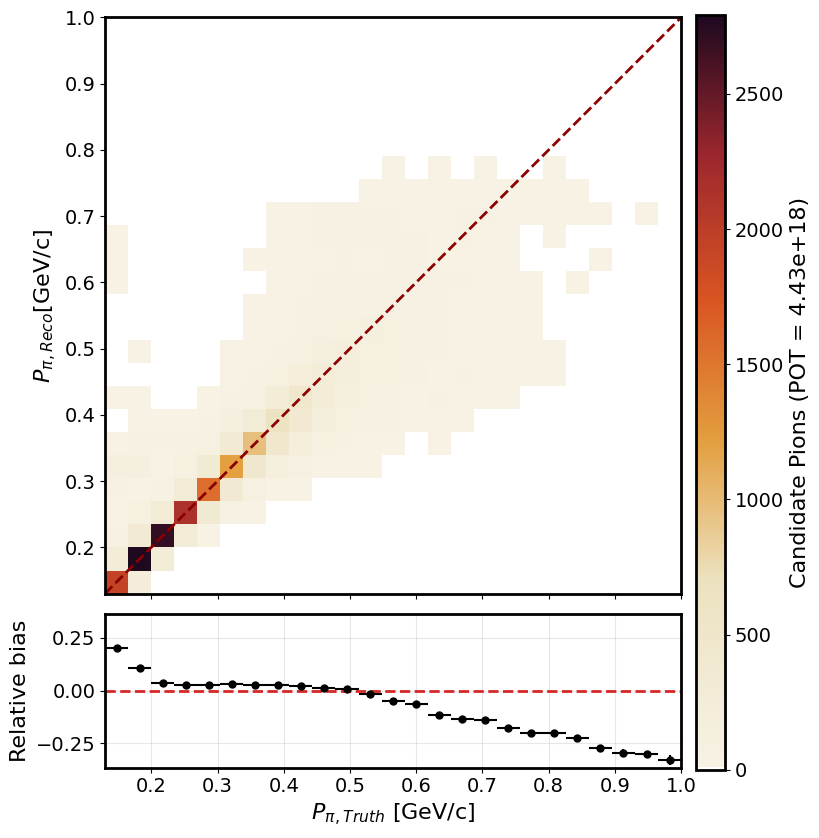

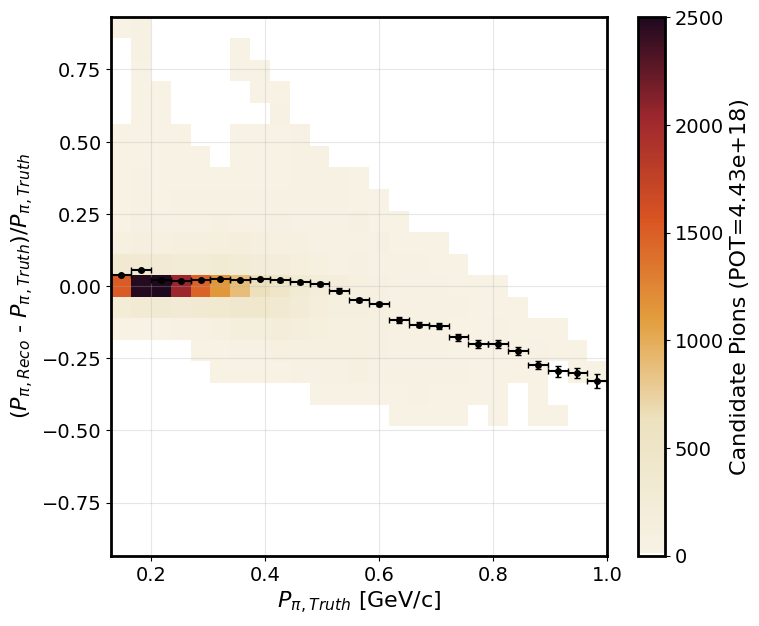

In [8]:
#make it for CC1pi only
##plot_resolution(pion_momentum_config, slc_df[cumulative_mask], slc_df.truth.nu_categ == "CC1pi")
config_vec
fig_res_2d = plot_resolution(pion_momentum_config, mc_evt_df, extra_mask = mask_dict[pion_momentum_config.category_mask](mc_evt_df), data_tot_pot=data_tot_pot, use_percent_bias=True)
fig_bias_2d = plot_bias_2d(pion_momentum_config, mc_evt_df, extra_mask = mask_dict[pion_momentum_config.category_mask](mc_evt_df), use_percent_bias=True, data_tot_pot=data_tot_pot)
   

#make it for mu/pi only if it is a mu/pi plot

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

def plot_1d_res(
    mc_df,
    config,
    title = None,
    weight_column = None,
    use_percent_bias = False,
    extra_mask = None,
    data_tot_pot = None
):
    # --- 1. Pre-processing ---
    slice_levels = ['__ntuple', 'entry', 'rec.slc..index']
    if getattr(config, "first_per_slice", False):
        mc_df = mc_df.groupby(level=slice_levels, sort=False).first()

    if extra_mask is None:
        extra_mask = np.ones(len(mc_df), dtype=bool)

    # Subset the data
    df_plot = mc_df.loc[extra_mask].copy()
    
    # Calculate bias/residual temporarily to create range mask
    truth = df_plot[config.truth_column].values
    reco  = df_plot[config.data_column].values
    x_vals_temp = (reco - truth) / truth if use_percent_bias else (reco - truth)
    
    # APPLY RANGE FILTER: Filter the entire dataframe to keep lengths aligned
    range_mask = (x_vals_temp > -1.5) & (x_vals_temp < 1.5)
    df_plot = df_plot.loc[range_mask].copy()
    df_plot['plot_x'] = x_vals_temp[range_mask]

    # Handle weights on the filtered dataframe
    if weight_column is not None and weight_column in df_plot.columns:
        df_plot['plot_w'] = df_plot[weight_column].values
    else:
        df_plot['plot_w'] = np.ones(len(df_plot))
    
    mc_types = df_plot[config.plot_column]

    # --- AUTO-SELECT COLOR PALETTE ---
    present_categories = set(mc_types.dropna().unique())
    # Note: Ensure category_colors, etc., are defined in your global scope
    palettes = [category_colors, category_colors_pfp, proton_distinction_category_colors]
    
    chosen_map = category_colors
    max_overlap = -1
    for p in palettes:
        overlap = len(present_categories.intersection(p.keys()))
        if overlap > max_overlap:
            max_overlap = overlap
            chosen_map = p

    # --- 2. Sorting Categories (Signal vs Background) ---
    category_totals = [(t, df_plot.loc[mc_types == t, 'plot_w'].sum()) 
                       for t in mc_types.dropna().unique()]
    
    signal_keys = ["CC1pi"]
    signals = sorted([x for x in category_totals if x[0] in signal_keys], key=lambda x: x[1], reverse=True)
    backgrounds = sorted([x for x in category_totals if x[0] not in signal_keys], key=lambda x: x[1], reverse=True)
    
    sorted_types = [x[0] for x in signals + backgrounds]
    stack_data = [df_plot.loc[mc_types == t, 'plot_x'].dropna() for t in sorted_types]
    stack_weights = [df_plot.loc[d.index, 'plot_w'] for d in stack_data]
    
    bins = np.linspace(-1.5, 1.5, 36)

    # --- 3. Setup Figure ---
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [chosen_map.get(t, "#7f7f7f") for t in sorted_types]

    # Plot "All" Histogram
    ax.hist(df_plot['plot_x'], bins=bins, weights=df_plot['plot_w'],
            histtype='stepfilled', color='black', linewidth=2.5, alpha=0.05)
    ax.hist(df_plot['plot_x'], bins=bins, weights=df_plot['plot_w'],
            histtype='step', color='black', linewidth=2.5)
                
    # Plot Individual Histograms
    ax.hist(stack_data, bins=bins, weights=stack_weights,
            stacked=False, histtype='stepfilled', color=colors, alpha=0.3)
    ax.hist(stack_data, bins=bins, weights=stack_weights,
            stacked=False, histtype='step', color=colors, linewidth=2)

    # --- 4. Statistics Box ---
    def get_full_stats(vals, wgts):
        if len(vals) == 0: return 0, 0, 0, 0
        m = np.average(vals, weights=wgts)
        s = np.sqrt(np.average((vals - m)**2, weights=wgts))
        m_err = s / np.sqrt(len(vals))
        s_err = s / np.sqrt(2 * len(vals))
        return m, m_err, s, s_err

    m_mc, me_mc, s_mc, se_mc = get_full_stats(df_plot['plot_x'].values, df_plot['plot_w'].values)
    
    # Bolding header with LaTeX and ensuring right alignment
    stats_str = (fr"$\mathbf{{Final\ stats}}$" + "\n" +
                 f"Bias: {m_mc:.3f} $\pm$ {me_mc:.3f}\n" +
                 f"Res: {s_mc:.3f} $\pm$ {se_mc:.3f}")

    sidebar_x = 0.95 
    stats_y_top = 0.95 
    
    ax.text(sidebar_x, stats_y_top, stats_str, transform=ax.transAxes, 
            fontsize=14, verticalalignment='top', horizontalalignment='right', 
            multialignment='left', # Set to right to match horizontalalignment
            bbox=dict(boxstyle='square,pad=0.5', facecolor='white', 
                      edgecolor='black', linewidth=1.5, alpha=1.0))

    # --- 5. Custom Legend ---
    mc_hand = [Patch(facecolor=to_rgba(chosen_map.get(t, "#7f7f7f"), 0.3), 
                     edgecolor=chosen_map.get(t, "#7f7f7f"), 
                     label=bkg_name_nice_map.get(t, t)) for t in sorted_types]
    
    all_hand = Patch(facecolor=to_rgba('black', 0.05), edgecolor='black', label='All')
    total_handles = [all_hand] + mc_hand
    
    leg = ax.legend(handles=total_handles, loc='upper right', 
                    bbox_to_anchor=(sidebar_x + 0.0125, 0.78),
                    fontsize=12, framealpha=1.0, edgecolor='black', 
                    fancybox=False, borderaxespad=0.)
    
    leg.get_frame().set_linewidth(1.5)
    leg._legend_box.align = "left"

    # --- Labels & Style ---
    xlabel = config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$ ' + config.unit
    if use_percent_bias:
        xlabel = '('+config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$)/' + config.title + r'$_{,Truth}$' 

    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"{config.ylabel} (POT={data_tot_pot:2.2e})")

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


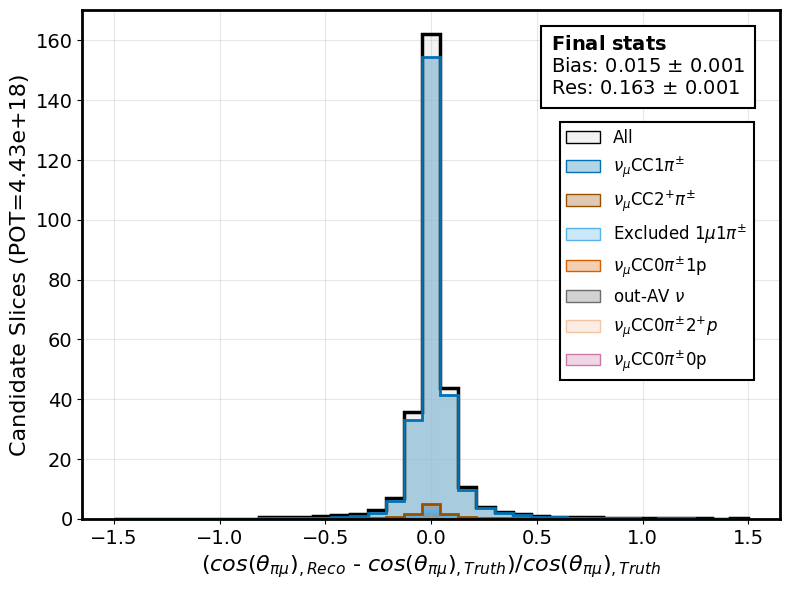

In [10]:
fig = plot_1d_res(
                mc_df = mc_evt_df,
                config = angle_between_candidates_config,
                title = angle_between_candidates_config.title,
                weight_column = ('slc', 'wgt', '', '', '', ''),
                use_percent_bias = True,
                extra_mask = None,
                data_tot_pot = data_tot_pot
            )
    

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


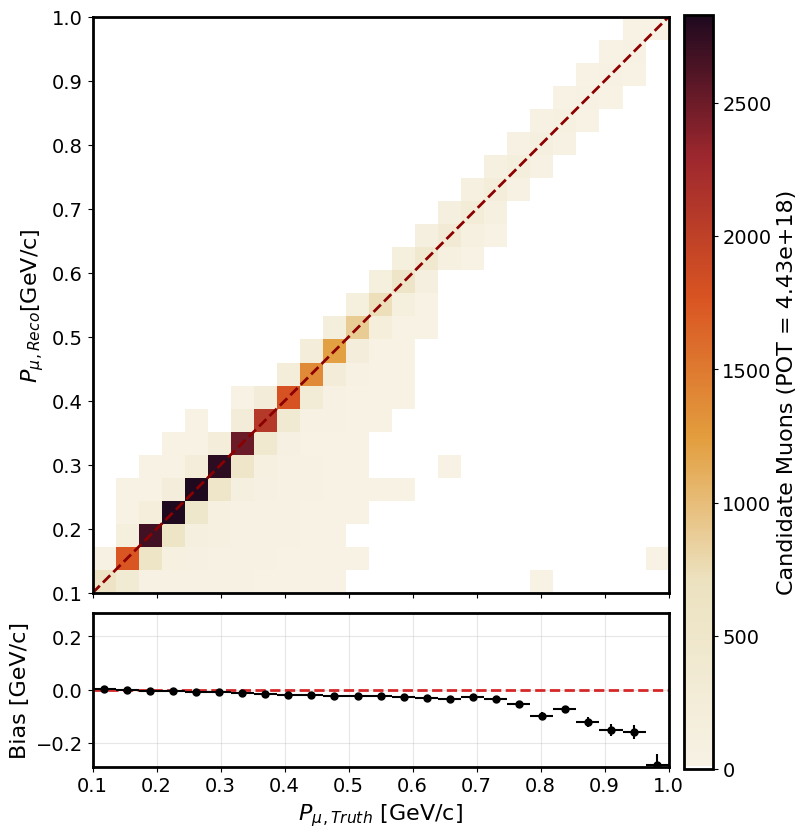

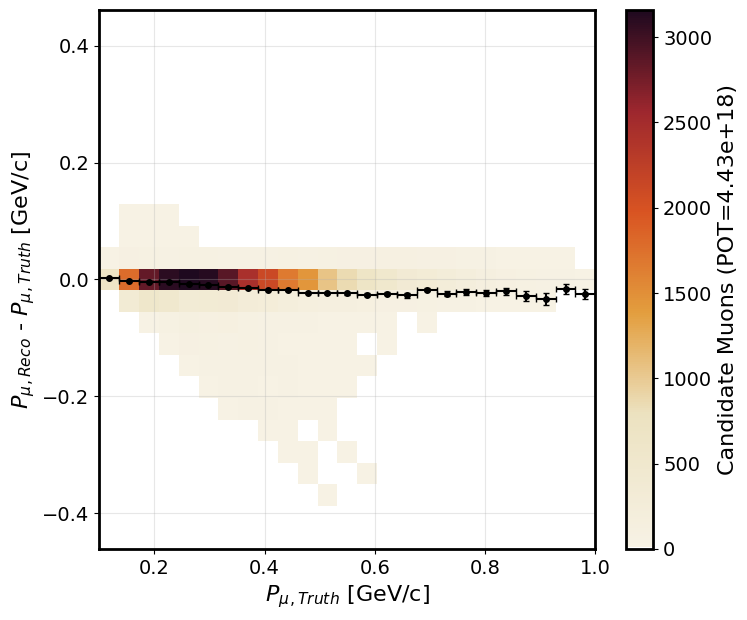

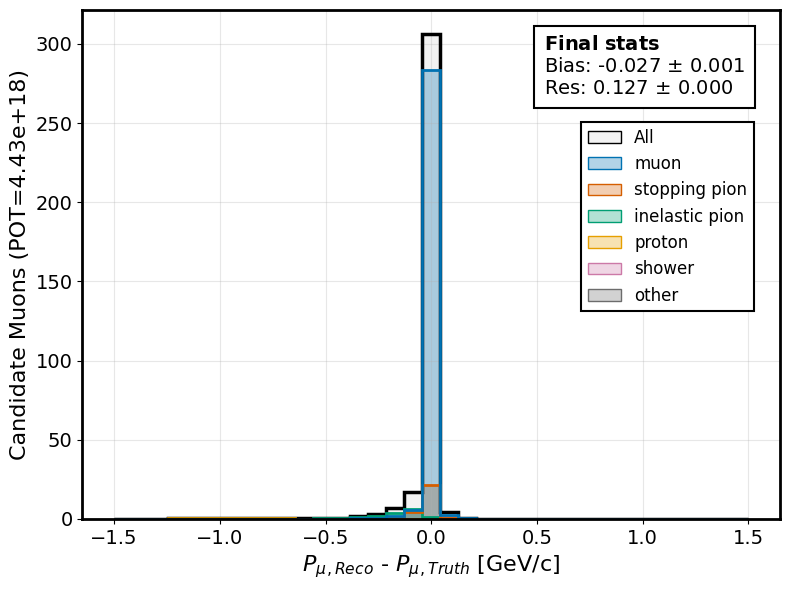

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


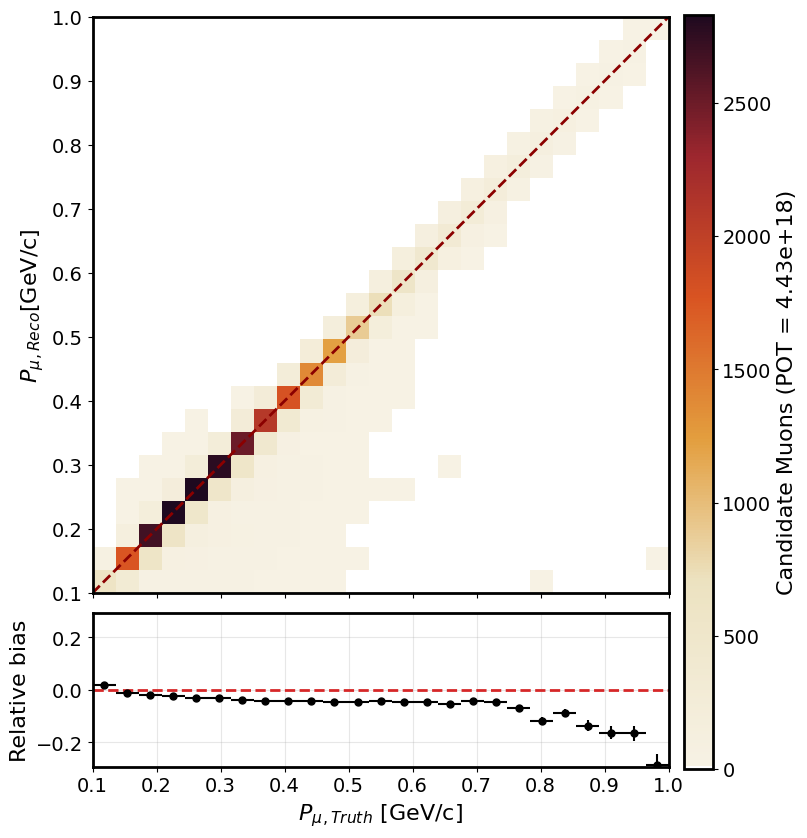

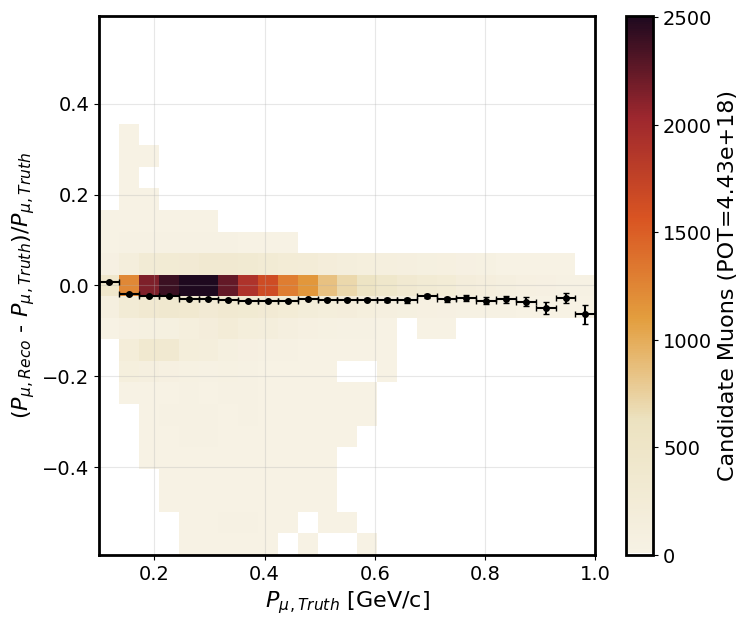

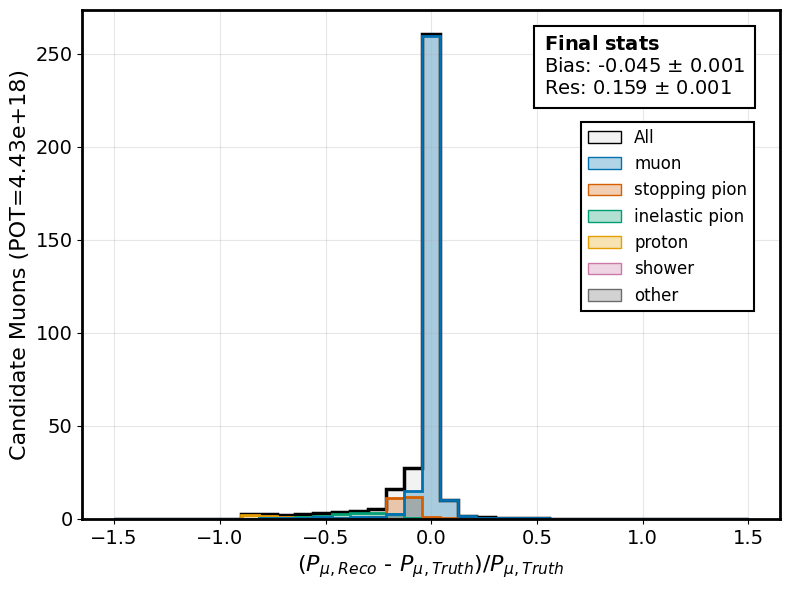

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


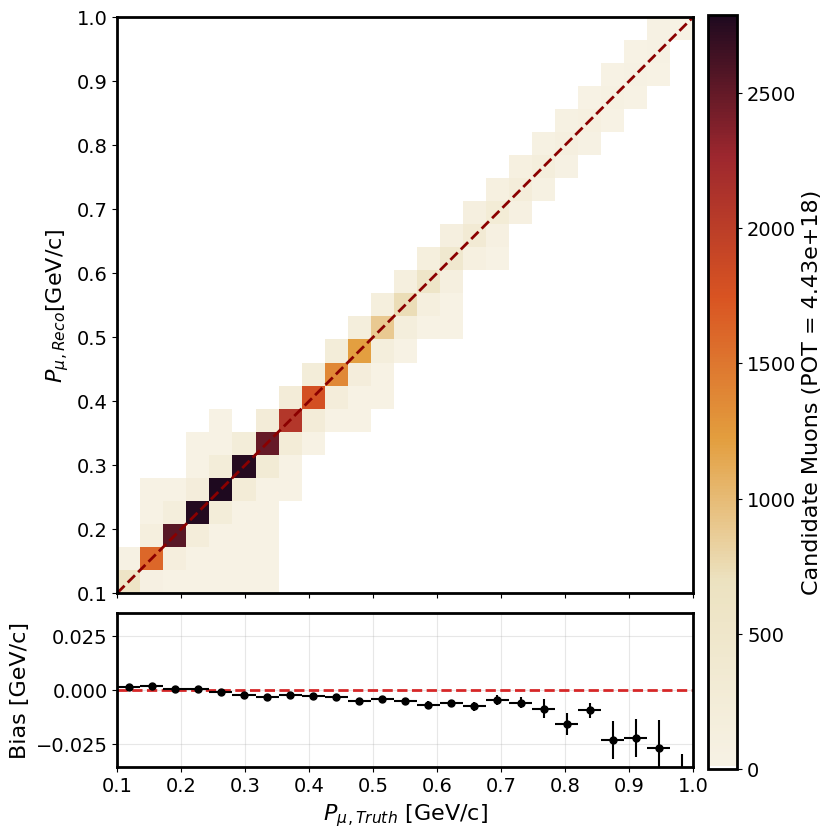

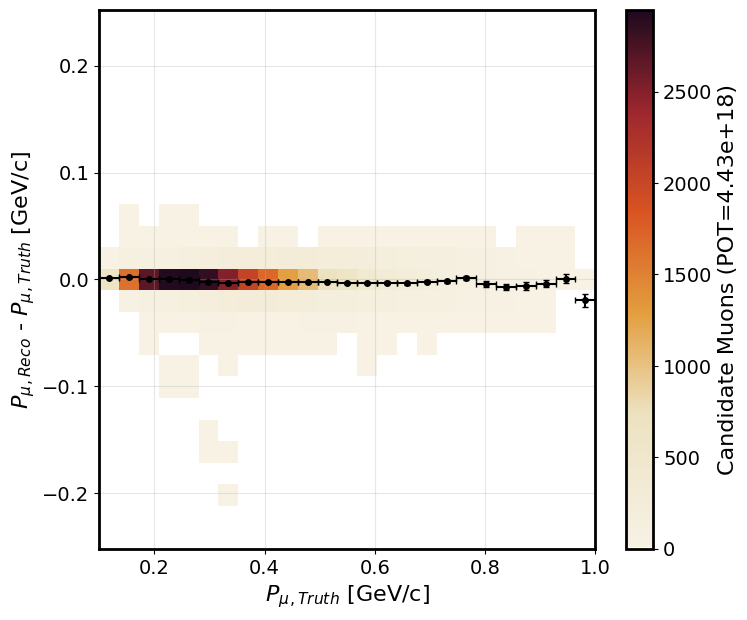

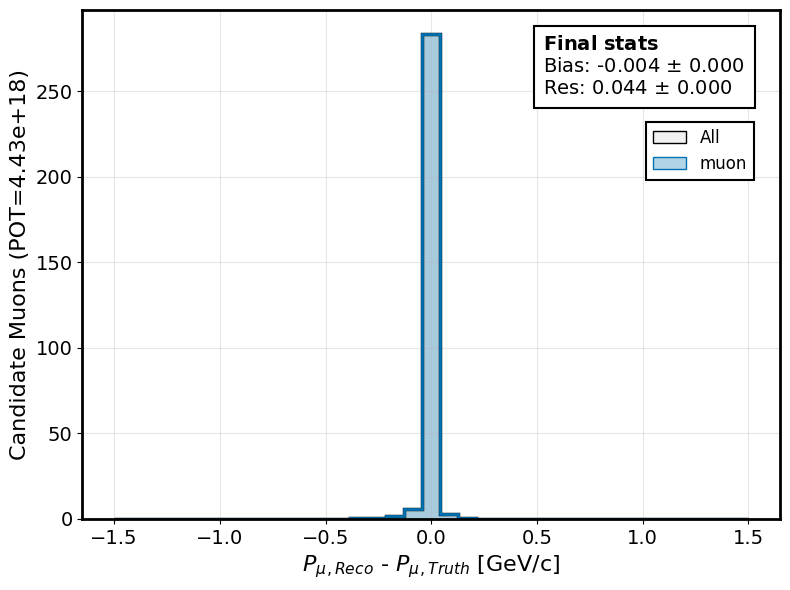

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


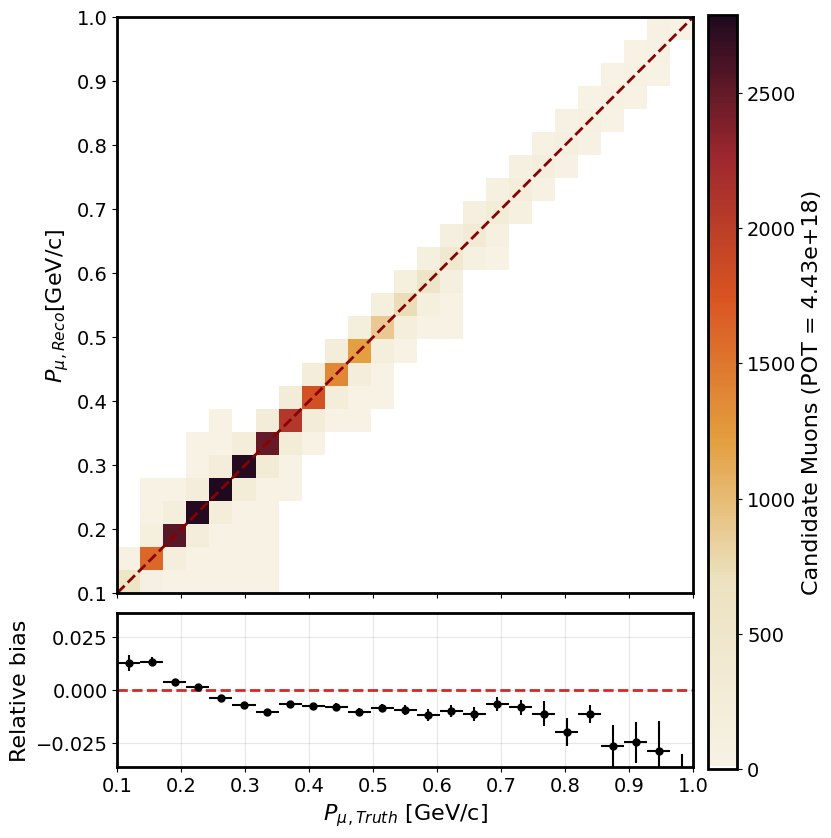

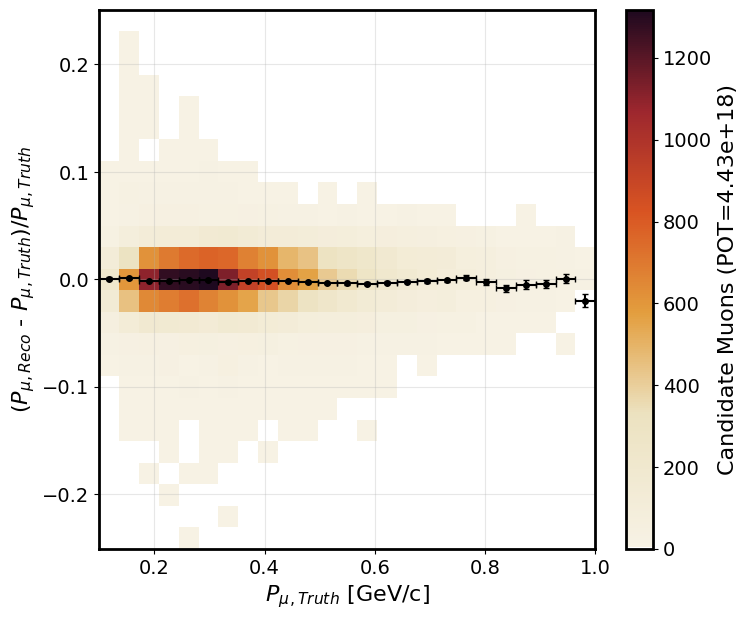

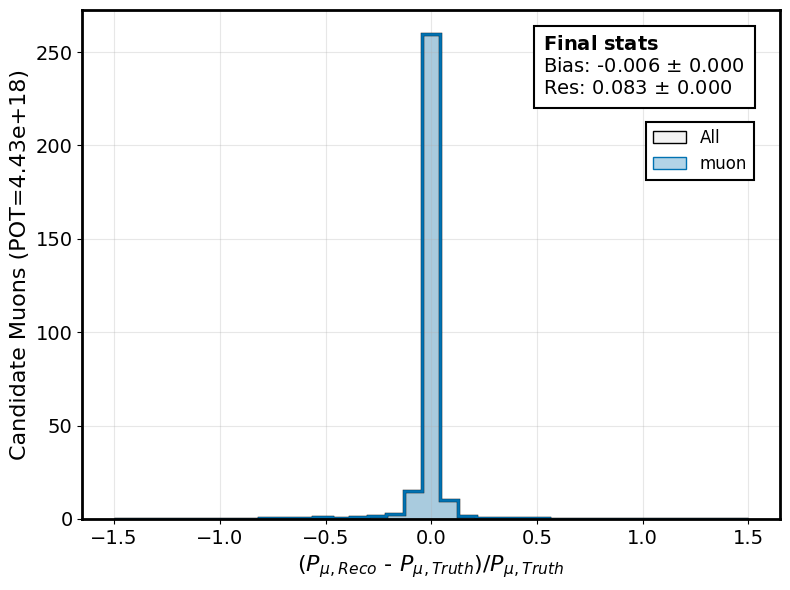

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


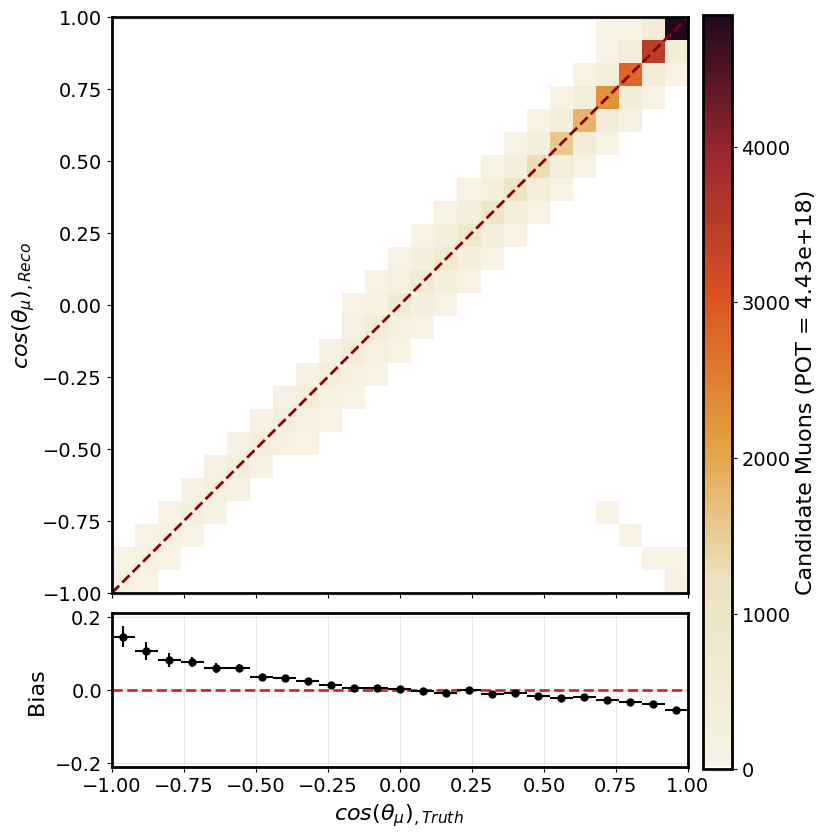

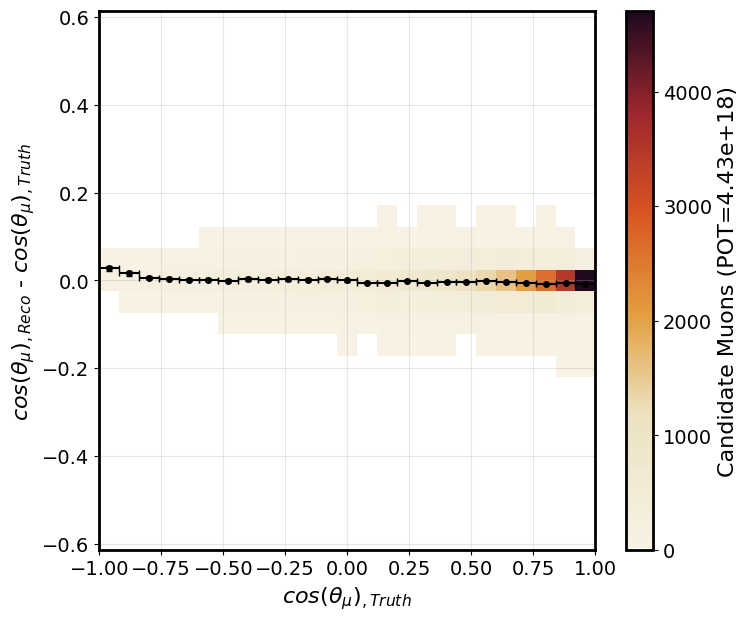

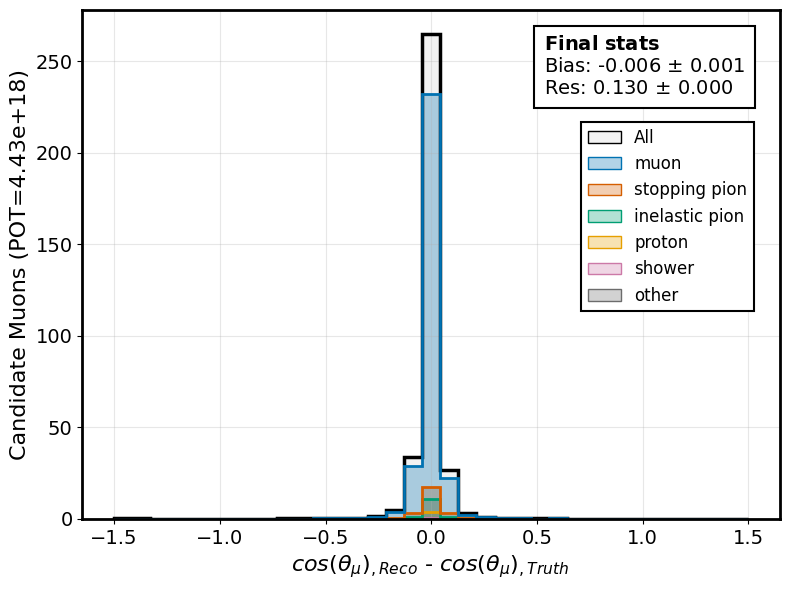

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


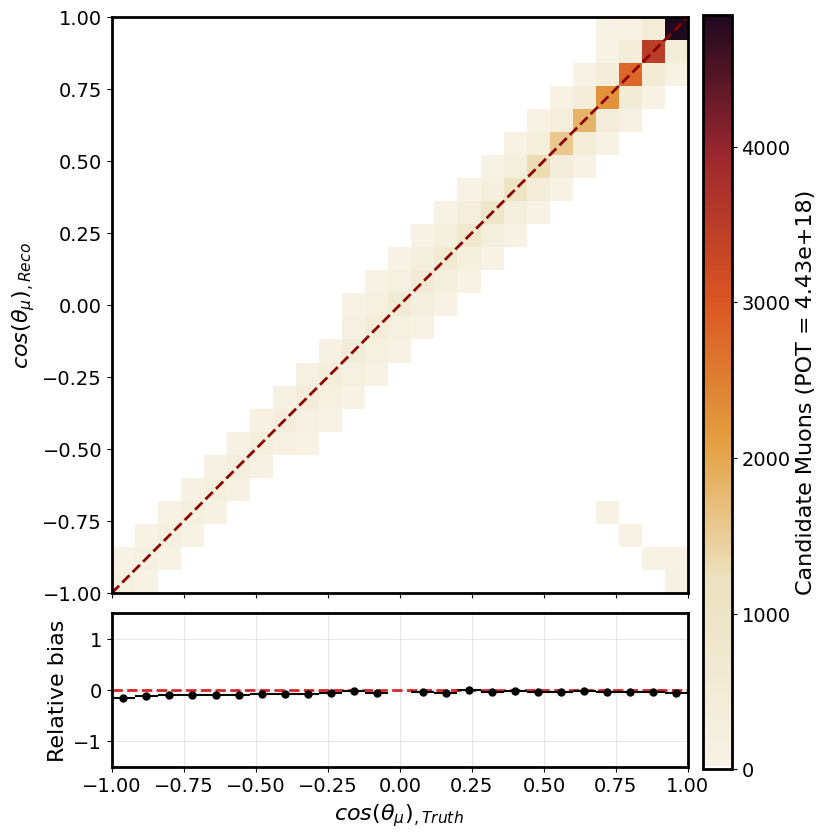

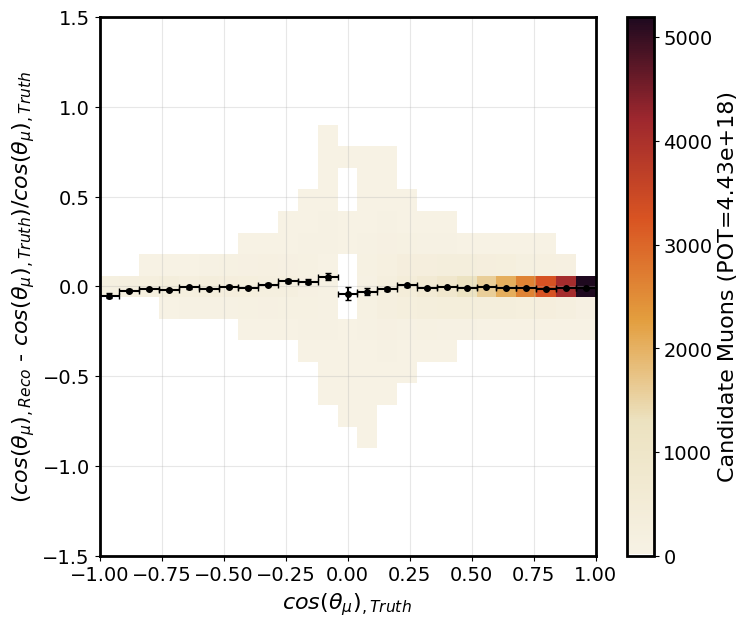

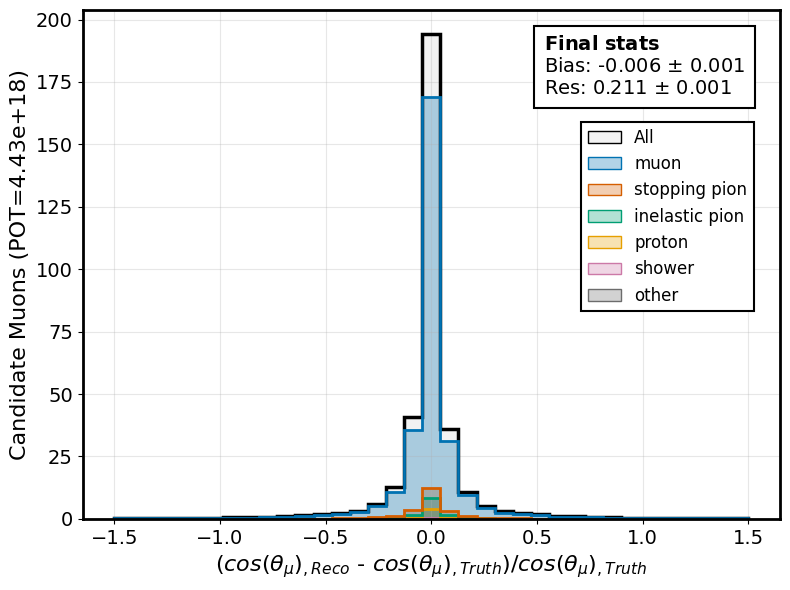

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


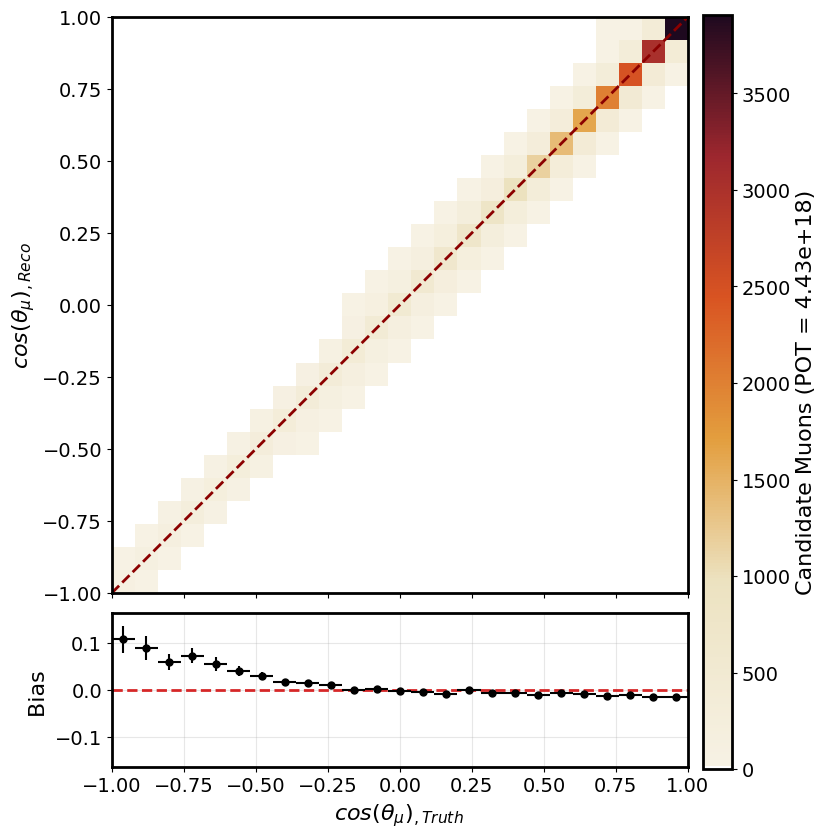

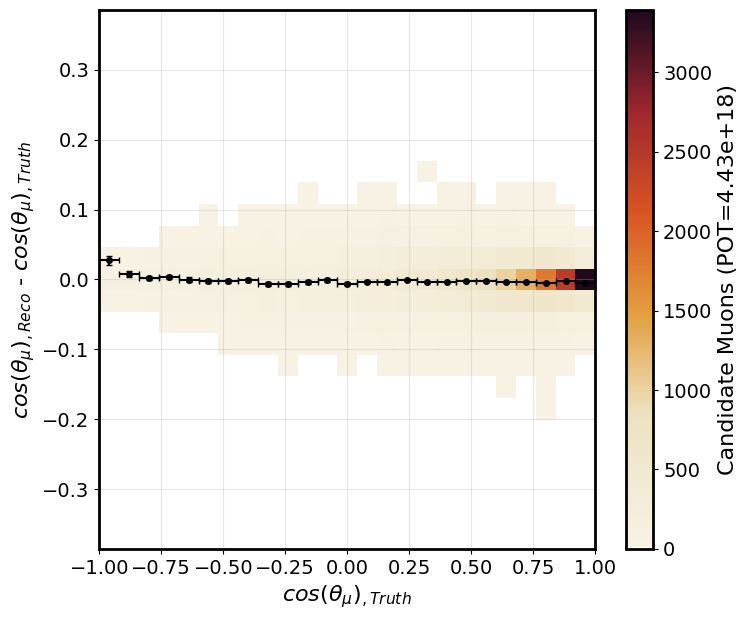

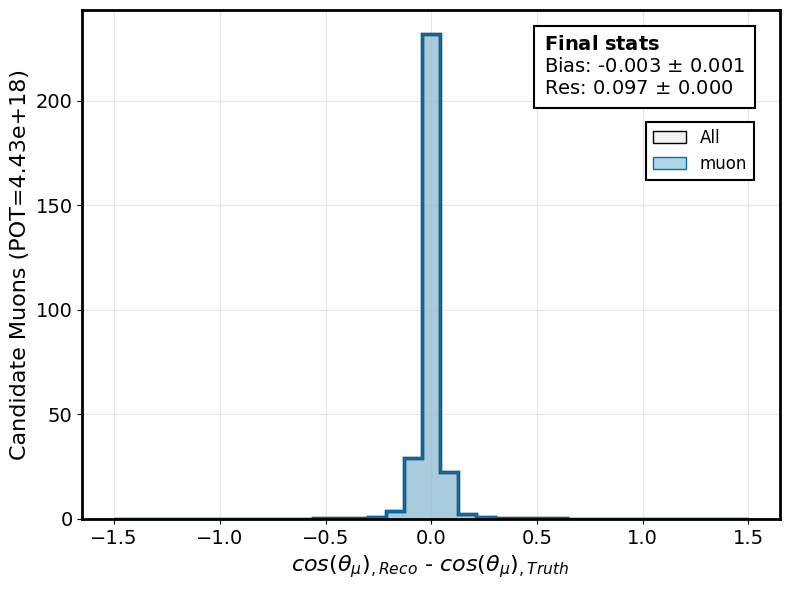

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


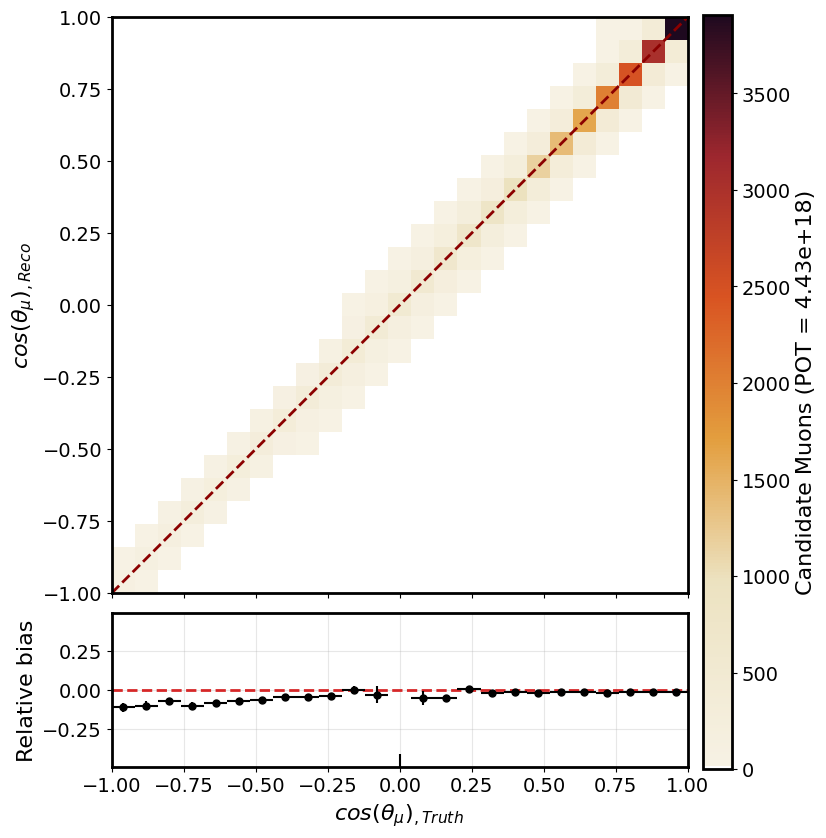

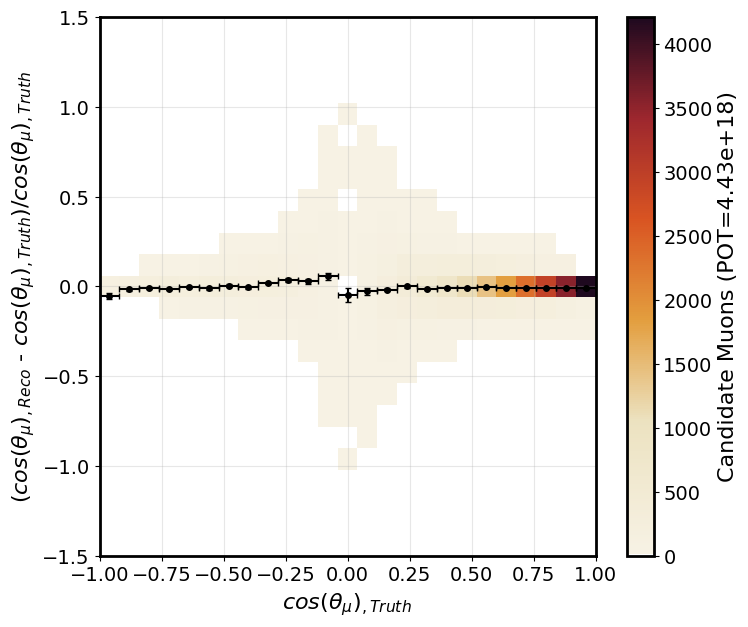

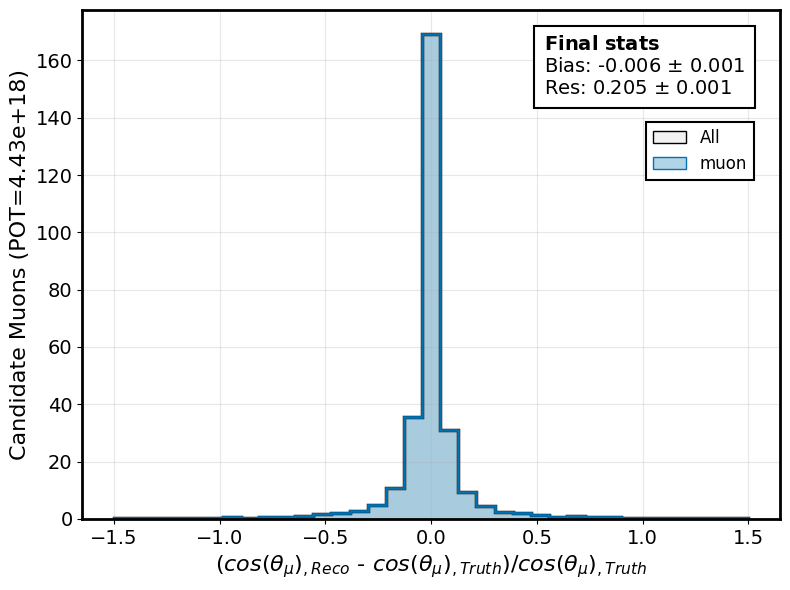

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


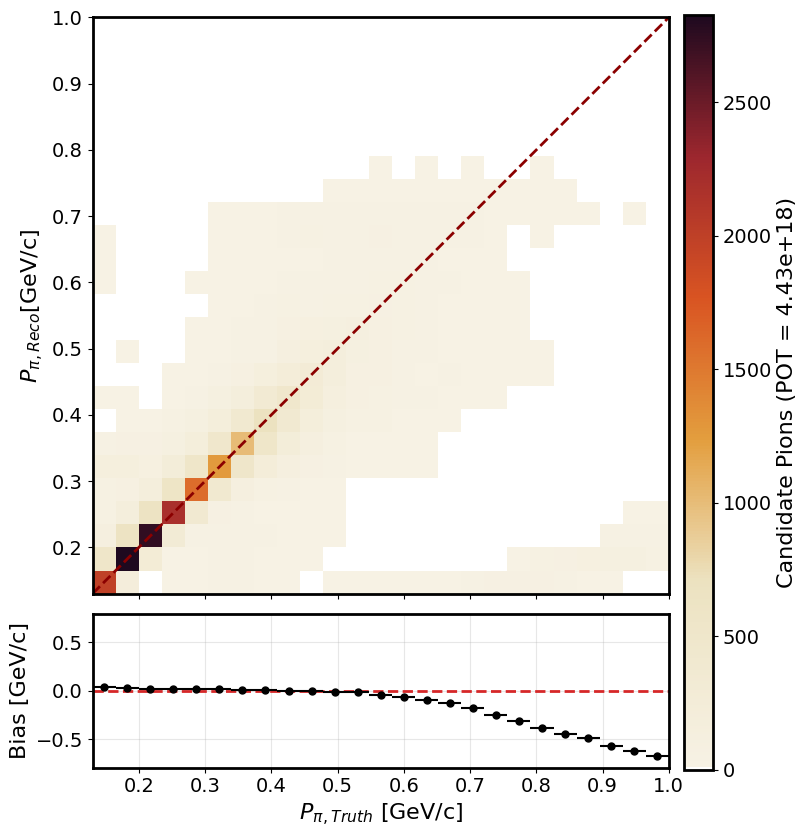

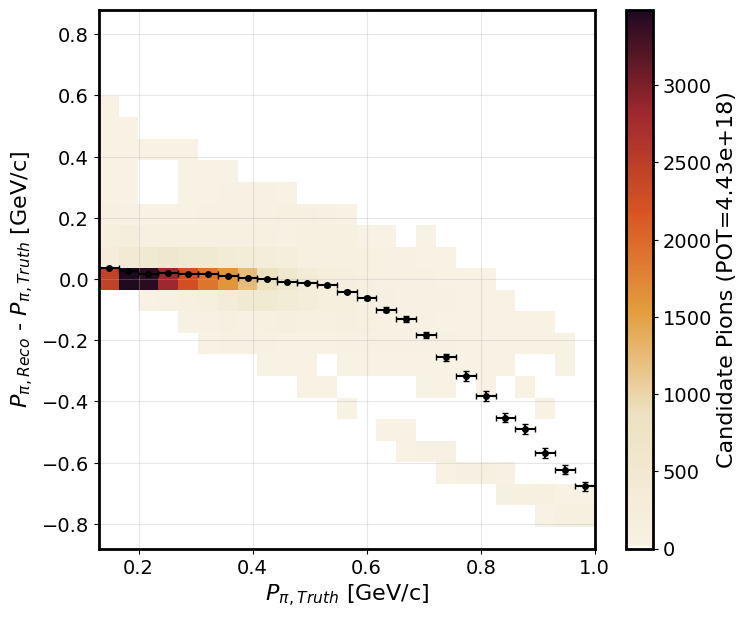

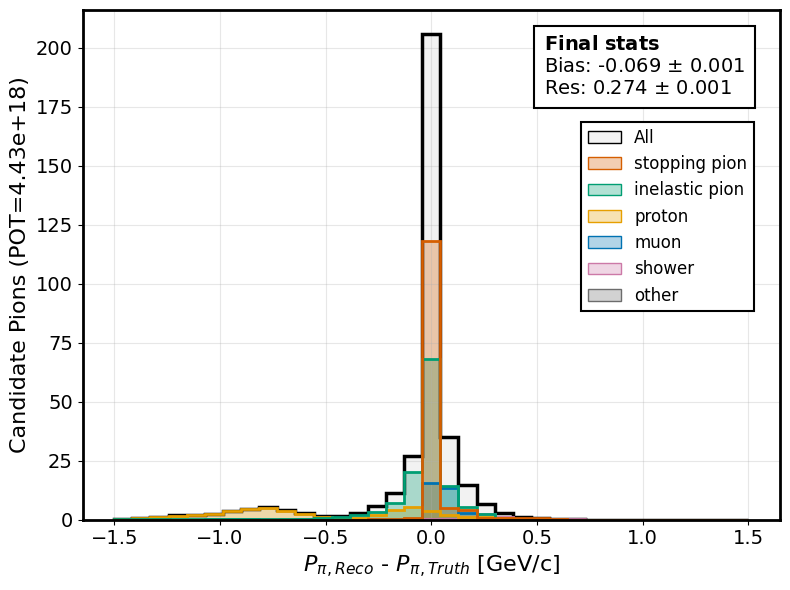

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


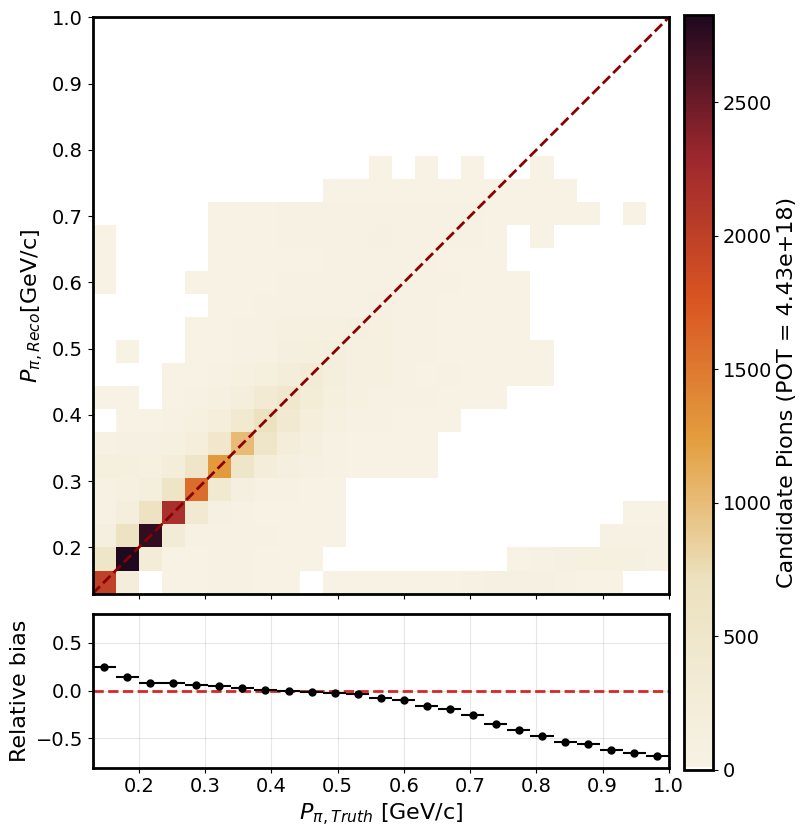

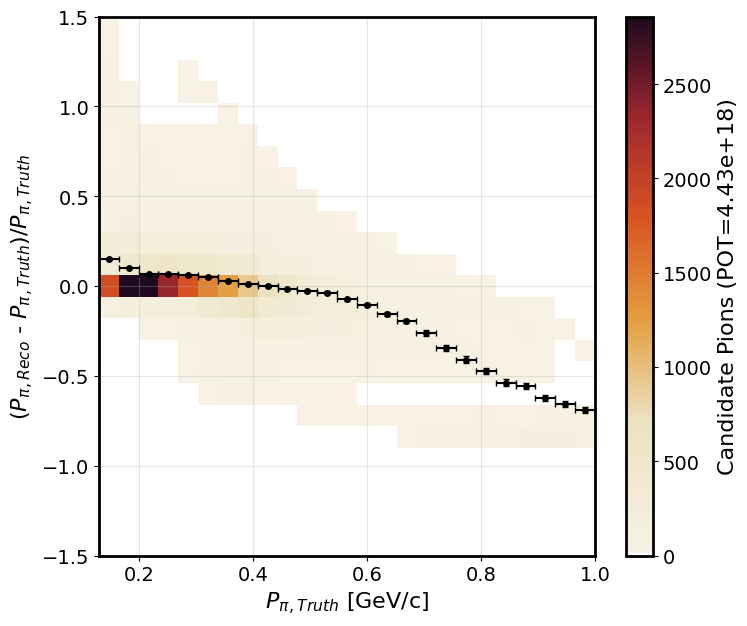

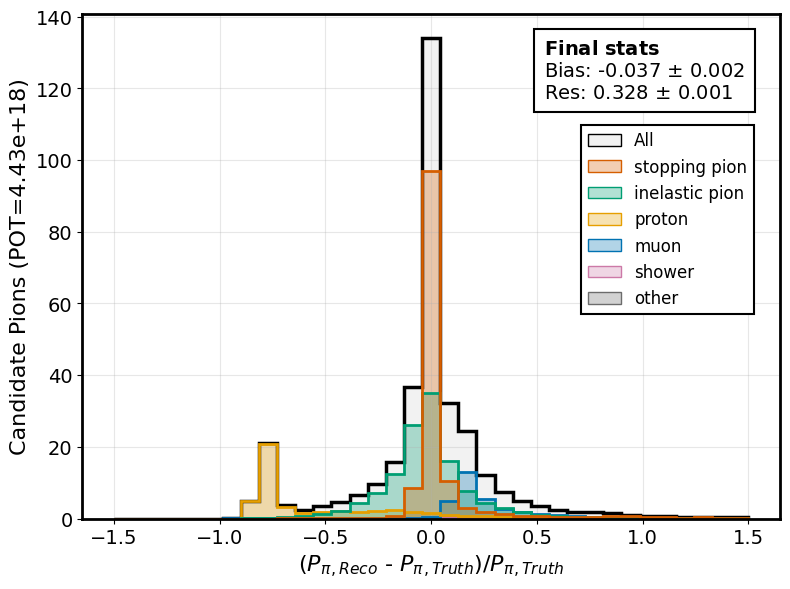

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


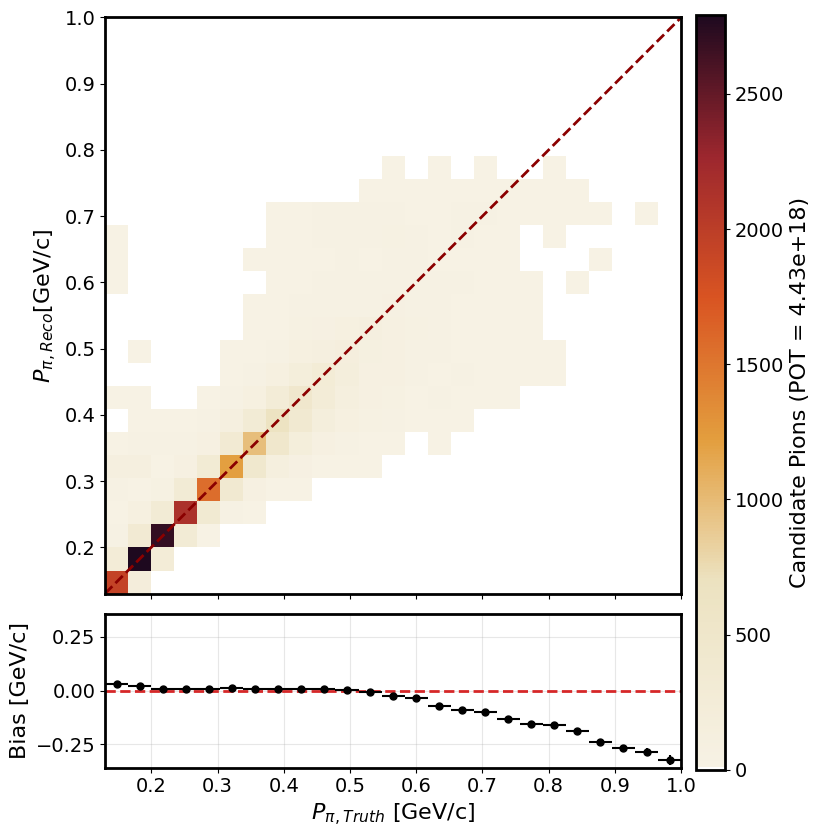

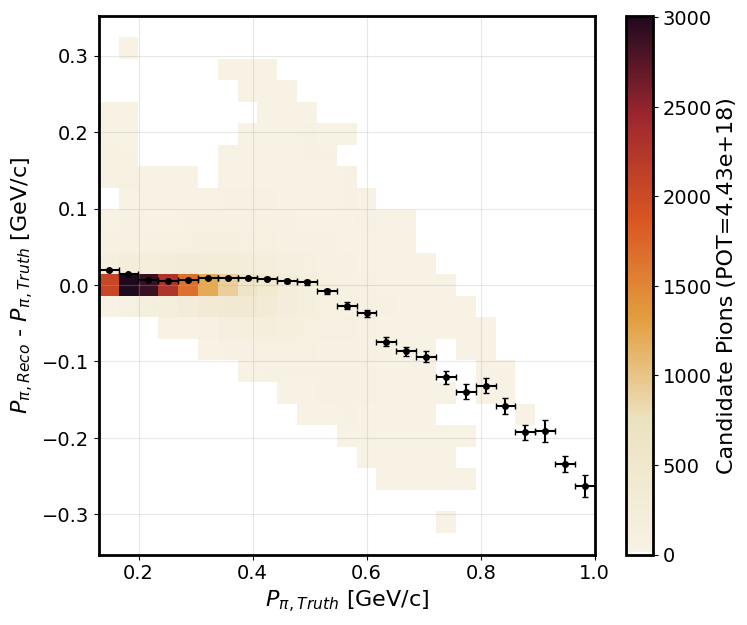

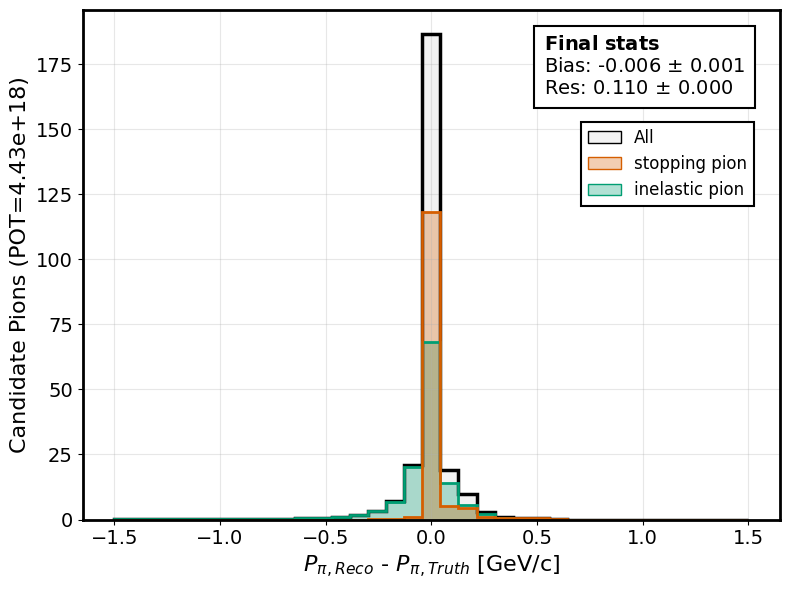

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


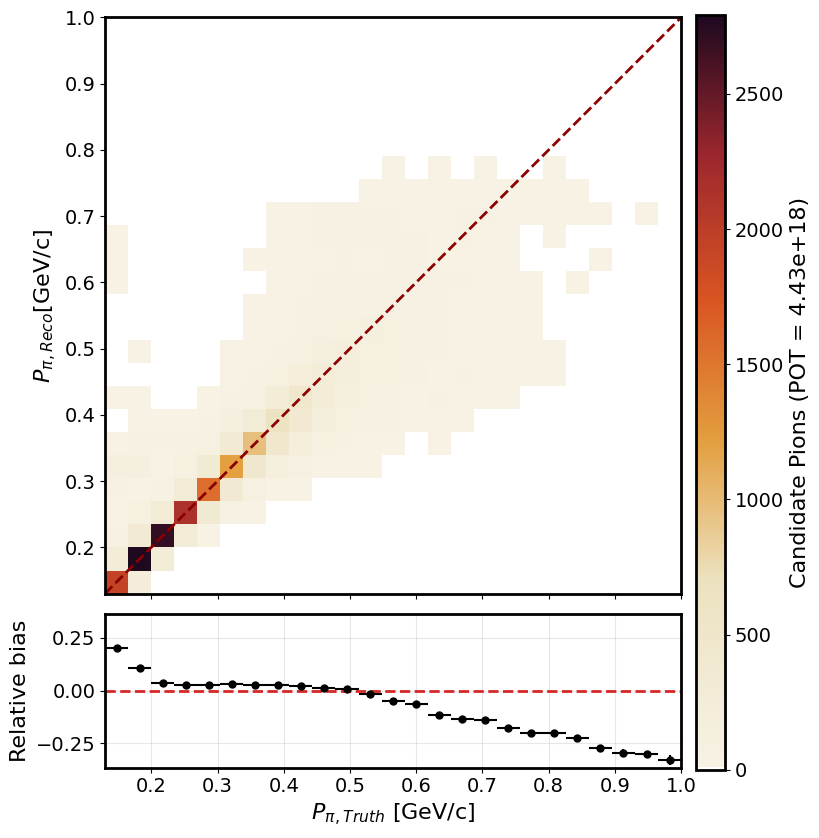

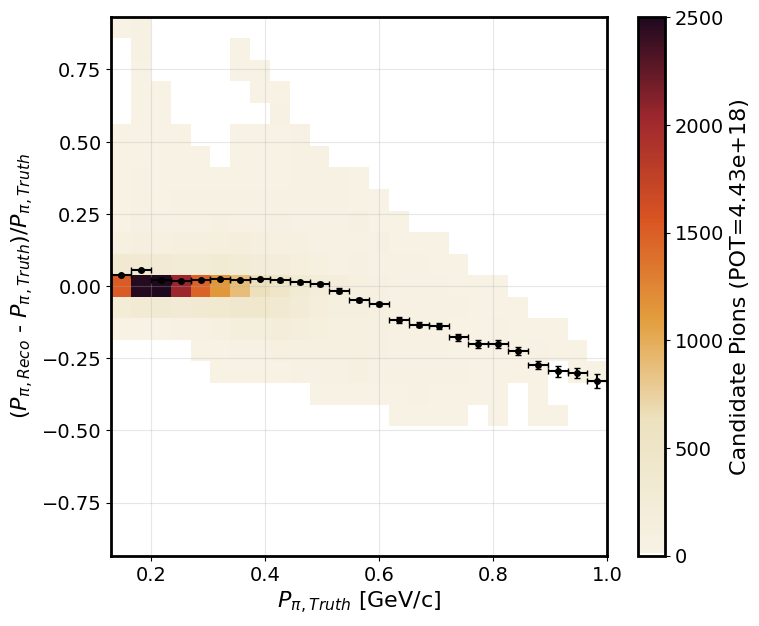

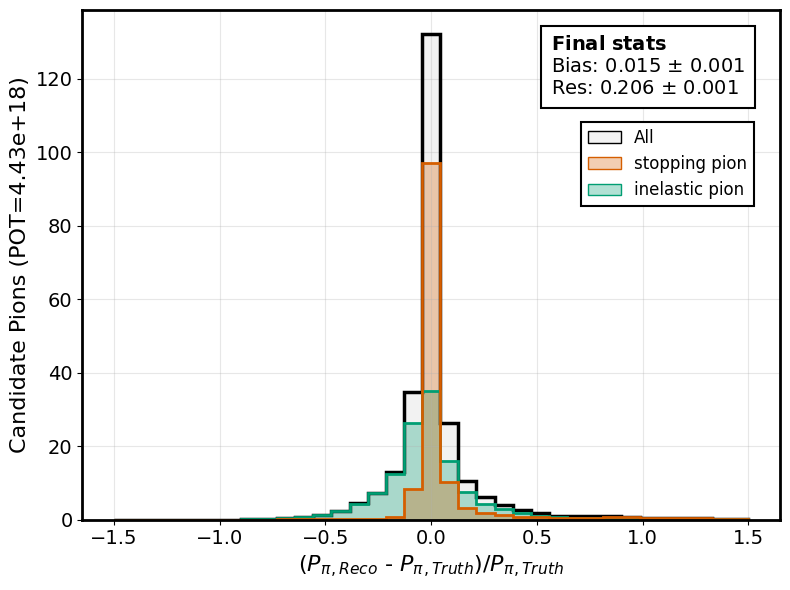

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


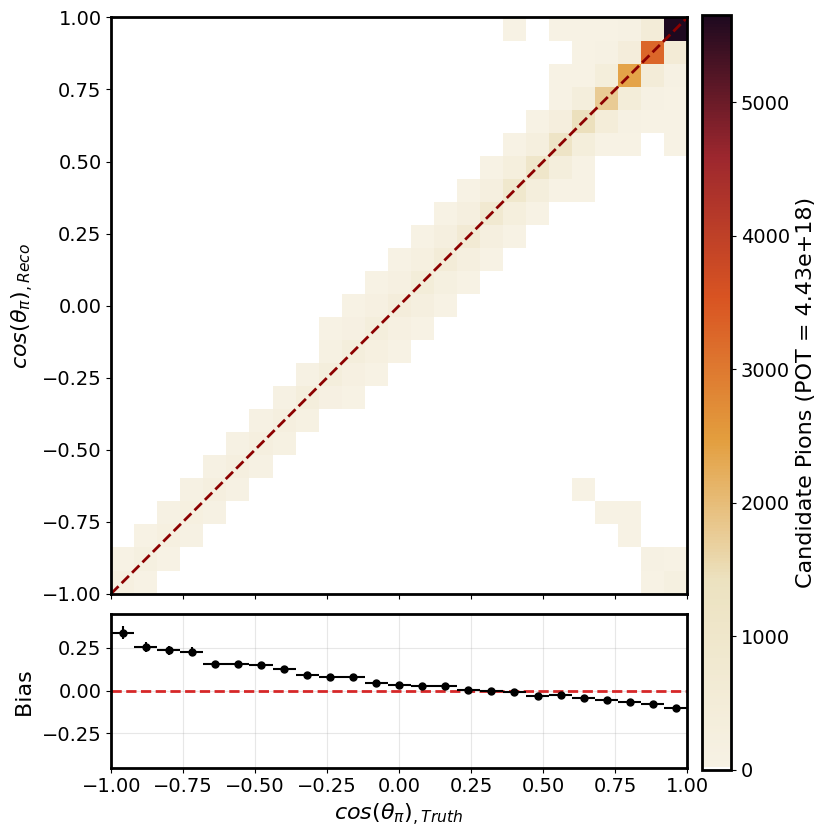

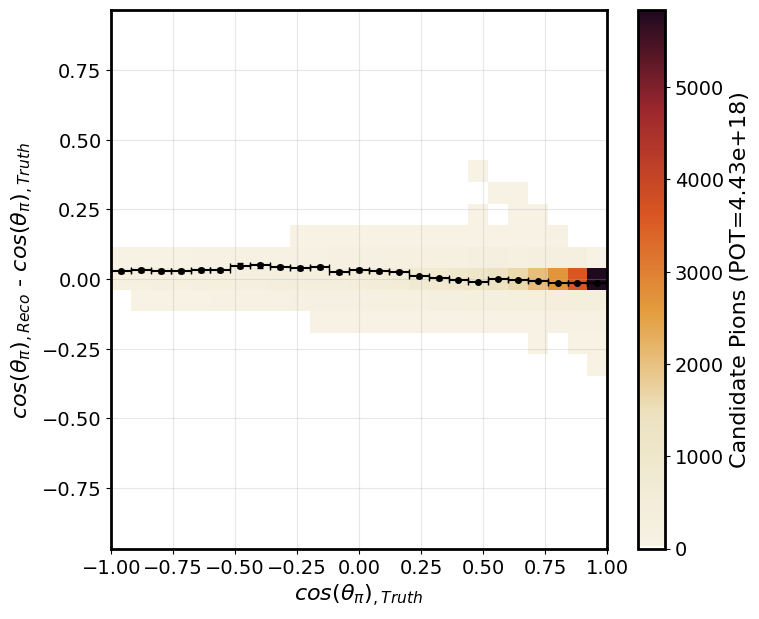

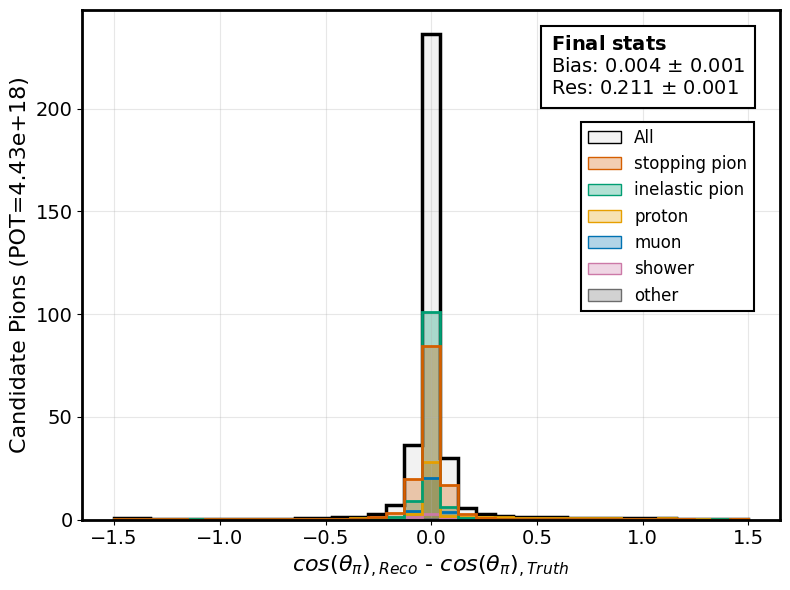

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


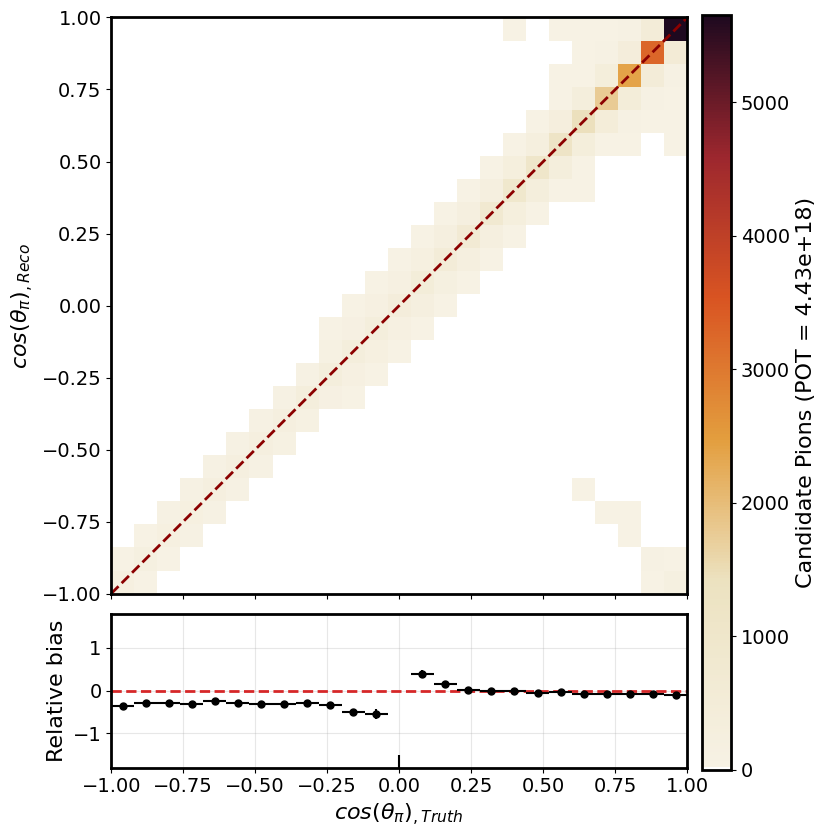

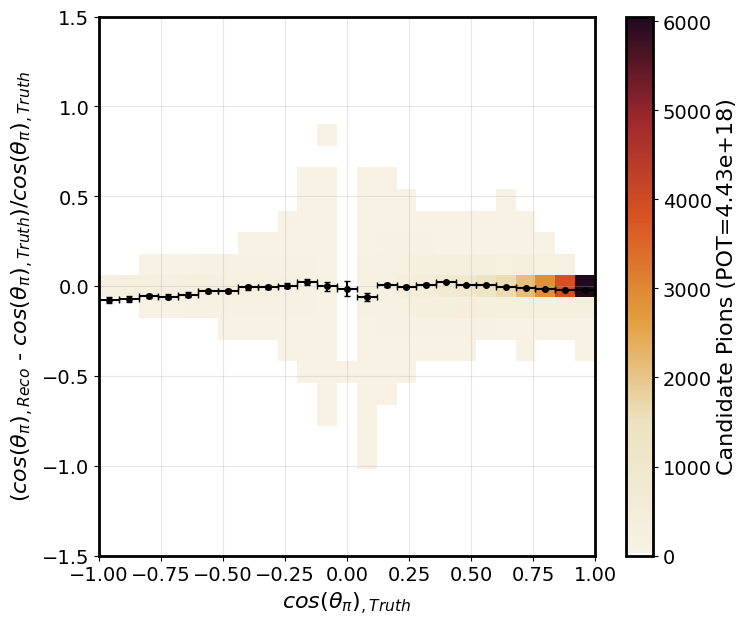

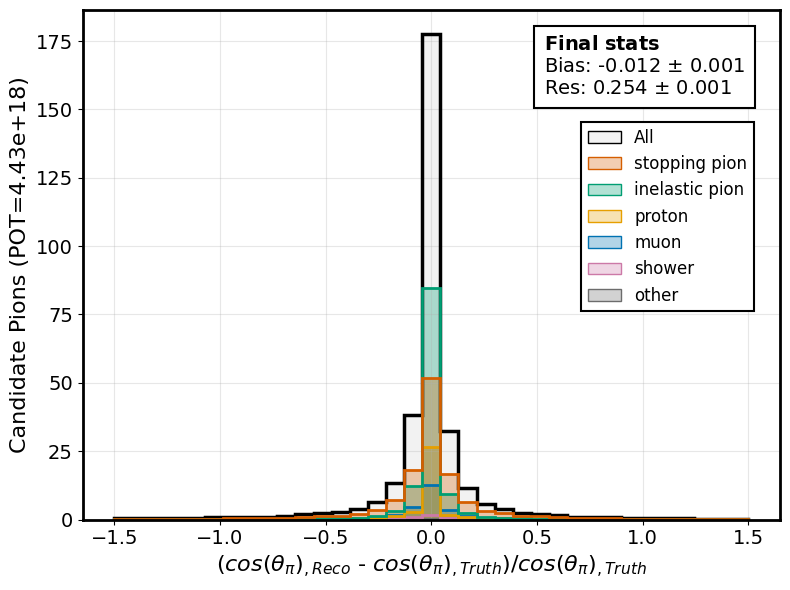

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


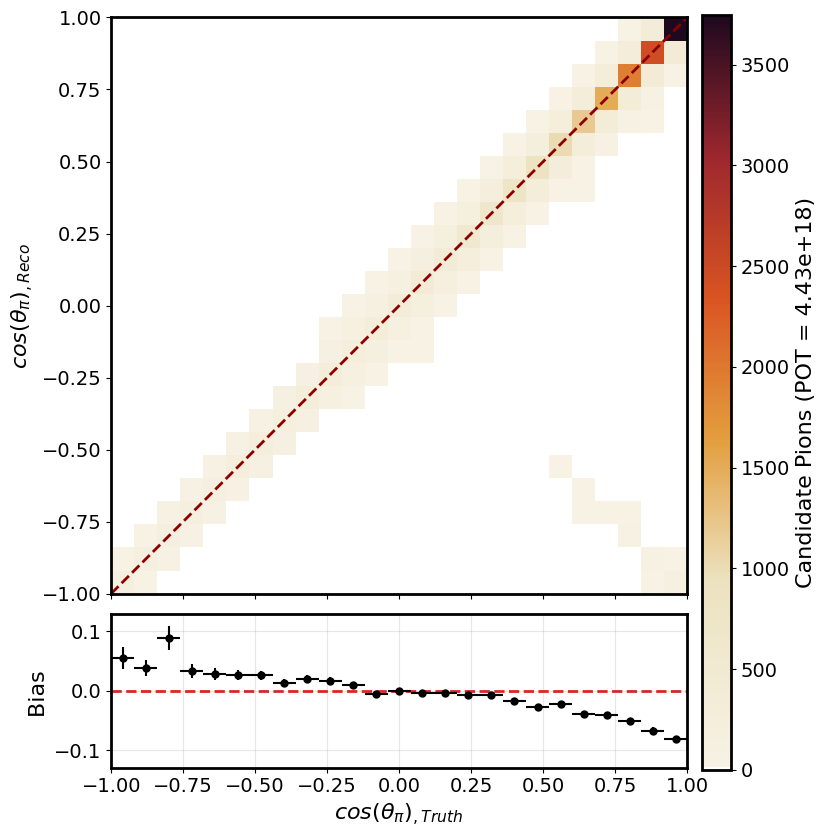

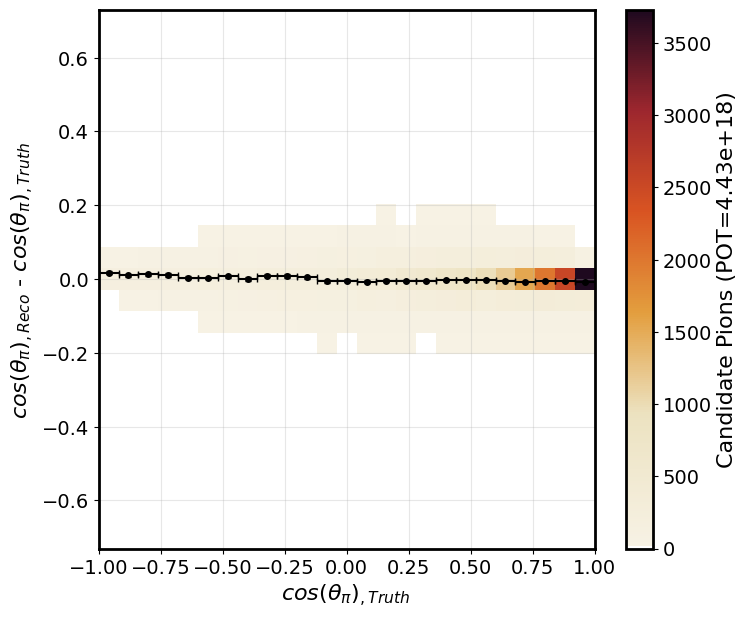

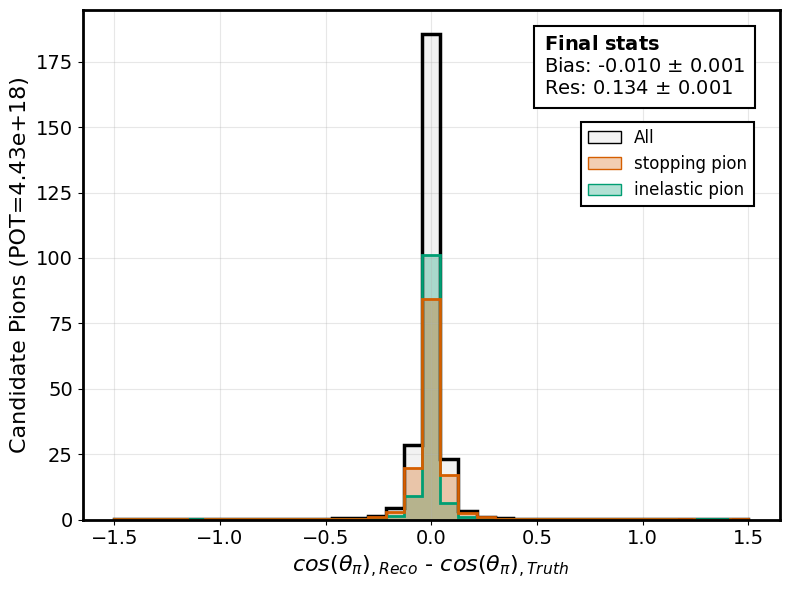

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


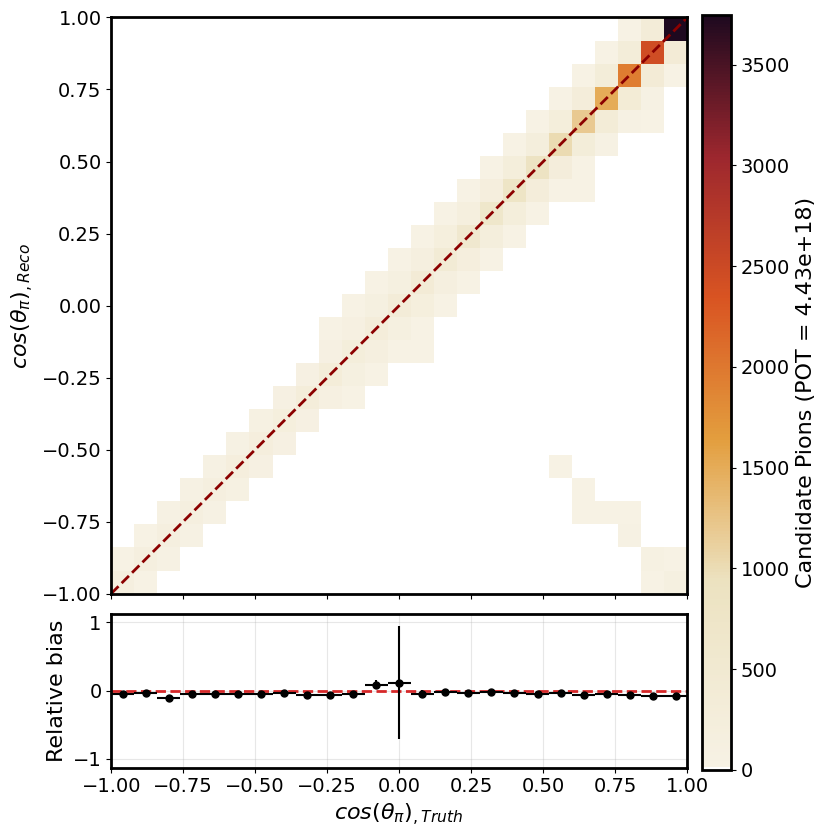

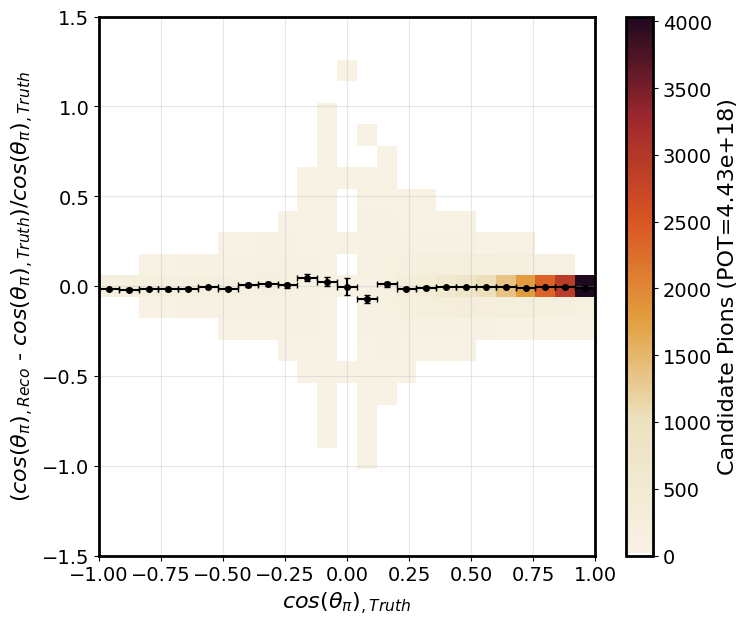

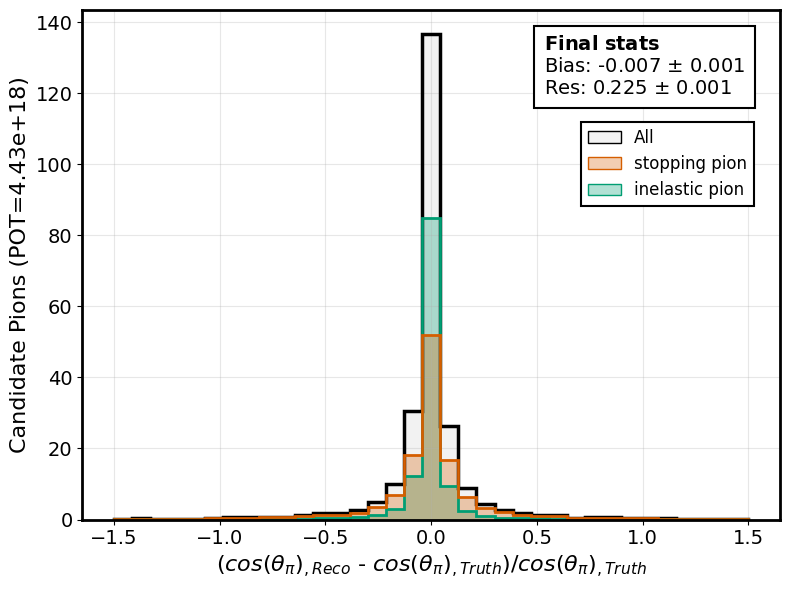

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


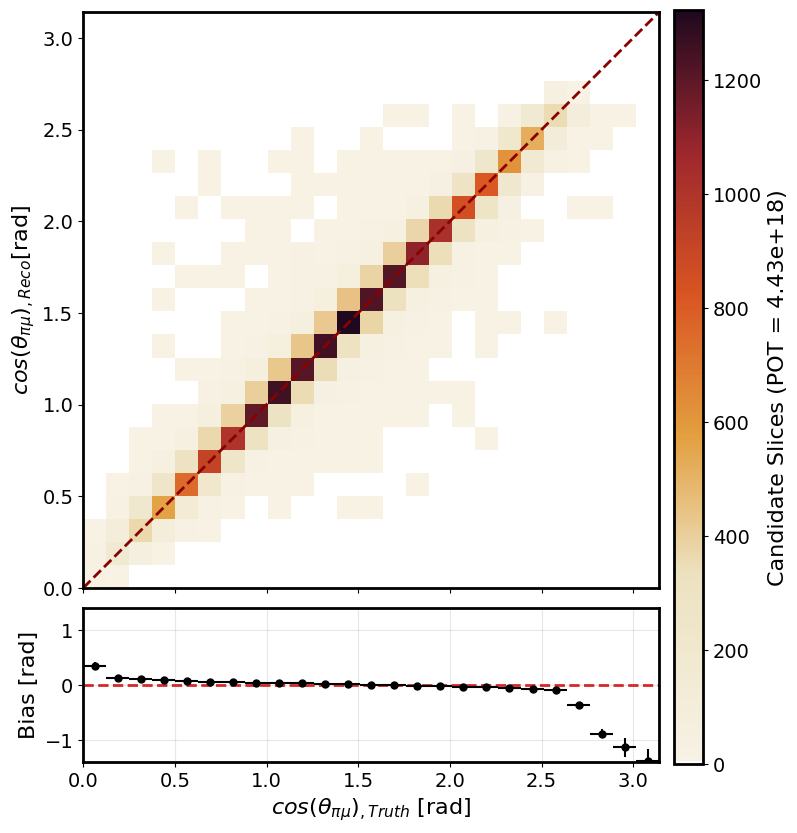

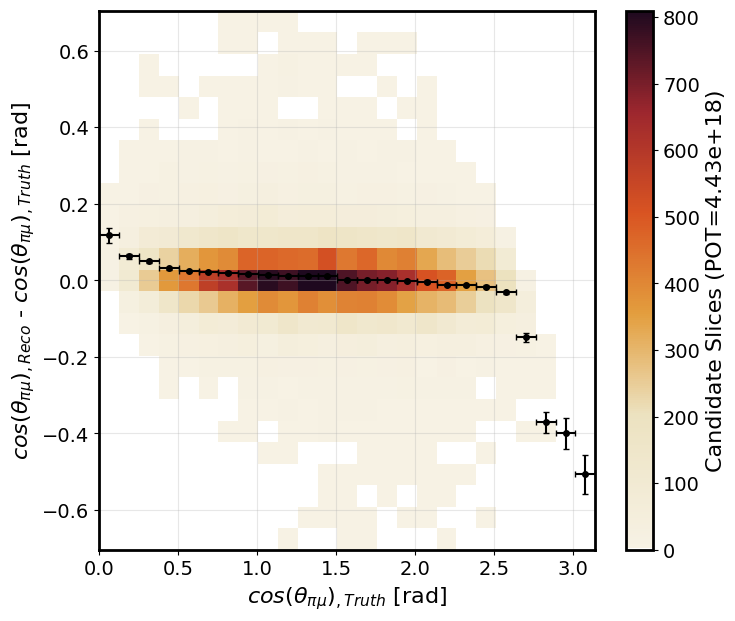

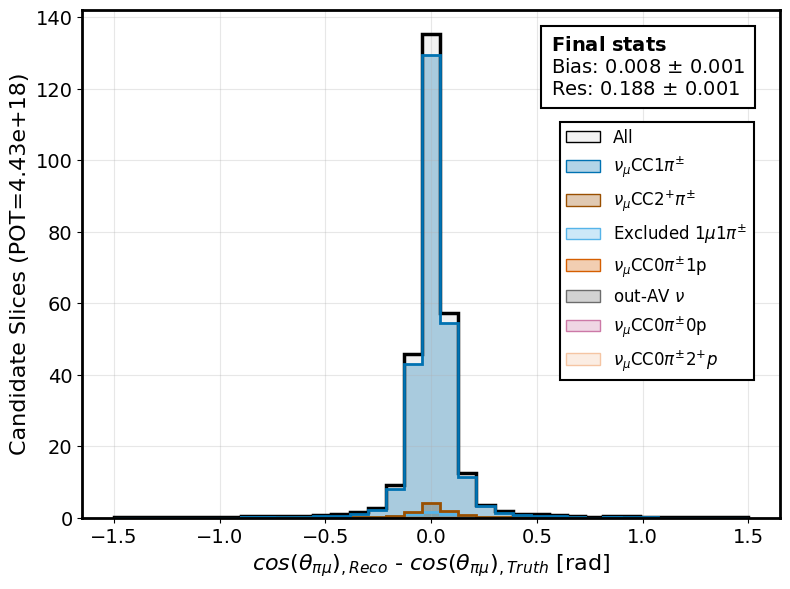

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


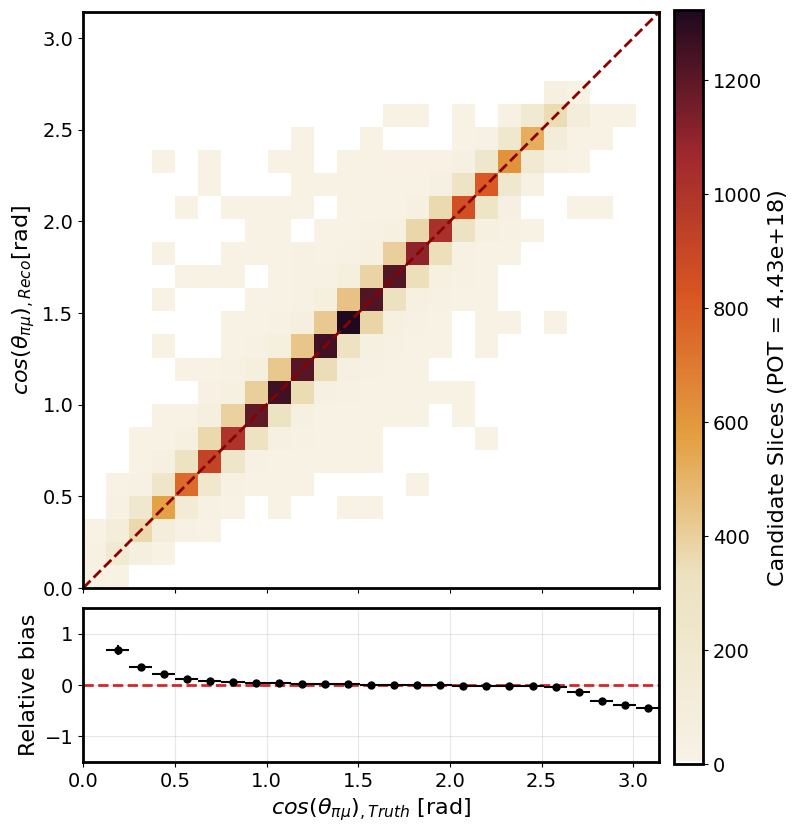

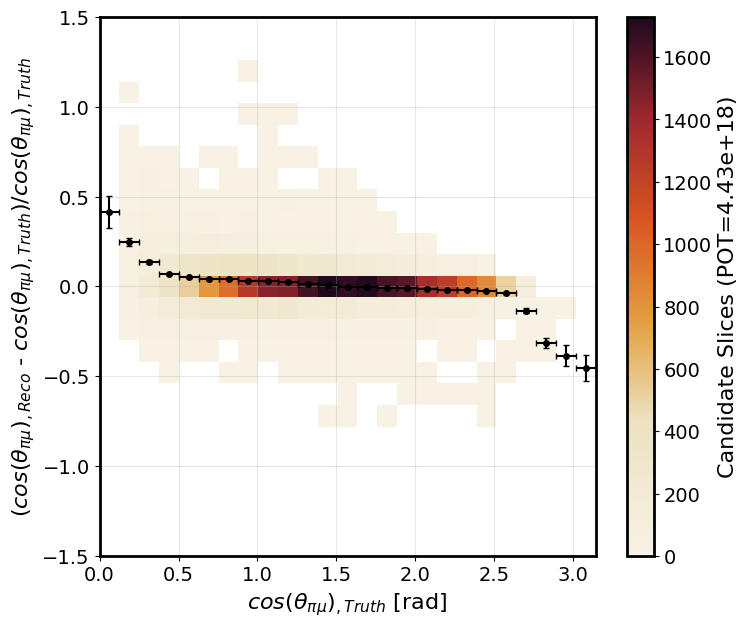

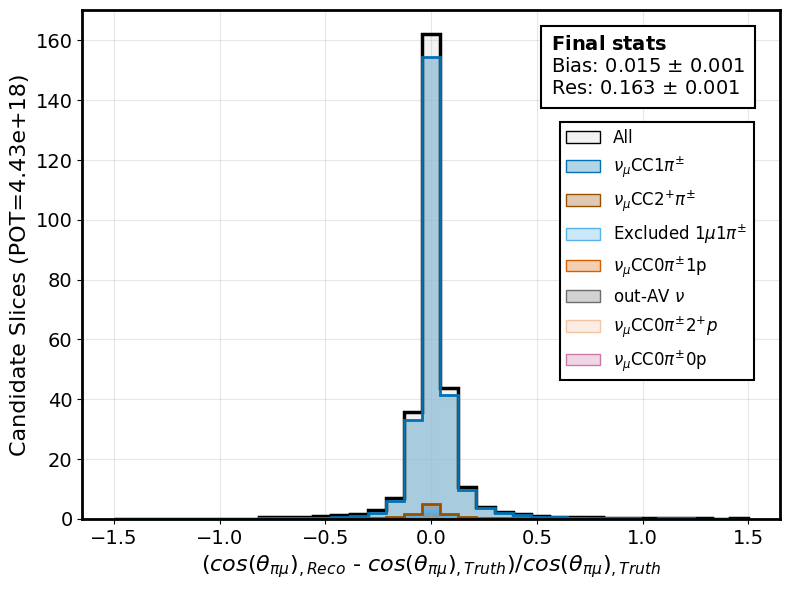

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


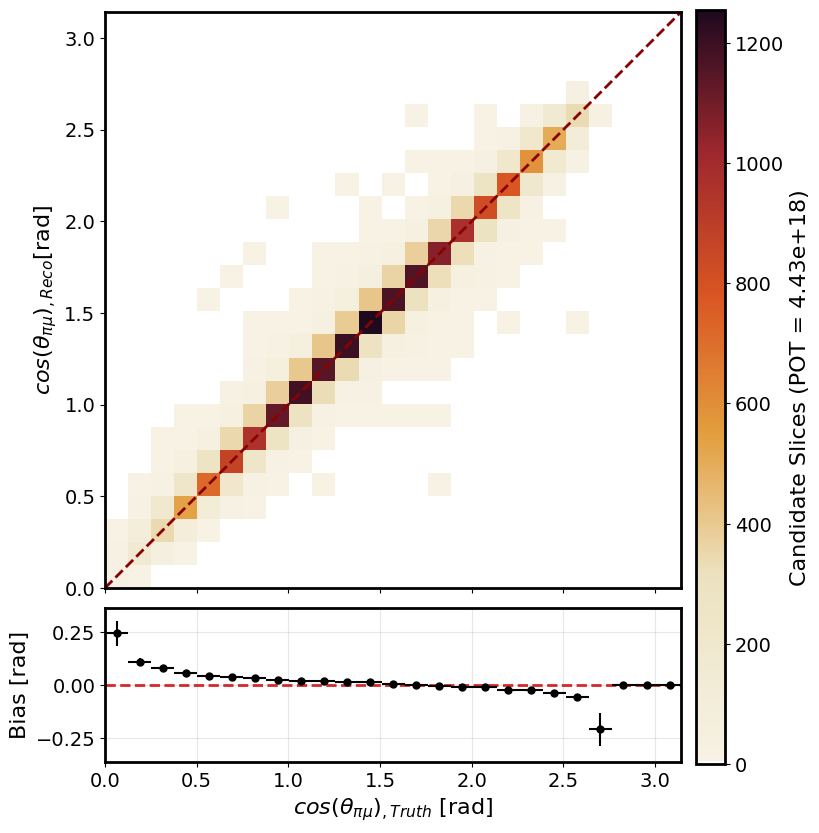

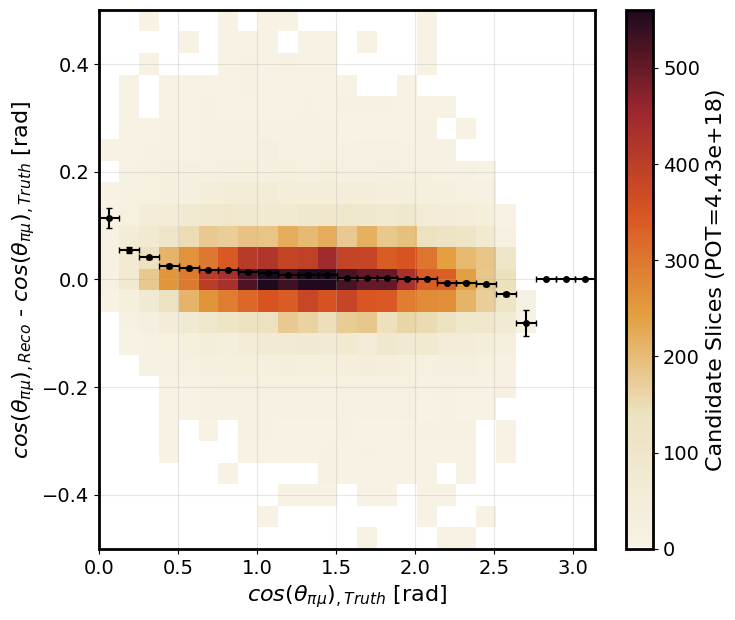

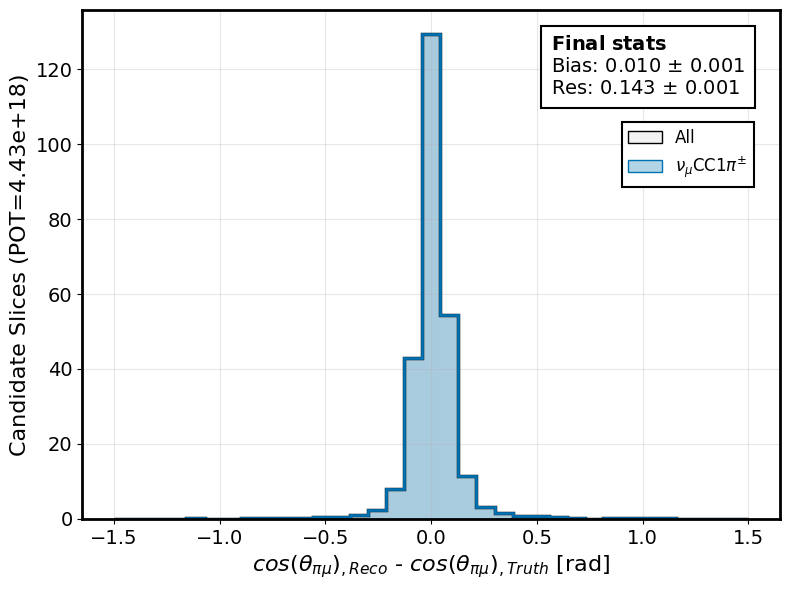

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


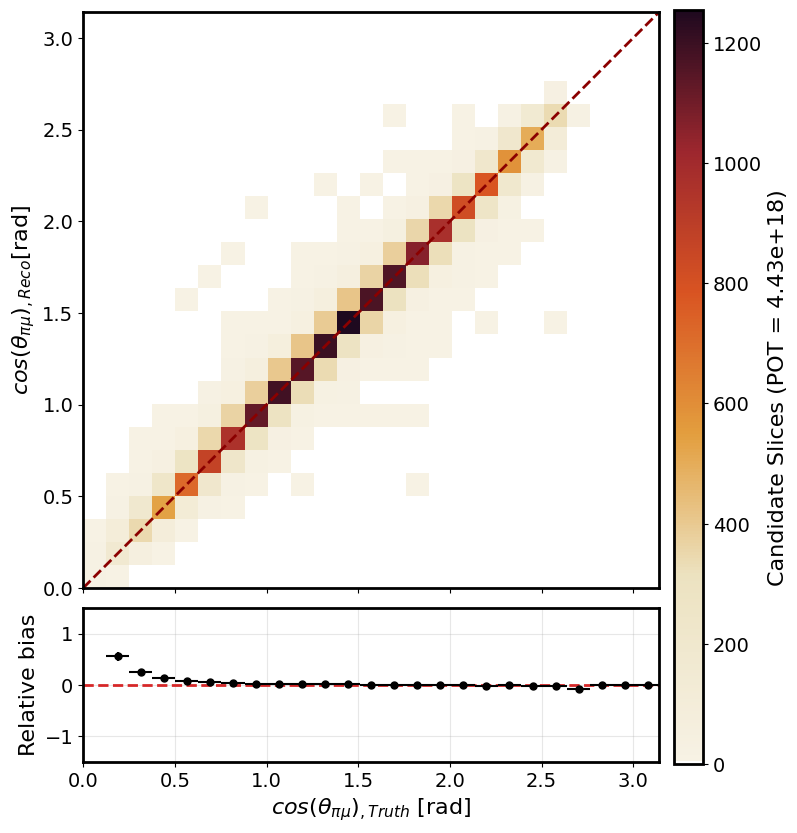

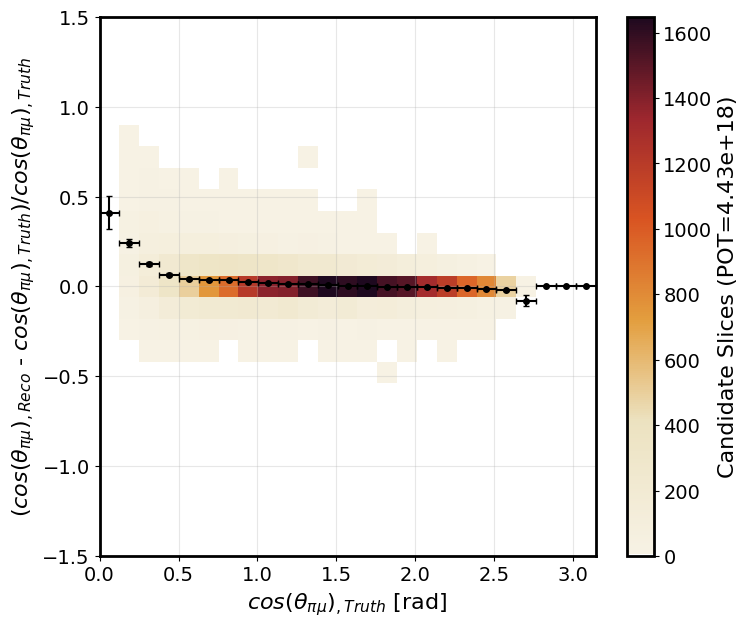

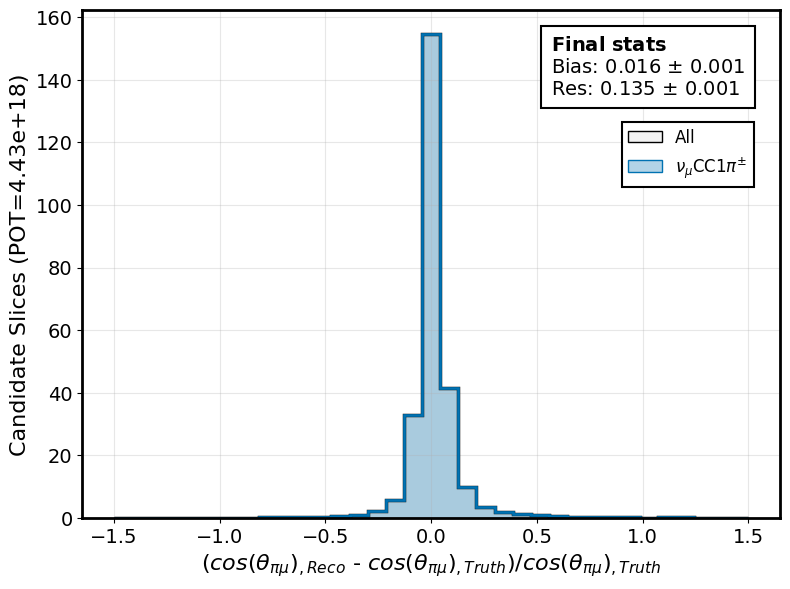

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


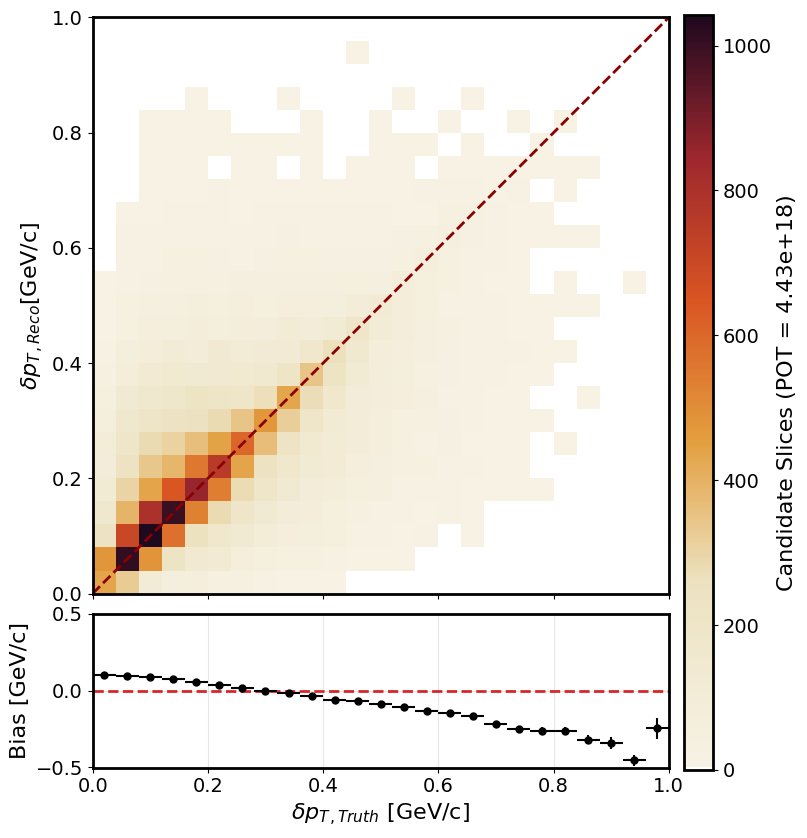

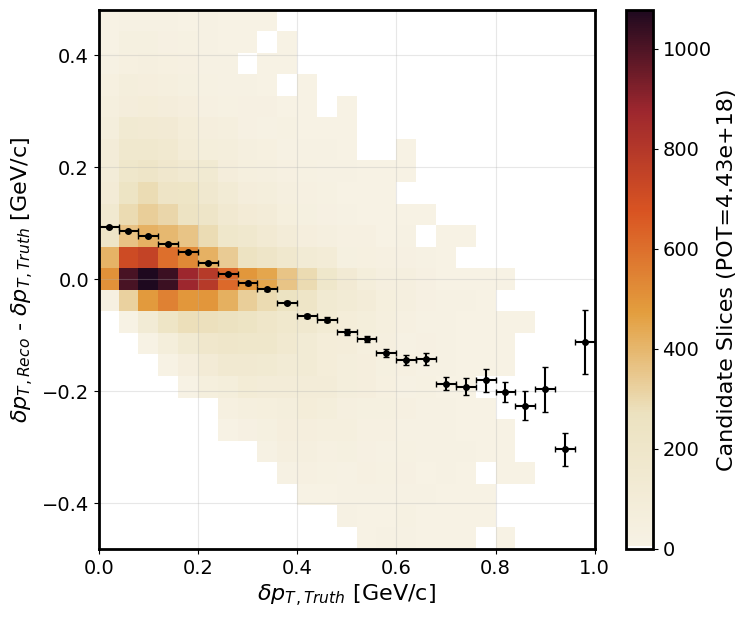

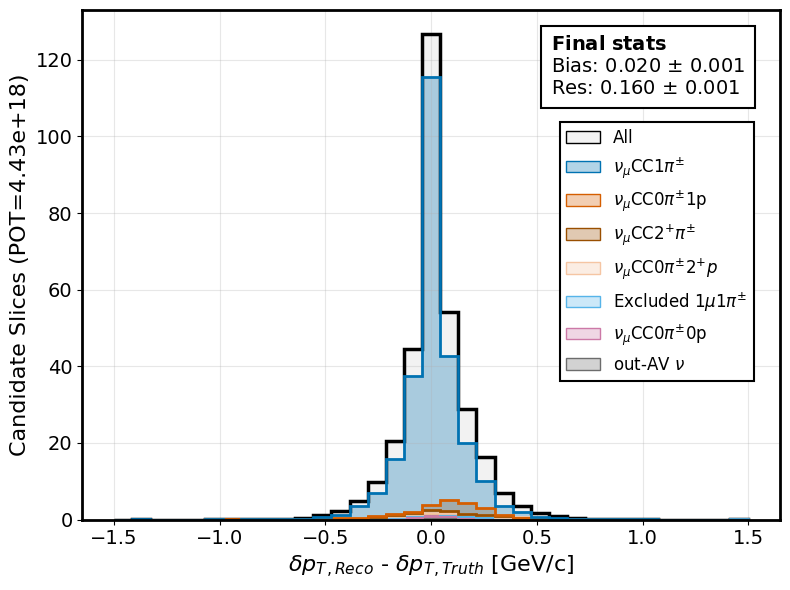

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


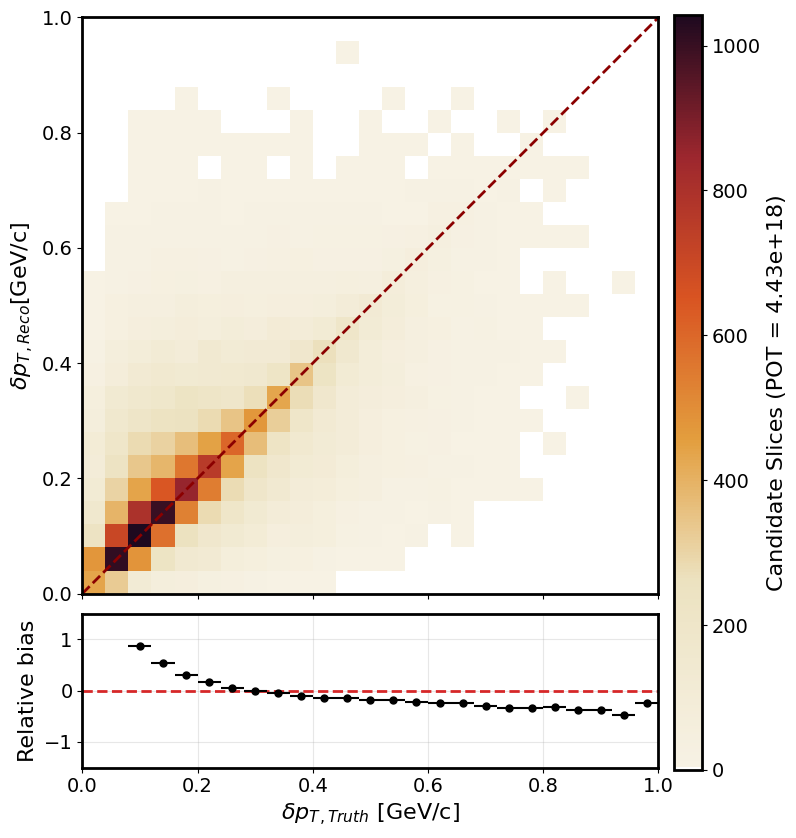

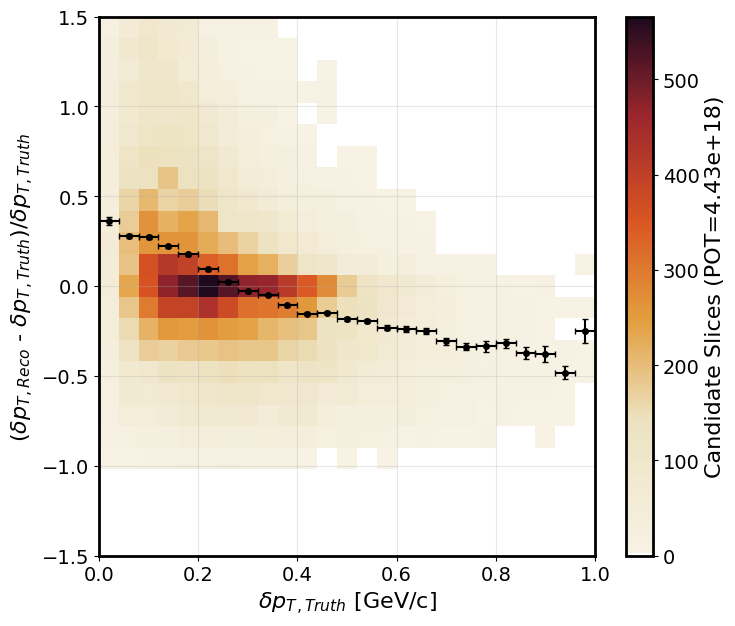

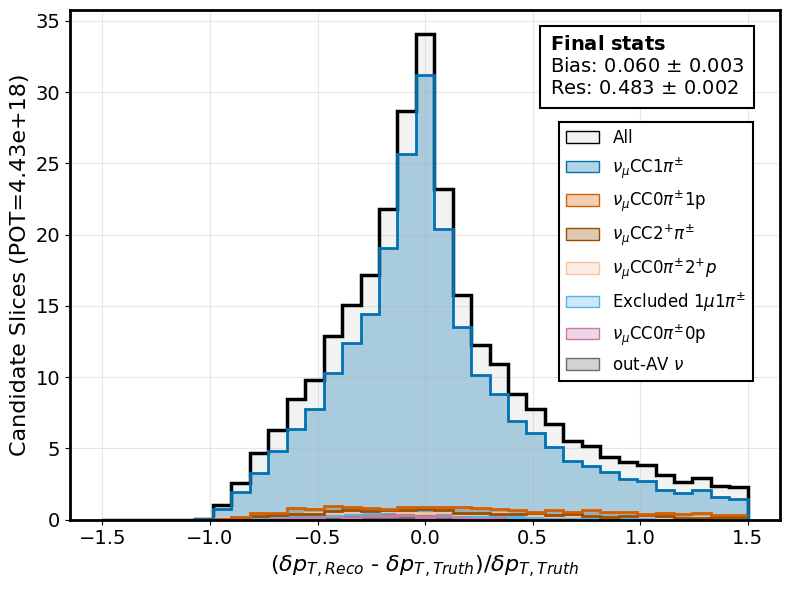

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


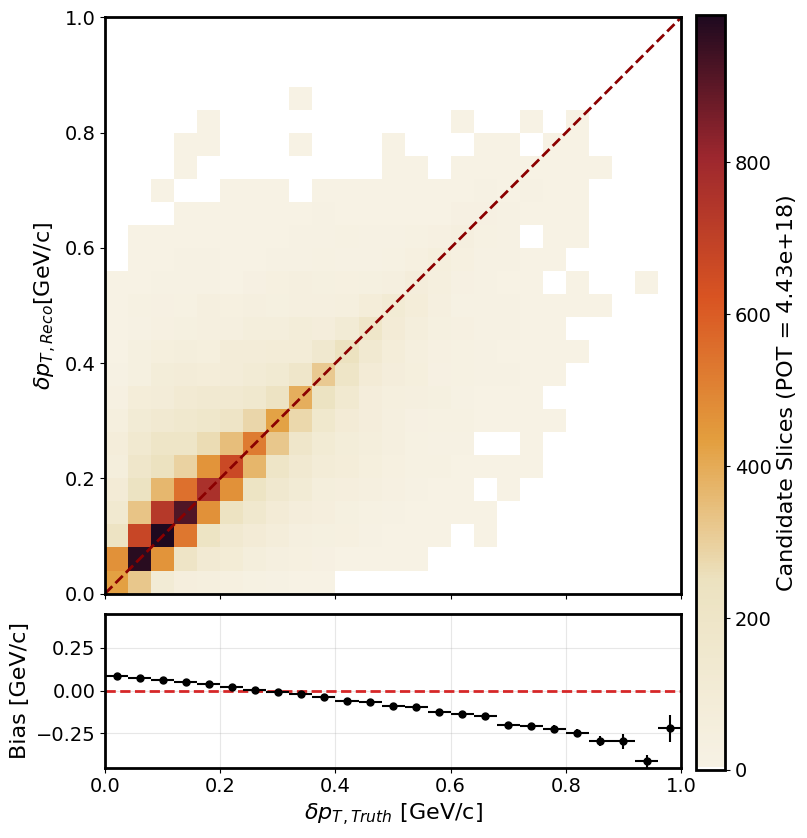

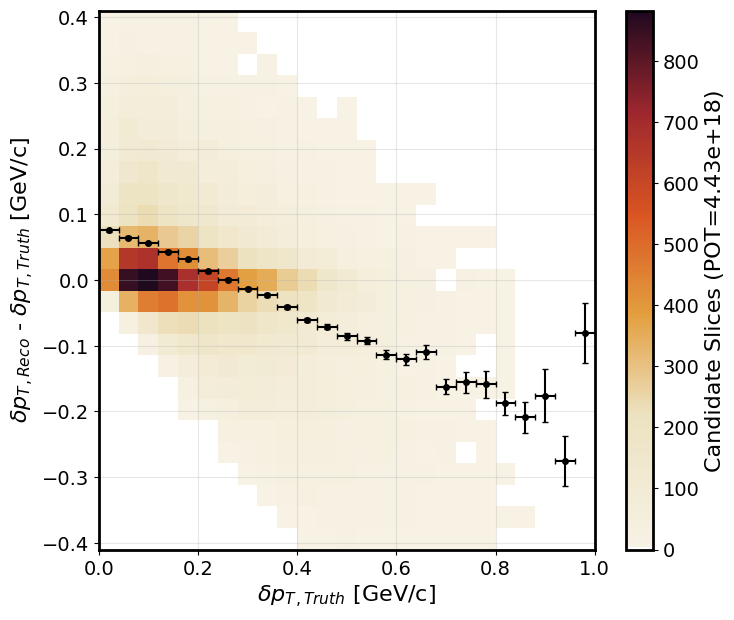

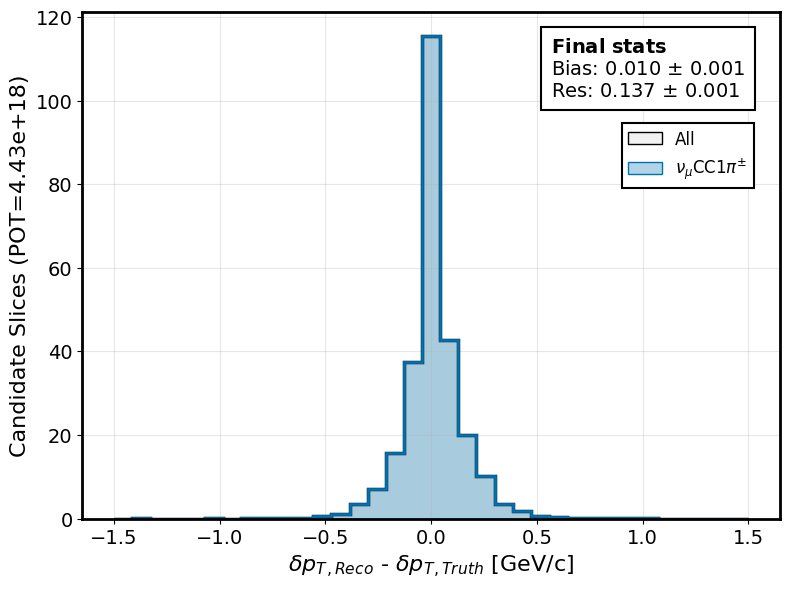

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


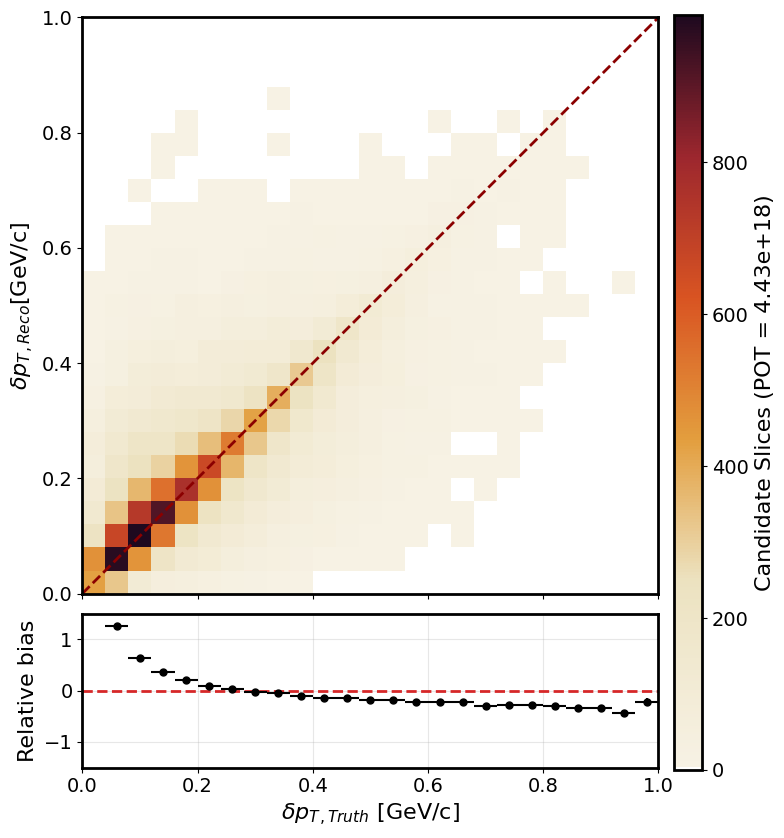

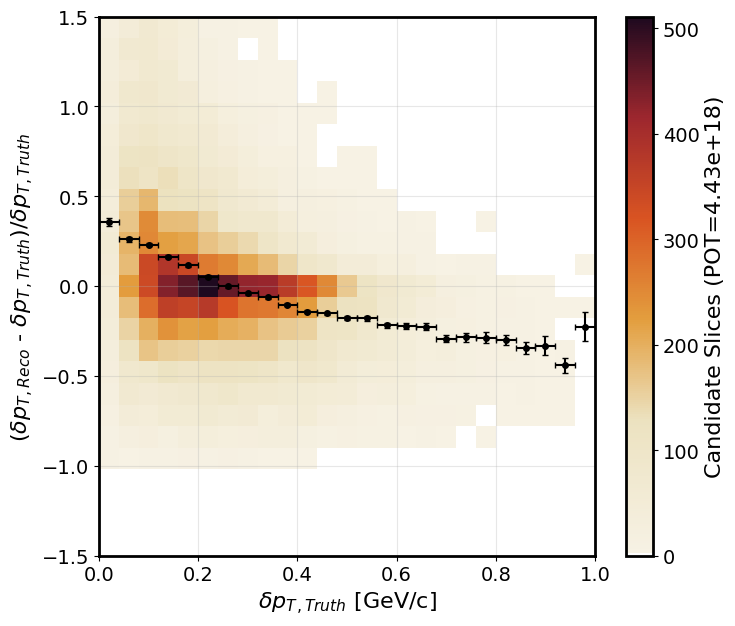

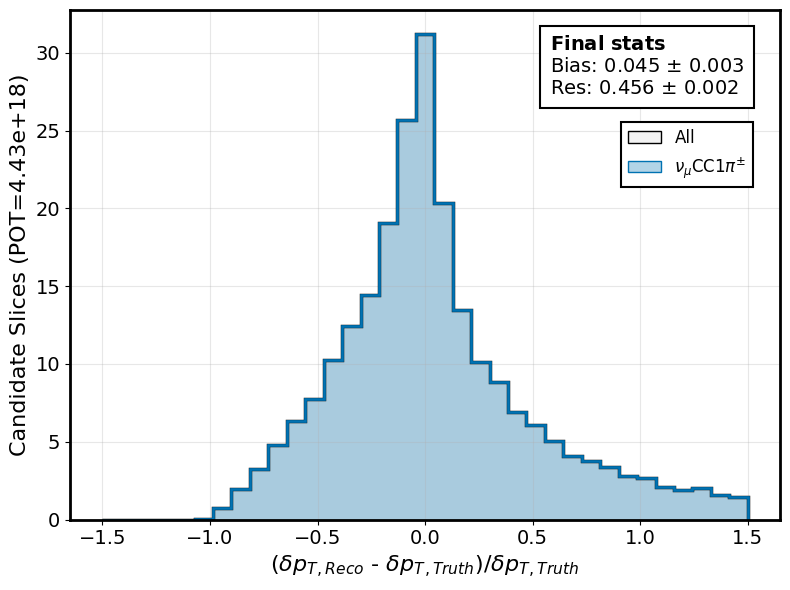

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


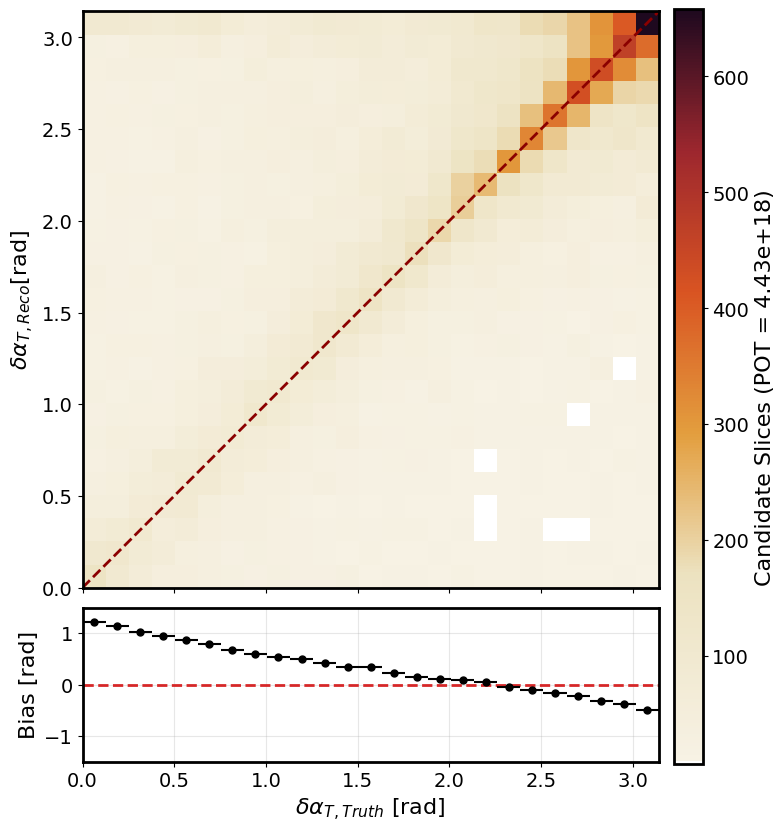

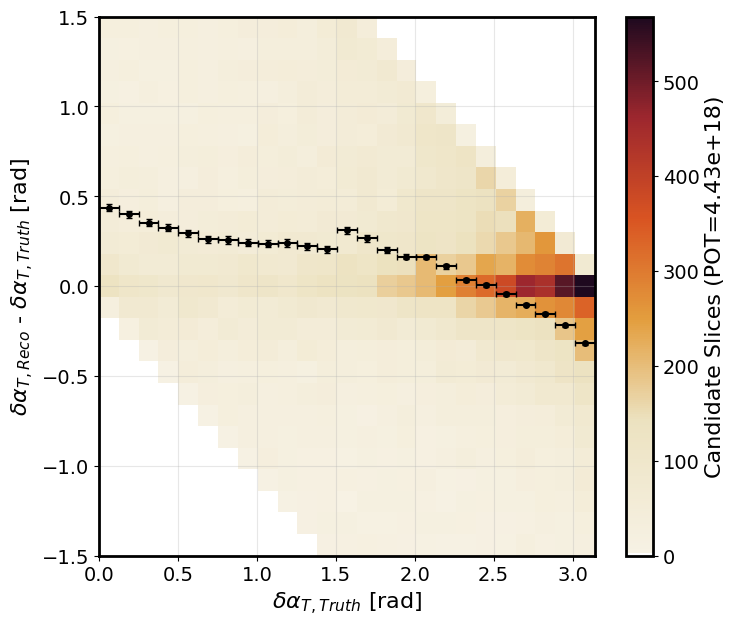

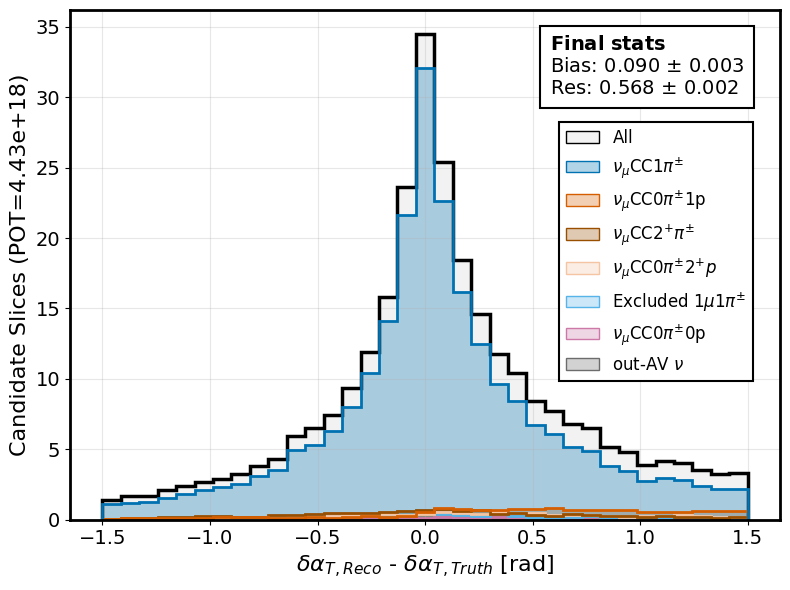

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


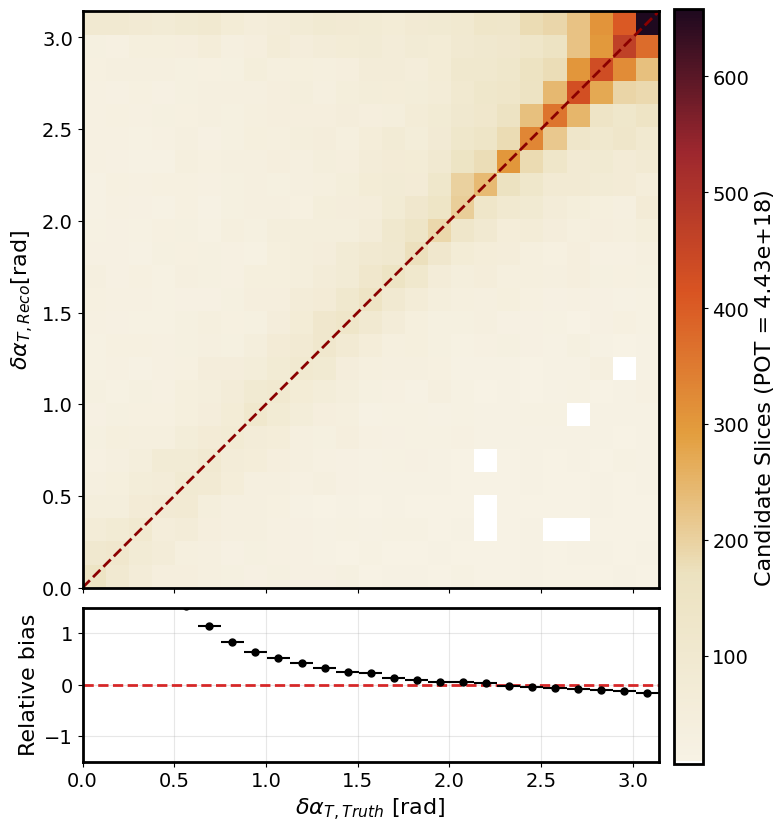

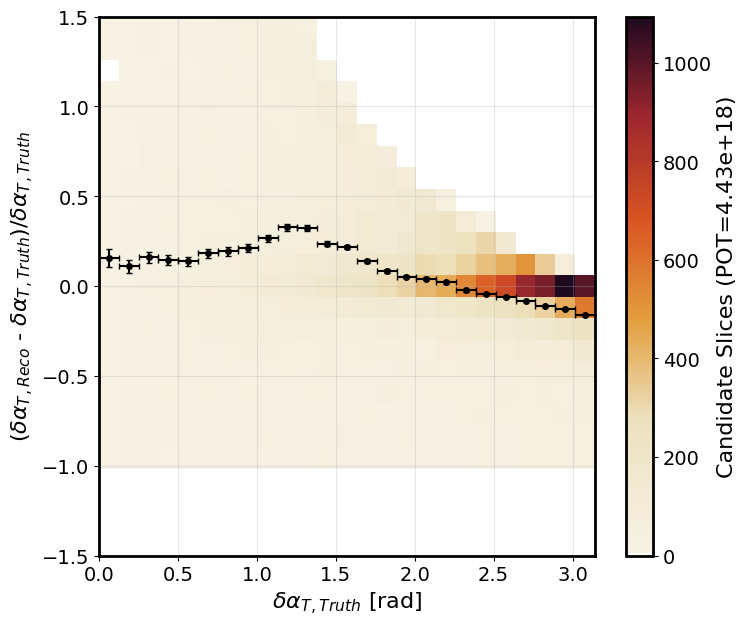

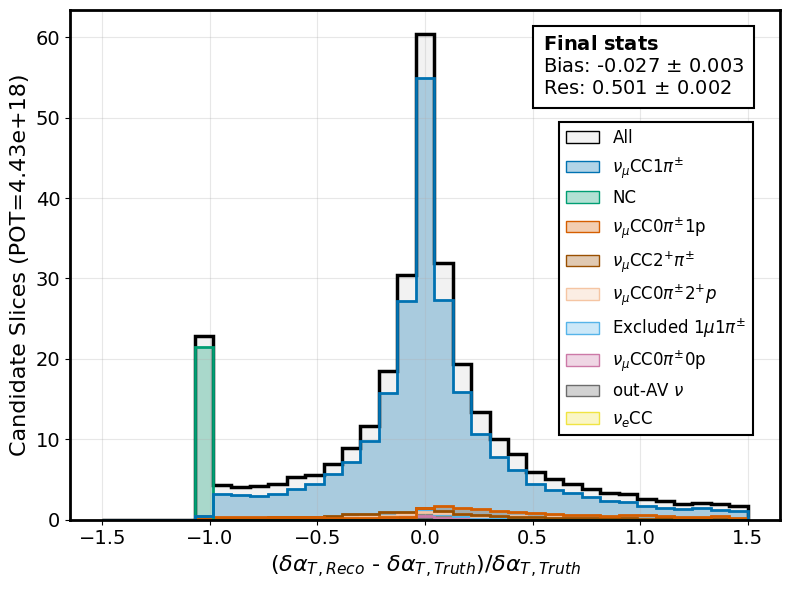

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


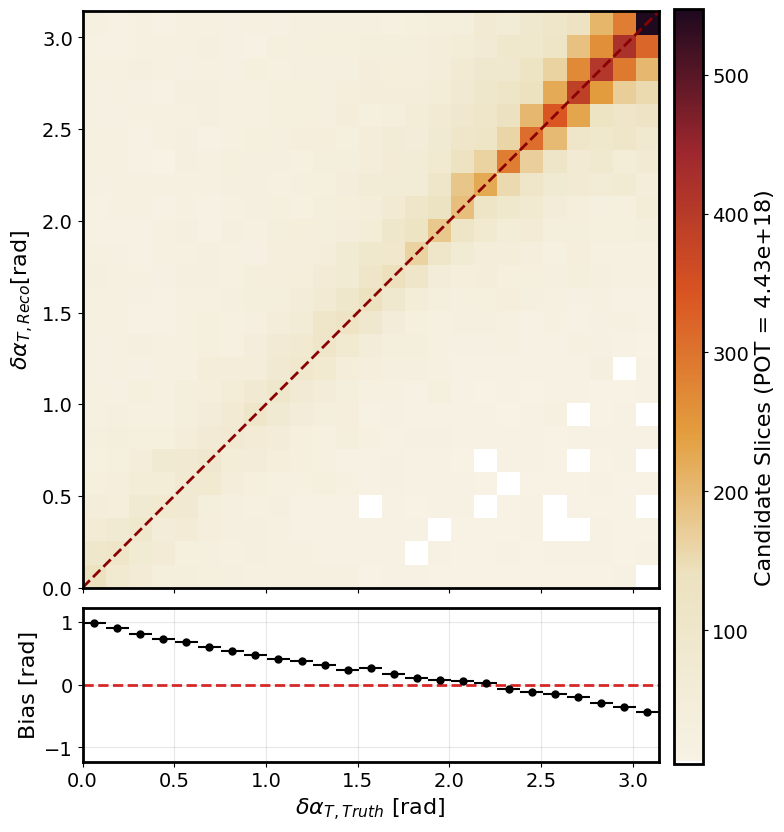

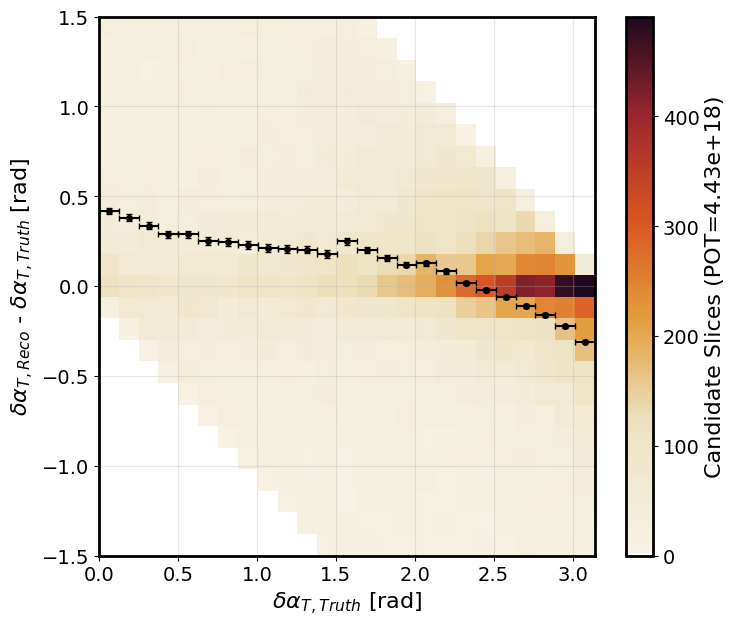

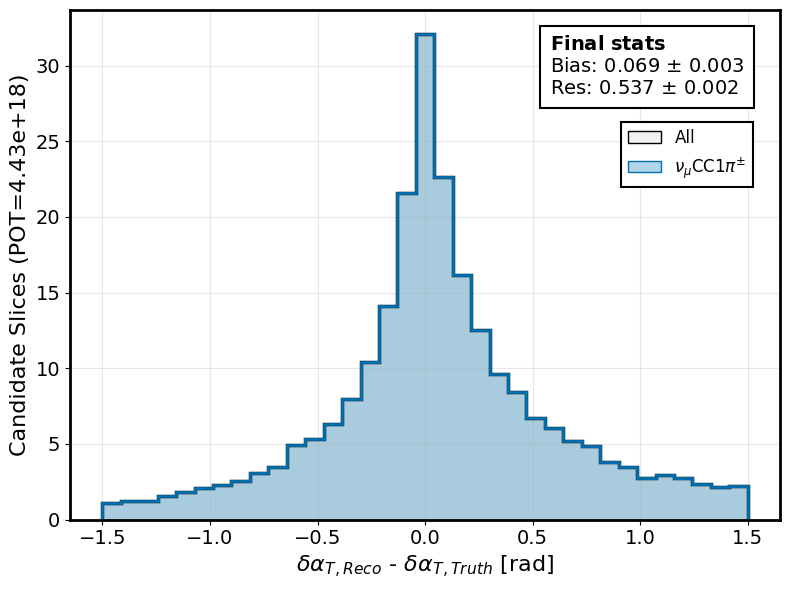

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


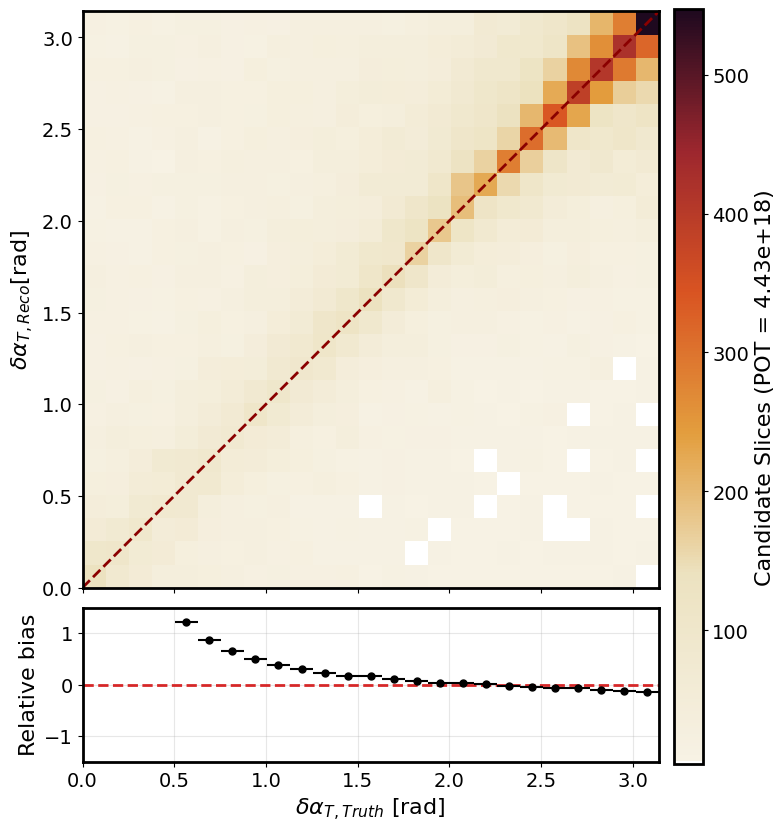

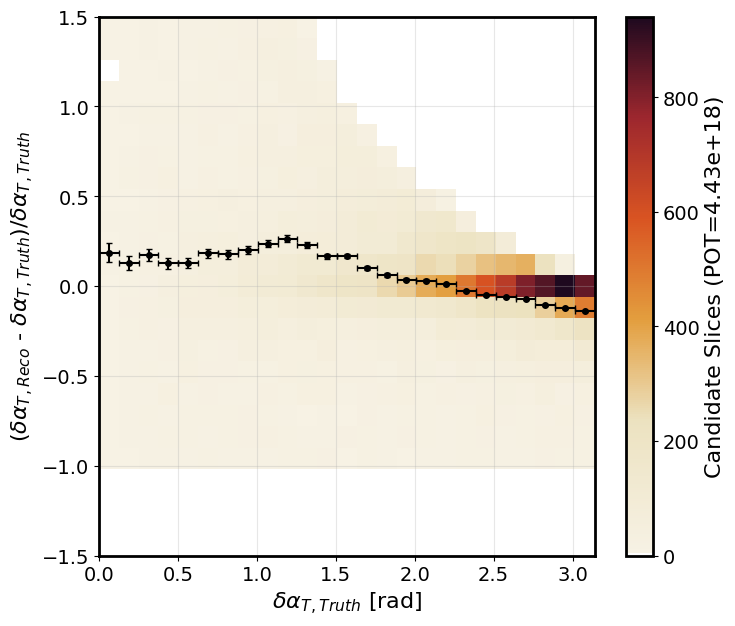

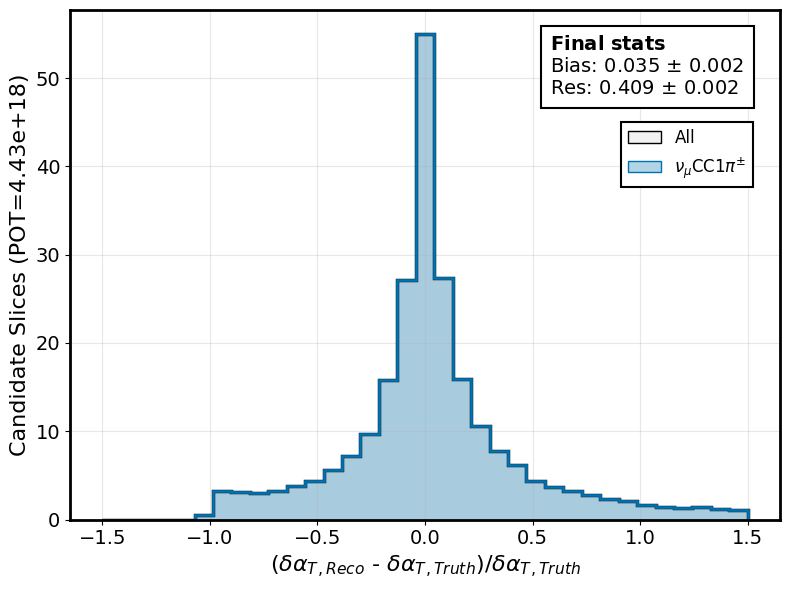

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


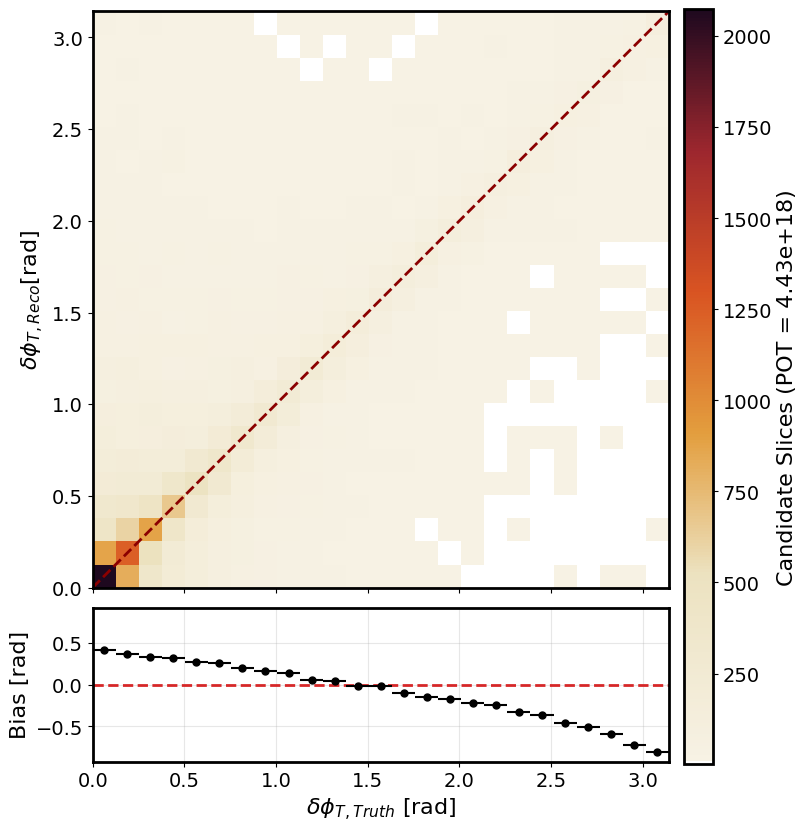

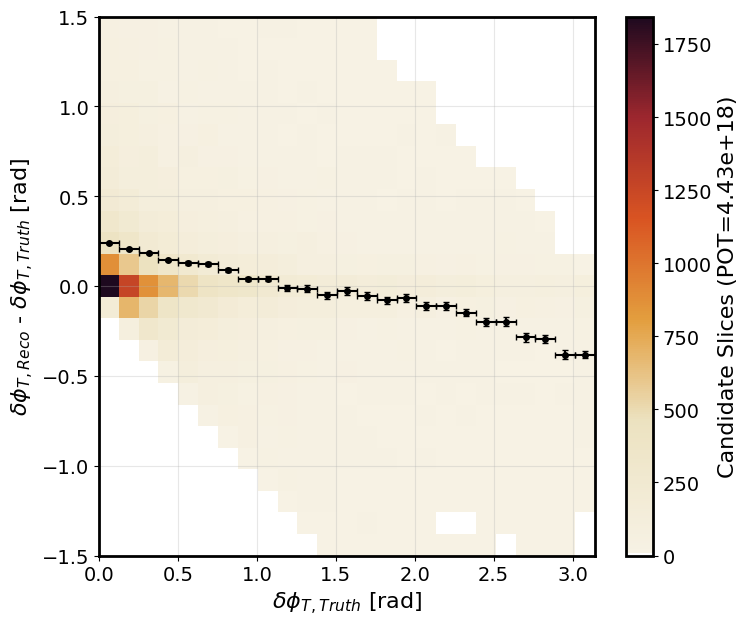

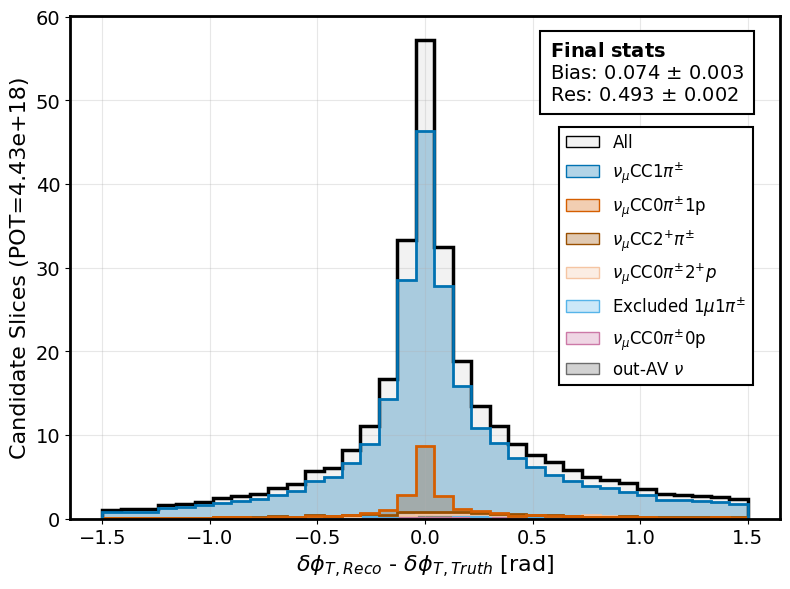

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


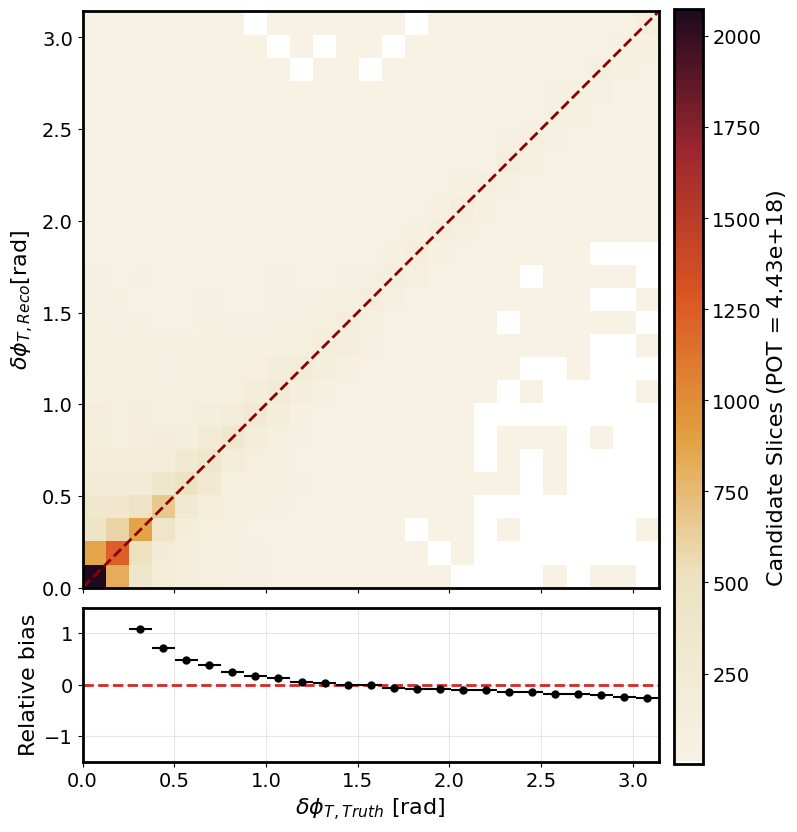

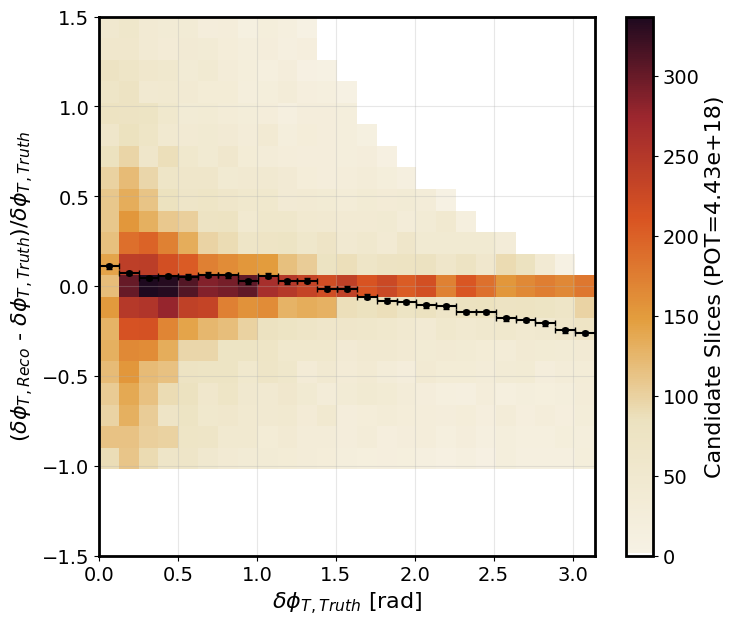

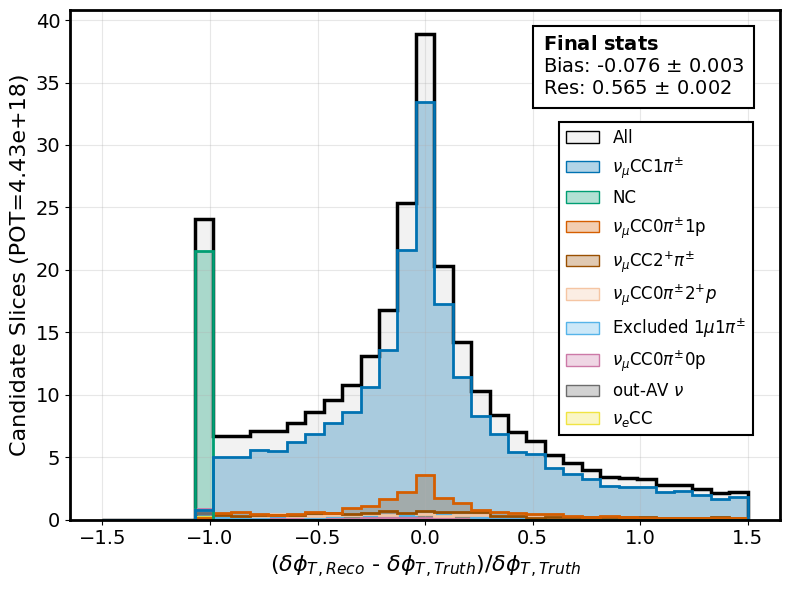

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


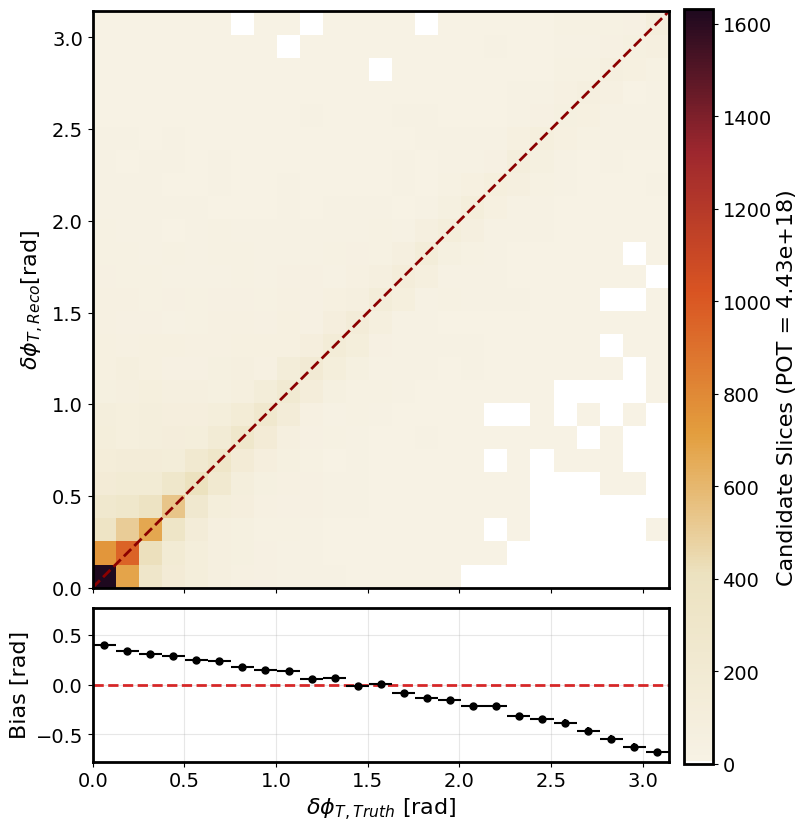

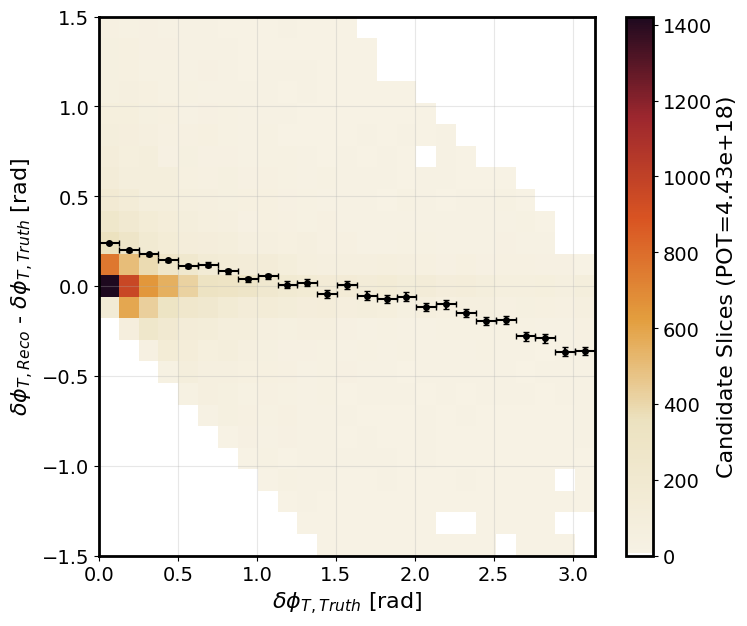

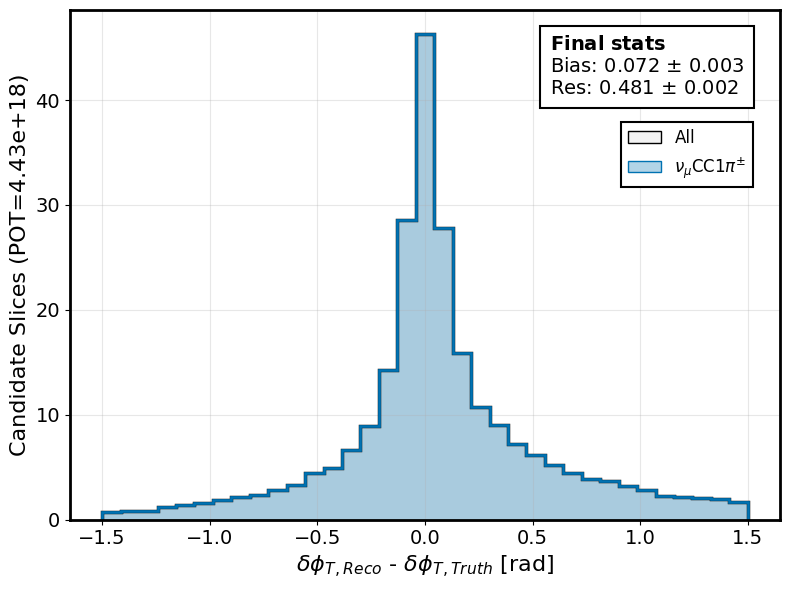

/tmp/ipykernel_11995/1083012061.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df.loc[extra_mask, config.truth_column].values
/tmp/ipykernel_11995/1083012061.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df.loc[extra_mask, config.data_column].values
/tmp/ipykernel_11995/2751754252.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth = df_plot[config.truth_column].values
/tmp/ipykernel_11995/2751754252.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco  = df_plot[config.data_column].values


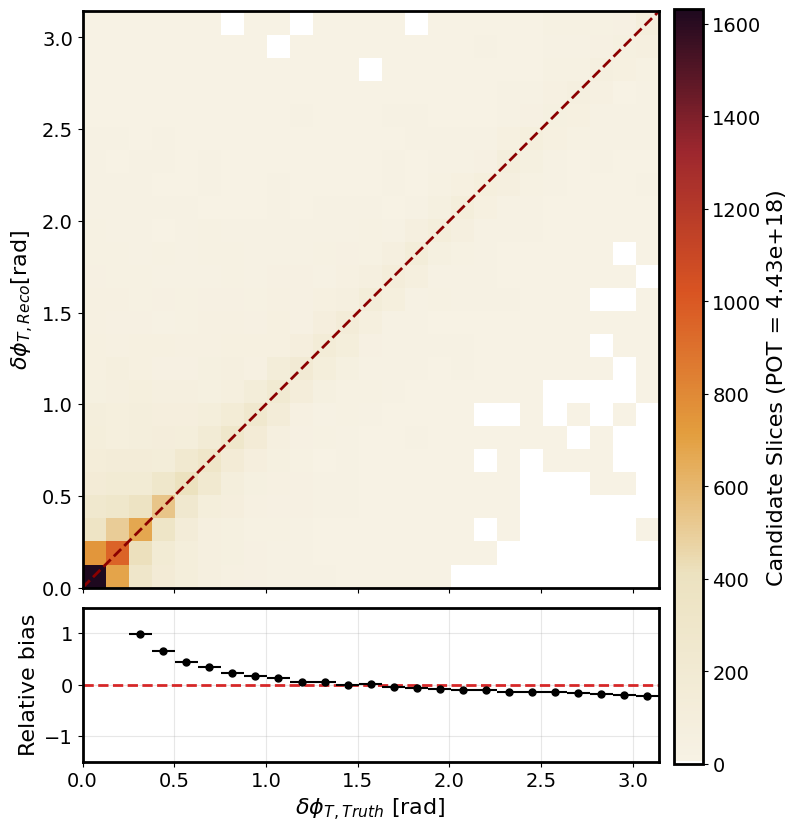

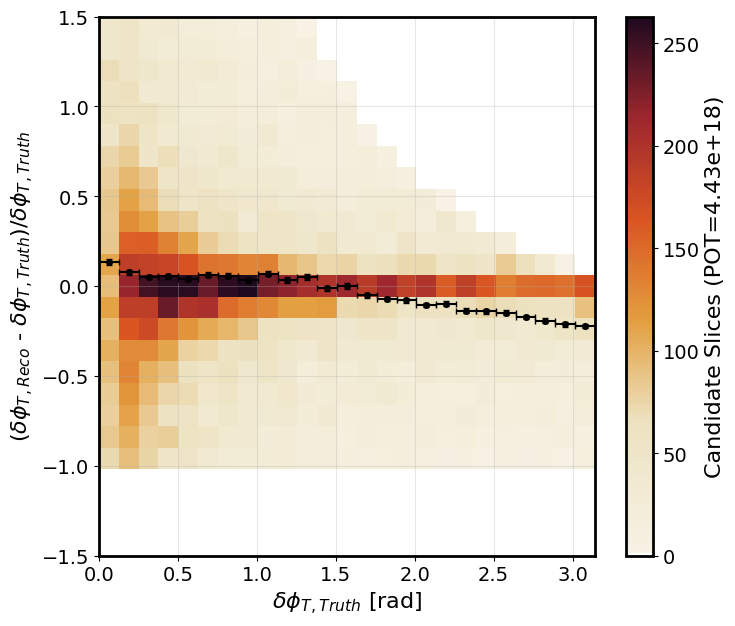

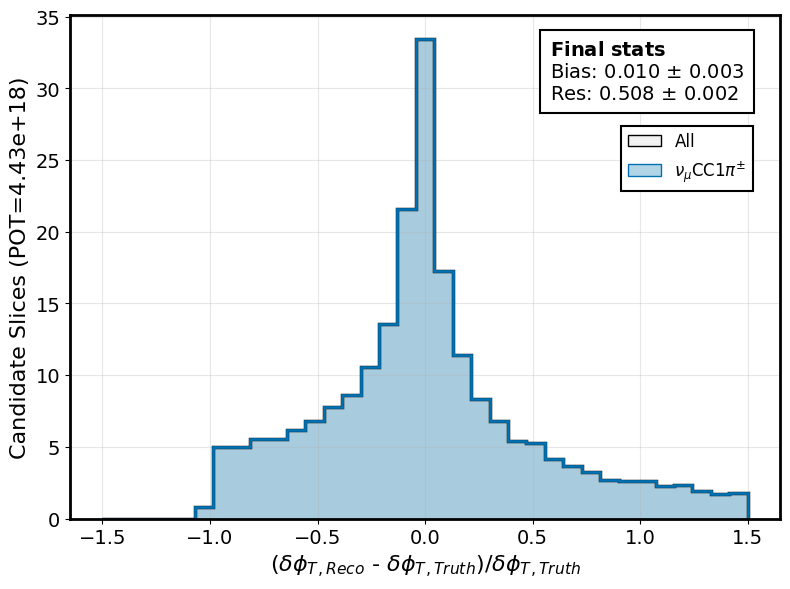

In [11]:
## import os
import shutil
import tarfile
import matplotlib.pyplot as plt


normalize = False
parent_path = "/exp/sbnd/data/users/lpelegri/Graphs/ResolutionGraphs"

chi2_threshold = 5

# --- 1. Cleanup: Remove base folder and old tarball if they exist ---
if os.path.exists(parent_path):
    shutil.rmtree(parent_path)

os.makedirs(parent_path, exist_ok=True)

# Color codes
RED = "\033[31m"
RESET = "\033[0m"

possibilities_dict = {
    "all": [False, False],
    "all_percent": [False, True],
    "pure": [True, False],
    "pure_percent": [True, True]
    }

# Logic for the print statement
# --- 2. Main Loop ---
for config in config_vec:

    for name, possibility in possibilities_dict.items():

        if possibility[0] == True:
            fig_res_2d = plot_resolution(config, mc_evt_df, 
                                         extra_mask = mask_dict[config.extra_mask](mc_evt_df) & mask_dict[config.category_mask](mc_evt_df), 
                                         data_tot_pot=data_tot_pot, 
                                         use_percent_bias=possibility[1])
            fig_bias_2d = plot_bias_2d(config, mc_evt_df, 
                                       extra_mask = mask_dict[config.extra_mask](mc_evt_df) & mask_dict[config.category_mask](mc_evt_df), 
                                       use_percent_bias=possibility[1], 
                                       data_tot_pot=data_tot_pot)
            fig_bias_1d = plot_1d_res(
                        mc_df = mc_evt_df,
                        config = config,
                        title = config.title,
                        weight_column = ('slc', 'wgt', '', '', '', ''),
                        use_percent_bias = possibility[1],
                        extra_mask = mask_dict[config.extra_mask](mc_evt_df) & mask_dict[config.category_mask](mc_evt_df),
                        data_tot_pot = data_tot_pot
                    )
        else: 
            fig_res_2d = plot_resolution(config, mc_evt_df, 
                                         extra_mask = mask_dict[config.extra_mask](mc_evt_df), 
                                         data_tot_pot=data_tot_pot, 
                                         use_percent_bias=possibility[1])
            fig_bias_2d = plot_bias_2d(config, mc_evt_df, 
                                       extra_mask = mask_dict[config.extra_mask](mc_evt_df), 
                                       use_percent_bias=possibility[1], 
                                       data_tot_pot=data_tot_pot)
            fig_bias_1d = plot_1d_res(
                        mc_df = mc_evt_df,
                        config = config,
                        title = config.title,
                        weight_column = ('slc', 'wgt', '', '', '', ''),
                        use_percent_bias = possibility[1],
                        extra_mask = mask_dict[config.extra_mask](mc_evt_df),
                    data_tot_pot = data_tot_pot
                    )
            
        target_dir = os.path.join(parent_path , config.file_name)
        os.makedirs(target_dir, exist_ok=True)

        # Unique filename per cut: e.g., "cut_FV_muon_energy.pdf"
        save_name_1d = f"res_1d_{name}_{config.file_name}.pdf"
        save_name_bias_2d = f"bias_2d_{name}_{config.file_name}.pdf"
        save_name_res_2d = f"res_2d_{name}_{config.file_name}.pdf"
        save_path_1d = os.path.join(target_dir, save_name_1d)
        save_path_bias_2d = os.path.join(target_dir, save_name_bias_2d)
        save_path_res_2d = os.path.join(target_dir, save_name_res_2d)
        
        fig_res_2d.savefig(save_path_res_2d, format='pdf', bbox_inches='tight') 
        fig_bias_2d.savefig(save_path_bias_2d, format='pdf', bbox_inches='tight') 
        fig_bias_1d.savefig(save_path_1d, format='pdf', bbox_inches='tight') 
        
        plt.close(fig_res_2d)
        plt.close(fig_bias_2d)
        plt.close(fig_bias_1d)

In [12]:
'''
#Only use CV as the other samples do not contrinute at the end
keys2load = ["cc1pi", "hdr", "histpotdf", "nudf"] ## keys from the configuration file
bnb_path = "/exp/sbnd/data/users/lpelegri/cafpyana_data/mc_ar23p_extended_syst_pruned.df"
mc_bnb_df = load_df(bnb_path, keys2load, 100)
mc_bnb_evt_df = mc_bnb_df['cc1pi']
mc_bnb_nu_df = mc_bnb_df['nudf']
mc_bnb_hdr_df = mc_bnb_df['hdr']
cols_to_keep = [
    ('nu_categ', '', '', ''),
    ('genie_categ', '', '', ''),
    ('genie_mode', '', '', ''),
    ('nu_categ_proton_reduced', '', '', ''),
    ('true_var','true_cos_theta_mu', '',''),
    ('true_var','true_cos_theta_pi', '',''),
    ('true_var','true_mu_pi_angle', '',''),
    ('true_var','true_p_mu', '',''),
    ('true_var','true_p_pi', '',''),
    ('true_var','num_protons', '',''),
    ('true_var','delta_pT', '',''),
    ('true_var','delta_alpha_T', '',''),
    ('true_var','delta_phi_T', '','')
]
mc_bnb_nu_df = mc_bnb_nu_df[cols_to_keep]

mc_bnb_evt_df = mc_bnb_evt_df[build_event_cumulative_masks(mc_bnb_evt_df, sideband = "")["energy"]]
cols_to_keep = [
        ('slc', 'self', '', '', '', ''),
        ('slc', 'tmatch', 'idx', '', '', ''),
        ('slc', 'nu_score', '', '', '', ''),
        ('slc', 'cut', 'obvious_cosmic', '', '', ''),
        ('slc', 'cut', 't0', '', '', ''),
        ('slc', 'cut', 'inside_FV', '', '', ''),
        ('slc', 'cut', 'nu_score', '', '', ''),
        ('slc', 'cut', 'track', '', '', ''),
        ('slc', 'cut', 'shower', '', '', ''),
        ('slc', 'cut', 'MIP_candidates', '', '', ''),
        ('slc', 'cut', 'angle', '', '', ''),
        ('slc', 'cut', 'proton_BDT', '', '', ''),
        ('slc', 'cut', 'proton_BDT_sideband', '', '', ''),
        ('slc', 'cut', 'containment', '', '', ''),
        ('slc', 'cut', 'michel', '', '', ''),
        ('slc', 'cut', 'extra_pion', '', '', ''),
        ('slc','cut','energy','','',''),
        ('slc','cut_var','n_MIP_candidates','','',''),
        ('slc', 'measure_var', 'angle_between_candidates', '', '', ''),
        ('slc', 'measure_var', 'num_protons', '', '', ''),
        ('slc','measure_var','reco_p_mu','','',''),
        ('slc','measure_var','reco_cos_theta_mu','','',''),
        ('slc','measure_var','TLE_p_pi','','',''),
        ('slc','measure_var','range_p_pi','','',''),
        ('slc','measure_var','reco_cos_theta_pi','','',''), 
        ('slc','measure_var','delta_pT','','',''),
        ('slc','measure_var','delta_alpha_T','','',''),
        ('slc','measure_var','delta_phi_T','','',''),
        ('slc','measure_var','mu_true_p_type','','',''),
        ('slc','measure_var','pi_true_p_type','','',''),
        ('slc','measure_var','mu_true_pdg','','',''),
        ('slc','measure_var','pi_true_pdg','','',''),
        ('slc','measure_var','pi_true_p','','',''),
        ('slc','measure_var','mu_true_p','','',''),
        ('slc','measure_var','pi_true_costheta','','',''),
        ('slc','measure_var','mu_true_costheta','','',''),
        ('slc','measure_var','muon_contained','','',''),
]
mc_bnb_evt_df = mc_bnb_evt_df[cols_to_keep]

mc_bnb_evt_df = (
        mc_bnb_evt_df
        .groupby(['__ntuple', 'entry', 'rec.slc..index'])
        .first()
    )
mc_bnb_evt_df = mc_bnb_evt_df.sort_index()
'''

'\n#Only use CV as the other samples do not contrinute at the end\nkeys2load = ["cc1pi", "hdr", "histpotdf", "nudf"] ## keys from the configuration file\nbnb_path = "/exp/sbnd/data/users/lpelegri/cafpyana_data/mc_ar23p_extended_syst_pruned.df"\nmc_bnb_df = load_df(bnb_path, keys2load, 100)\nmc_bnb_evt_df = mc_bnb_df[\'cc1pi\']\nmc_bnb_nu_df = mc_bnb_df[\'nudf\']\nmc_bnb_hdr_df = mc_bnb_df[\'hdr\']\ncols_to_keep = [\n    (\'nu_categ\', \'\', \'\', \'\'),\n    (\'genie_categ\', \'\', \'\', \'\'),\n    (\'genie_mode\', \'\', \'\', \'\'),\n    (\'nu_categ_proton_reduced\', \'\', \'\', \'\'),\n    (\'true_var\',\'true_cos_theta_mu\', \'\',\'\'),\n    (\'true_var\',\'true_cos_theta_pi\', \'\',\'\'),\n    (\'true_var\',\'true_mu_pi_angle\', \'\',\'\'),\n    (\'true_var\',\'true_p_mu\', \'\',\'\'),\n    (\'true_var\',\'true_p_pi\', \'\',\'\'),\n    (\'true_var\',\'num_protons\', \'\',\'\'),\n    (\'true_var\',\'delta_pT\', \'\',\'\'),\n    (\'true_var\',\'delta_alpha_T\', \'\',\'\'),\n    (\'t

In [13]:
'''
def InFV_strict(df):
    xmax = 190.
    zmin = 10.
    zmax = 450.
    ymax_highz = 100.
    pass_xz = (np.abs(df.slc.vertex.x) < xmax) & (df.slc.vertex.z > zmin) & (df.slc.vertex.z < zmax)
    pass_y = ((df.slc.vertex.z < 250) & (np.abs(df.slc.vertex.y) < 190.)) | ((df.slc.vertex.z > 250) & (df.slc.vertex.y > -190.) & (df.slc.vertex.y < ymax_highz))
    return pass_xz & pass_y
'''

'\ndef InFV_strict(df):\n    xmax = 190.\n    zmin = 10.\n    zmax = 450.\n    ymax_highz = 100.\n    pass_xz = (np.abs(df.slc.vertex.x) < xmax) & (df.slc.vertex.z > zmin) & (df.slc.vertex.z < zmax)\n    pass_y = ((df.slc.vertex.z < 250) & (np.abs(df.slc.vertex.y) < 190.)) | ((df.slc.vertex.z > 250) & (df.slc.vertex.y > -190.) & (df.slc.vertex.y < ymax_highz))\n    return pass_xz & pass_y\n'

In [14]:
'''
def build_event_cumulative_masks(evt_df, sideband = ""):
    # Define which BDT mask to use
    
    cut_sequence = [
        ("cosmic",      evt_df.slc.cut.obvious_cosmic),
        ("t0",          evt_df.slc.cut.t0),
        ("FV",          InFV_strict(evt_df)),
        ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),
        ("track",       evt_df.slc.cut.track),
        ("chi2",        evt_df.slc.cut.MIP_candidates),
        ("shower",      evt_df.slc.cut.shower),
        ("angle",       evt_df.slc.cut.angle),
        ("proton_BDT",  evt_df.slc.cut.proton_BDT),
        #("containment", evt_df.slc.cut.containment),
        ("containment", evt_df.slc.cut.containment),
        #("TPC_containment",  TPC_containment_mask(evt_df,group_levels)),
        ("michel",      evt_df.slc.cut.michel),
        ("extra_pion",  evt_df.slc.cut.extra_pion),
        ("energy",      evt_df.slc.cut.energy),
    ]
    
    # 2️⃣ Build cumulative masks
    cumulative_masks = {}
    current_mask = None

    for name, mask in cut_sequence:

        if current_mask is None:
            current_mask = mask.copy()
        else:
            current_mask = current_mask & mask

        cumulative_masks[name] = current_mask.copy()

    return cumulative_masks
'''

'\ndef build_event_cumulative_masks(evt_df, sideband = ""):\n    # Define which BDT mask to use\n    \n    cut_sequence = [\n        ("cosmic",      evt_df.slc.cut.obvious_cosmic),\n        ("t0",          evt_df.slc.cut.t0),\n        ("FV",          InFV_strict(evt_df)),\n        ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),\n        ("track",       evt_df.slc.cut.track),\n        ("chi2",        evt_df.slc.cut.MIP_candidates),\n        ("shower",      evt_df.slc.cut.shower),\n        ("angle",       evt_df.slc.cut.angle),\n        ("proton_BDT",  evt_df.slc.cut.proton_BDT),\n        #("containment", evt_df.slc.cut.containment),\n        ("containment", evt_df.slc.cut.containment),\n        #("TPC_containment",  TPC_containment_mask(evt_df,group_levels)),\n        ("michel",      evt_df.slc.cut.michel),\n        ("extra_pion",  evt_df.slc.cut.extra_pion),\n        ("energy",      evt_df.slc.cut.energy),\n    ]\n    \n    # 2️⃣ Build cumulative masks\n    cumulative_masks = 

In [15]:
def plot_1d_res_pion(
    mc_df,
    config,
    title=None,
    weight_column=None,
    use_percent_bias=False,
    extra_mask=None,
    data_tot_pot=None
):
    # --- 1. Pre-processing ---
    slice_levels = ['__ntuple', 'entry', 'rec.slc..index']
    if getattr(config, "first_per_slice", False):
        mc_df = mc_df.groupby(level=slice_levels, sort=False).first()

    if extra_mask is None:
        extra_mask = np.ones(len(mc_df), dtype=bool)

    df_plot = mc_df.loc[extra_mask].copy()

    # Handle weights
    if weight_column is not None and weight_column in df_plot.columns:
        df_plot['plot_w'] = df_plot[weight_column].values
    else:
        df_plot['plot_w'] = np.ones(len(df_plot))

    truth      = df_plot[config.truth_column].values
    reco_tle   = df_plot[config.data_column].values
    range_col  = ('slc', 'measure_var', 'range_p_pi', '', '', '')
    reco_range = df_plot[range_col].values if range_col in df_plot.columns else None

    def residual(reco, truth):
        return (reco - truth) / truth if use_percent_bias else (reco - truth)

    x_tle   = residual(reco_tle,   truth)
    x_range = residual(reco_range, truth) if reco_range is not None else None

    range_filter = (x_tle > -1.5) & (x_tle < 1.5)
    df_plot = df_plot.loc[range_filter].copy()
    df_plot['x_tle'] = x_tle[range_filter]
    if x_range is not None:
        df_plot['x_range'] = x_range[range_filter]

    pion_type      = df_plot[config.plot_column]
    stopping_mask  = pion_type == 'stopping pion'
    inelastic_mask = pion_type == 'inelastic pion'

    bins = np.linspace(-1, 1, 36)

    COL_INEL  = "#009E73" # 3. Bluish Green
    COL_STOP  = "#D55E00"  # 6. Vermilion
    COL_RANGE ="#6C6C6C"  # 10. Mid Gray ← new  

    # --- 2. Area-normalize weights per histogram ---
    w = df_plot['plot_w'].values

    def norm_weights(vals, wgts):
        valid    = ~np.isnan(vals)
        in_range = valid & (vals >= bins[0]) & (vals <= bins[-1])
        total    = wgts[in_range].sum()
        return wgts / total if total > 0 else wgts

    w_stop_tle   = norm_weights(df_plot.loc[stopping_mask,  'x_tle'].values, w[stopping_mask.values])
    w_inel_tle   = norm_weights(df_plot.loc[inelastic_mask, 'x_tle'].values, w[inelastic_mask.values])
    w_inel_range = None
    if 'x_range' in df_plot.columns:
        w_inel_range = norm_weights(df_plot.loc[inelastic_mask, 'x_range'].values, w[inelastic_mask.values])

    # --- 3. Plot histograms ---
    fig, ax = plt.subplots(figsize=(9, 6))

    def plot_hist(ax, vals, weights, color, label):
        valid = ~np.isnan(vals)
        ax.hist(vals[valid], bins=bins, weights=weights[valid],
                histtype='stepfilled', color=color, linewidth=2.5, alpha=0.3)
        ax.hist(vals[valid], bins=bins, weights=weights[valid],
                histtype='step', color=color, linewidth=2.5, label=label)

    plot_hist(ax, df_plot.loc[stopping_mask,  'x_tle'].values,   w_stop_tle,
              color=COL_STOP,  label='Stopping (TLE)')
    plot_hist(ax, df_plot.loc[inelastic_mask, 'x_tle'].values,   w_inel_tle,
              color=COL_INEL,  label='Inelastic (TLE)')
    if w_inel_range is not None:
        plot_hist(ax, df_plot.loc[inelastic_mask, 'x_range'].values, w_inel_range,
                  color=COL_RANGE, label='Inelastic (Range)')

    # --- 4. Stats (computed on original weights, not normalized) ---
    def get_stats(vals, wgts):
        valid = ~np.isnan(vals)
        vals, wgts = vals[valid], wgts[valid]
        if len(vals) == 0:
            return 0, 0, 0, 0, 0
        m     = np.average(vals, weights=wgts)
        s     = np.sqrt(np.average((vals - m)**2, weights=wgts))
        m_err = s / np.sqrt(len(vals))
        s_err = s / np.sqrt(2 * len(vals))
        return m, m_err, s, s_err, len(vals)

    stop_vals = df_plot.loc[stopping_mask, 'x_tle'].values
    stop_wgts = w[stopping_mask.values]
    stop_core = (stop_vals >= -0.25) & (stop_vals <= 0.25)

    stats = {
        'Stopping':  (get_stats(stop_vals[stop_core], stop_wgts[stop_core]), COL_STOP),
        'Inelastic (TLE)': (get_stats(df_plot.loc[inelastic_mask, 'x_tle'].values,   w[inelastic_mask.values]), COL_INEL),
    }
    if 'x_range' in df_plot.columns:
        stats['Inelastic (Range)'] = (
            get_stats(df_plot.loc[inelastic_mask, 'x_range'].values, w[inelastic_mask.values]),
            COL_RANGE
        )

    # --- 5. Stats box ---
    line_h    = 0.062
    gap       = 0.02
    n_cats    = len(stats)
    total_h   = n_cats * 3 * line_h + (n_cats - 1) * gap
    box_left  = 0.75
    box_right = 0.97
    box_y     = 0.97

    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch(
        (box_left, box_y - total_h), box_right - box_left, total_h,
        boxstyle="square,pad=0.01",
        transform=ax.transAxes,
        facecolor='white', edgecolor='black',
        linewidth=1.5, zorder=4, clip_on=False
    )
    ax.add_patch(box)

    text_x   = box_left + 0.01
    y_cursor = box_y - line_h * 0.3

    for label, ((m, me, s, se, n), color) in stats.items():
        ax.text(text_x, y_cursor, label,
                transform=ax.transAxes, fontsize=12,
                color=color, fontweight='bold',
                verticalalignment='top', horizontalalignment='left',
                zorder=5)
        y_cursor -= line_h
        for line in [f"Bias: {m:.3f} $\\pm$ {me:.3f}",
                     f"$\\sigma$: {s:.3f} $\\pm$ {se:.3f}"]:
            ax.text(text_x, y_cursor, line,
                    transform=ax.transAxes, fontsize=11,
                    color='black',
                    verticalalignment='top', horizontalalignment='left',
                    zorder=5)
            y_cursor -= line_h
        y_cursor -= gap

    # --- 6. Legend ---
    stop_hand  = Patch(facecolor=to_rgba(COL_STOP,  0.15), edgecolor=COL_STOP,  label='Stopping')
    inel_hand  = Patch(facecolor=to_rgba(COL_INEL,  0.15), edgecolor=COL_INEL,  label='Inelastic (TLE)')
    legend_handles = [stop_hand, inel_hand]
    if 'x_range' in df_plot.columns:
        range_hand = Patch(facecolor=to_rgba(COL_RANGE, 0.15), edgecolor=COL_RANGE, label='Inelastic (Range)')
        legend_handles.append(range_hand)

    leg = ax.legend(handles=legend_handles, loc='upper left',
                    fontsize=14, framealpha=1.0, edgecolor='black',
                    fancybox=False, borderaxespad=1)
    leg.get_frame().set_linewidth(1.5)

    # --- 7. Labels & Style ---
    xlabel = config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$ ' + config.unit
    if use_percent_bias:
        xlabel = ('(' + config.title + r'$_{,Reco}$ - ' + config.title +
                  r'$_{,Truth}$)/' + config.title + r'$_{,Truth}$')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Candidate Pions [A.U.]')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # --- 8. Watermark Texts anchored below legend ---
    text_configs = [
        ("AnalysisInProgress", add_approval_text,      14,   None        ),
        (None,                 add_genie_version_text,  11.5, None        )
    ]

    def place_texts_at_save(renderer):
        leg_bbox = leg.get_window_extent(renderer)
        inv_axes = ax.transAxes.inverted()

        # Anchor to bottom-left corner of legend
        leg_x_ax, leg_y_ax = inv_axes.transform((leg_bbox.x0, leg_bbox.y0))

        axes_height_px = ax.get_window_extent(renderer).height
        dpi            = fig.get_dpi()
        pt_to_ax       = (dpi / 72.0) / axes_height_px
        line_height_ax = 13 * 1.6 * pt_to_ax

        # Remove previously placed texts to avoid duplicates on redraw
        for txt in getattr(place_texts_at_save, '_added_texts', []):
            try:
                txt.remove()
            except Exception:
                pass
        place_texts_at_save._added_texts = []

        for i, (approval, fn, fs, pot) in enumerate(text_configs):
            kwargs = dict(
                textloc_x=leg_x_ax,
                textloc_y=leg_y_ax - (i + 1) * line_height_ax * 1.2,
                textloc_ha='left',
                ax=ax,
                fontsize=fs,
            )
            if approval is not None:
                kwargs['approval'] = approval
            if pot is not None:
                kwargs['data_pot'] = pot
            txt = fn(**kwargs)
            if txt is not None:
                place_texts_at_save._added_texts.append(txt)

    fig.canvas.mpl_connect('draw_event', lambda event: place_texts_at_save(event.renderer))

    plt.show()
    return fig

/tmp/ipykernel_11995/518554532.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth      = df_plot[config.truth_column].values
/tmp/ipykernel_11995/518554532.py:27: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco_tle   = df_plot[config.data_column].values


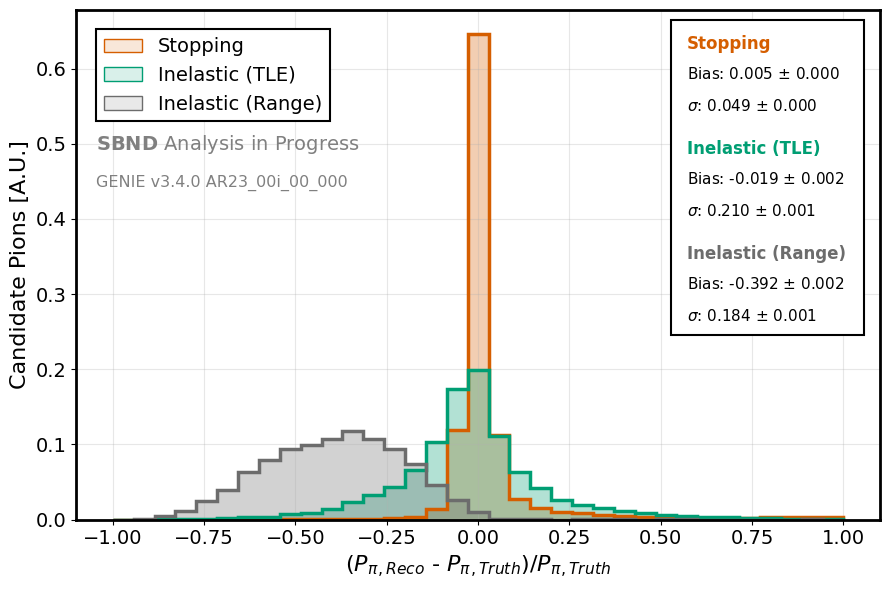

/tmp/ipykernel_11995/518554532.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  truth      = df_plot[config.truth_column].values
/tmp/ipykernel_11995/518554532.py:27: PerformanceWarning: indexing past lexsort depth may impact performance.
  reco_tle   = df_plot[config.data_column].values


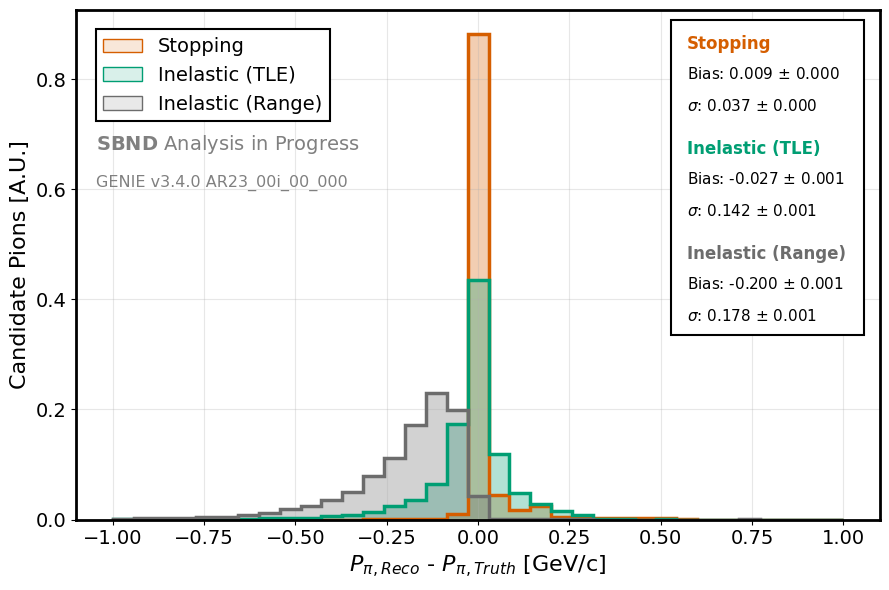

In [16]:
possibilities = [True, False]

for possibility in possibilities:
    
        fig_bias_1d = plot_1d_res_pion(
            mc_df=mc_bnb_evt_df,
            config=pion_momentum_config,
            title=pion_momentum_config.title,
            weight_column=('slc', 'wgt', '', '', '', ''),
            use_percent_bias=possibility,
            extra_mask=mask_dict[pion_momentum_config.extra_mask](mc_bnb_evt_df) & mask_dict[pion_momentum_config.category_mask](mc_bnb_evt_df),
            data_tot_pot=data_tot_pot
        )
        
        target_dir = os.path.join(parent_path , "pion_p_with_range")
        os.makedirs(target_dir, exist_ok=True)
        
        save_name_1d = f"res_1d.pdf"
        if possibility == True:
            save_name_1d = f"res_1d_percent_bias.pdf"
            
        save_path_1d = os.path.join(target_dir, save_name_1d)
        fig_bias_1d.savefig(save_path_1d, format='pdf', bbox_inches='tight') 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

def plot_1d_res_pion(
    mc_df,
    config,
    title=None,
    weight_column=None,
    use_percent_bias=False,
    extra_mask=None,
    data_tot_pot=None
):
    # --- 1. Pre-processing ---
    slice_levels = ['__ntuple', 'entry', 'rec.slc..index']
    if getattr(config, "first_per_slice", False):
        mc_df = mc_df.groupby(level=slice_levels, sort=False).first()

    if extra_mask is None:
        extra_mask = np.ones(len(mc_df), dtype=bool)

    df_plot = mc_df.loc[extra_mask].copy()

    # Handle weights
    if weight_column is not None and weight_column in df_plot.columns:
        df_plot['plot_w'] = df_plot[weight_column].values
    else:
        df_plot['plot_w'] = np.ones(len(df_plot))

    truth      = df_plot[config.truth_column].values
    reco_tle   = df_plot[config.data_column].values
    range_col  = ('slc', 'measure_var', 'range_p_pi', '', '', '')
    reco_range = df_plot[range_col].values if range_col in df_plot.columns else None

    def residual(reco, truth):
        return (reco - truth) / truth if use_percent_bias else (reco - truth)

    x_tle   = residual(reco_tle,   truth)
    x_range = residual(reco_range, truth) if reco_range is not None else None

    range_filter = (x_tle > -1.5) & (x_tle < 1.5)
    df_plot = df_plot.loc[range_filter].copy()
    df_plot['x_tle'] = x_tle[range_filter]
    if x_range is not None:
        df_plot['x_range'] = x_range[range_filter]

    pion_type      = df_plot[config.plot_column]
    stopping_mask  = pion_type == 'stopping pion'
    inelastic_mask = pion_type == 'inelastic pion'

    bins = np.linspace(-1, 1, 36)

    COL_STOP       = "#1f77b4"
    COL_STOP_RANGE = "#ff7f0e"  # <--- Added Orange for Stopping (Range)
    COL_INEL       = "#d62728"
    COL_RANGE      = "#2ca02c"

    # --- 2. Area-normalize weights per histogram ---
    w = df_plot['plot_w'].values

    def norm_weights(vals, wgts):
        valid    = ~np.isnan(vals)
        in_range = valid & (vals >= bins[0]) & (vals <= bins[-1])
        total    = wgts[in_range].sum()
        return wgts / total if total > 0 else wgts

    w_stop_tle   = norm_weights(df_plot.loc[stopping_mask,  'x_tle'].values, w[stopping_mask.values])
    w_inel_tle   = norm_weights(df_plot.loc[inelastic_mask, 'x_tle'].values, w[inelastic_mask.values])
    w_stop_range = None
    w_inel_range = None
    
    if 'x_range' in df_plot.columns:
        w_stop_range = norm_weights(df_plot.loc[stopping_mask,  'x_range'].values, w[stopping_mask.values])
        w_inel_range = norm_weights(df_plot.loc[inelastic_mask, 'x_range'].values, w[inelastic_mask.values])

    # --- 3. Plot histograms ---
    fig, ax = plt.subplots(figsize=(9, 6))

    def plot_hist(ax, vals, weights, color, label):
        valid = ~np.isnan(vals)
        ax.hist(vals[valid], bins=bins, weights=weights[valid],
                histtype='stepfilled', color=color, linewidth=2.5, alpha=0.3)
        ax.hist(vals[valid], bins=bins, weights=weights[valid],
                histtype='step', color=color, linewidth=2.5, label=label)

    plot_hist(ax, df_plot.loc[stopping_mask,  'x_tle'].values,   w_stop_tle,
              color=COL_STOP,  label='Stopping (TLE)')
    
    if w_stop_range is not None:
        plot_hist(ax, df_plot.loc[stopping_mask, 'x_range'].values, w_stop_range,
                  color=COL_STOP_RANGE, label='Stopping (Range)')
                  
    plot_hist(ax, df_plot.loc[inelastic_mask, 'x_tle'].values,   w_inel_tle,
              color=COL_INEL,  label='Inelastic (TLE)')
              
    if w_inel_range is not None:
        plot_hist(ax, df_plot.loc[inelastic_mask, 'x_range'].values, w_inel_range,
                  color=COL_RANGE, label='Inelastic (Range)')

    # --- 4. Stats (computed on original weights, not normalized) ---
    def get_stats(vals, wgts):
        valid = ~np.isnan(vals)
        vals, wgts = vals[valid], wgts[valid]
        if len(vals) == 0:
            return 0, 0, 0, 0, 0
        m     = np.average(vals, weights=wgts)
        s     = np.sqrt(np.average((vals - m)**2, weights=wgts))
        m_err = s / np.sqrt(len(vals))
        s_err = s / np.sqrt(2 * len(vals))
        return m, m_err, s, s_err, len(vals)

    stop_vals = df_plot.loc[stopping_mask, 'x_tle'].values
    stop_wgts = w[stopping_mask.values]
    stop_core = (stop_vals >= -0.25) & (stop_vals <= 0.25)

    stats = {
        'Stopping (TLE)':  (get_stats(stop_vals[stop_core], stop_wgts[stop_core]), COL_STOP),
    }
    
    if 'x_range' in df_plot.columns:
        # 1. Grab the raw range values for stopping pions
        stop_range_vals = df_plot.loc[stopping_mask, 'x_range'].values
        stop_range_wgts = w[stopping_mask.values]
        
        # 2. Define the core mask based on these range values
        stop_range_core = (stop_range_vals >= -0.25) & (stop_range_vals <= 0.25)
        
        # 3. Pass both filtered values AND filtered weights to get_stats
        stats['Stopping (Range)'] = (
            get_stats(stop_range_vals[stop_range_core], stop_range_wgts[stop_range_core]),
            COL_STOP_RANGE
        )
        
    stats['Inelastic (TLE)'] = (get_stats(df_plot.loc[inelastic_mask, 'x_tle'].values,   w[inelastic_mask.values]), COL_INEL)
    
    if 'x_range' in df_plot.columns:
        stats['Inelastic (Range)'] = (
            get_stats(df_plot.loc[inelastic_mask, 'x_range'].values, w[inelastic_mask.values]),
            COL_RANGE
        )

    # --- 5. Stats box ---
    line_h    = 0.062
    gap       = 0.02
    n_cats    = len(stats)
    total_h   = n_cats * 3 * line_h + (n_cats - 1) * gap
    box_left  = 0.75
    box_right = 0.97
    box_y     = 0.97

    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch(
        (box_left, box_y - total_h), box_right - box_left, total_h,
        boxstyle="square,pad=0.01",
        transform=ax.transAxes,
        facecolor='white', edgecolor='black',
        linewidth=1.5, zorder=4, clip_on=False
    )
    ax.add_patch(box)

    text_x   = box_left + 0.01
    y_cursor = box_y - line_h * 0.3

    for label, ((m, me, s, se, n), color) in stats.items():
        ax.text(text_x, y_cursor, label,
                transform=ax.transAxes, fontsize=12,
                color=color, fontweight='bold',
                verticalalignment='top', horizontalalignment='left',
                zorder=5)
        y_cursor -= line_h
        for line in [f"Bias: {m:.3f} $\\pm$ {me:.3f}",
                     f"$\\sigma$: {s:.3f} $\\pm$ {se:.3f}"]:
            ax.text(text_x, y_cursor, line,
                    transform=ax.transAxes, fontsize=11,
                    color='black',
                    verticalalignment='top', horizontalalignment='left',
                    zorder=5)
            y_cursor -= line_h
        y_cursor -= gap

    # --- 6. Legend ---
    stop_hand  = Patch(facecolor=to_rgba(COL_STOP,  0.15), edgecolor=COL_STOP,  label='Stopping (TLE)')
    legend_handles = [stop_hand]
    
    if 'x_range' in df_plot.columns:
        stop_range_hand = Patch(facecolor=to_rgba(COL_STOP_RANGE, 0.15), edgecolor=COL_STOP_RANGE, label='Stopping (Range)')
        legend_handles.append(stop_range_hand)
        
    inel_hand  = Patch(facecolor=to_rgba(COL_INEL,  0.15), edgecolor=COL_INEL,  label='Inelastic (TLE)')
    legend_handles.append(inel_hand)
    
    if 'x_range' in df_plot.columns:
        range_hand = Patch(facecolor=to_rgba(COL_RANGE, 0.15), edgecolor=COL_RANGE, label='Inelastic (Range)')
        legend_handles.append(range_hand)

    leg = ax.legend(handles=legend_handles, loc='upper left',
                    fontsize=14, framealpha=1.0, edgecolor='black',
                    fancybox=False, borderaxespad=1)
    leg.get_frame().set_linewidth(1.5)

    # --- 7. Labels & Style ---
    xlabel = config.title + r'$_{,Reco}$ - ' + config.title + r'$_{,Truth}$ ' + config.unit
    if use_percent_bias:
        xlabel = ('(' + config.title + r'$_{,Reco}$ - ' + config.title +
                  r'$_{,Truth}$)/' + config.title + r'$_{,Truth}$')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Candidate Pions [A.U.]')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # --- 8. Watermark Texts anchored below legend ---
    text_configs = [
        ("AnalysisInProgress", add_approval_text,      14,   None        ),
        (None,                 add_genie_version_text, 11.5, None        )
    ]

    def place_texts_at_save(renderer):
        leg_bbox = leg.get_window_extent(renderer)
        inv_axes = ax.transAxes.inverted()

        # Anchor to bottom-left corner of legend
        leg_x_ax, leg_y_ax = inv_axes.transform((leg_bbox.x0, leg_bbox.y0))

        axes_height_px = ax.get_window_extent(renderer).height
        dpi            = fig.get_dpi()
        pt_to_ax       = (dpi / 72.0) / axes_height_px
        line_height_ax = 13 * 1.6 * pt_to_ax

        # Remove previously placed texts to avoid duplicates on redraw
        for txt in getattr(place_texts_at_save, '_added_texts', []):
            try:
                txt.remove()
            except Exception:
                pass
        place_texts_at_save._added_texts = []

        for i, (approval, fn, fs, pot) in enumerate(text_configs):
            kwargs = dict(
                textloc_x=leg_x_ax,
                textloc_y=leg_y_ax - (i + 1) * line_height_ax * 1.2,
                textloc_ha='left',
                ax=ax,
                fontsize=fs,
            )
            if approval is not None:
                kwargs['approval'] = approval
            if pot is not None:
                kwargs['data_pot'] = pot
            txt = fn(**kwargs)
            if txt is not None:
                place_texts_at_save._added_texts.append(txt)

    fig.canvas.mpl_connect('draw_event', lambda event: place_texts_at_save(event.renderer))

    plt.show()
    return fig